## **IMPORTS**

In [49]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [50]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

In [51]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

#print(f'--> outputs logs in: {OUTPUT_PATH}')

## **UTILS**

### **CONFIG**

In [52]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [53]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [54]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [55]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [56]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [57]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [ ]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

#print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [59]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [60]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [61]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [62]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [63]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [64]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:30:44.762 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:30:44.804 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:30:44.928 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:30:44.989 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:30:45.092 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:30:45.178 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:30:45.266 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:30:45.372 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:30:45.412 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:30:45.482 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:30:45.518 | IN

##### *Metrics*

In [65]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.97 kWh
  Station 1: 0.00 kWh
  Station 2: 12.49 kWh
  Station 3: 15.72 kWh
  Station 4: 0.00 kWh
  Station 5: 2.22 kWh
  Station 6: 4.27 kWh
  Station 7: 3.58 kWh
  Station 8: 0.00 kWh
  Station 9: 75.03 kWh
  Station 10: 16.39 kWh
  Station 11: 21.90 kWh
  Station 12: 5.34 kWh
  Station 13: 0.00 kWh
  Station 14: 15.96 kWh
  Station 15: 2.94 kWh
  Station 16: 7.48 kWh
  Station 17: 17.17 kWh
  Station 18: 6.47 kWh
  Station 19: 15.50 kWh
  Station 20: 5.21 kWh
  Station 21: 1.33 kWh
  Station 22: 4.40 kWh
  Station 23: 4.83 kWh
  Station 24: 7.71 kWh
  Station 25: 2.07 kWh
  Station 26: 12.22 kWh
  Station 27: 16.83 kWh
  Station 28: 70.87 kWh
  Station 29: 26.64 kWh
  Station 30: 4.17 kWh
  Station 31: 0.00 kWh
  Station 32: 4.27 kWh
  Station 33: 89.58 kWh
  Station 34: 3.94 kWh
  Station 35: 78.96 kWh
  Station 36: 0.00 kWh
  Station 37: 0.00 kWh
  Station 38: 0.00 kWh
  Station 39: 3.67 kWh

--- User Req

In [66]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

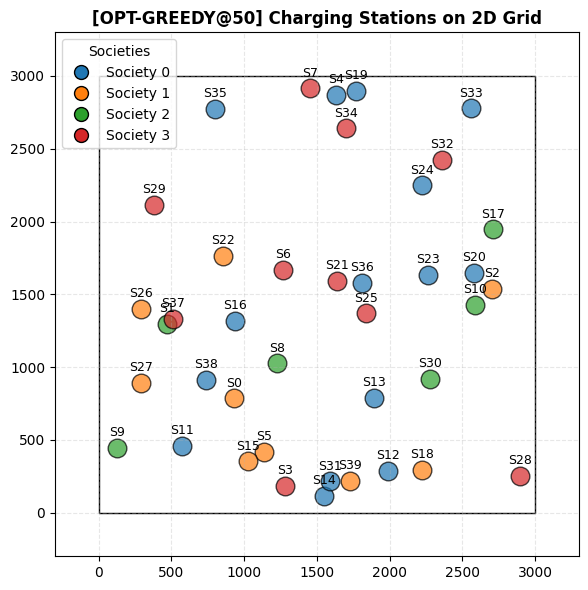

In [67]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

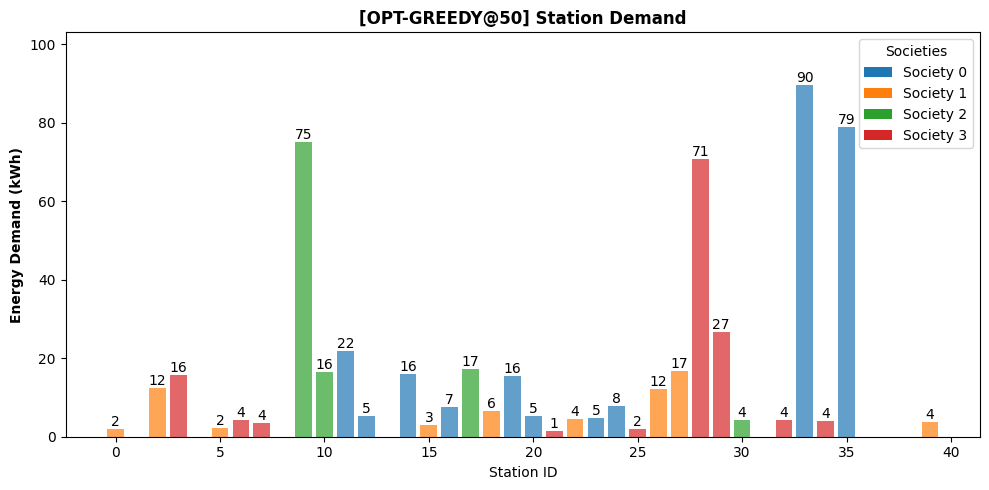

In [68]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

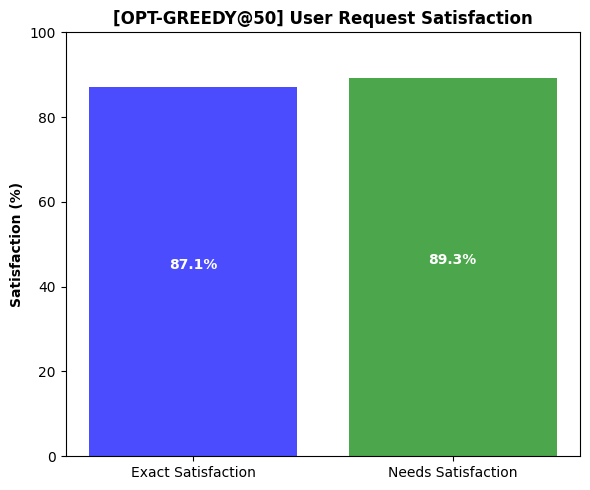

In [69]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

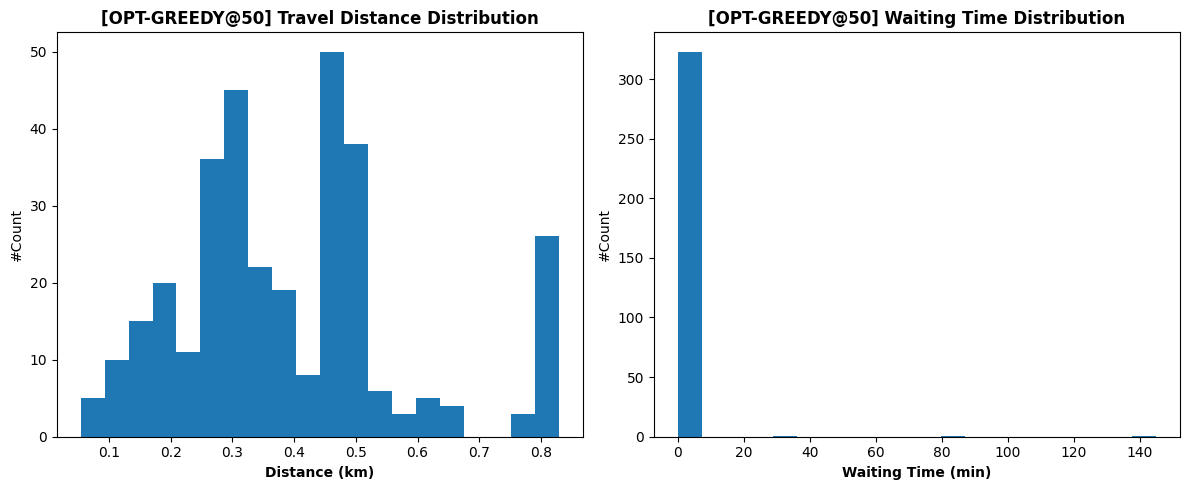

In [70]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

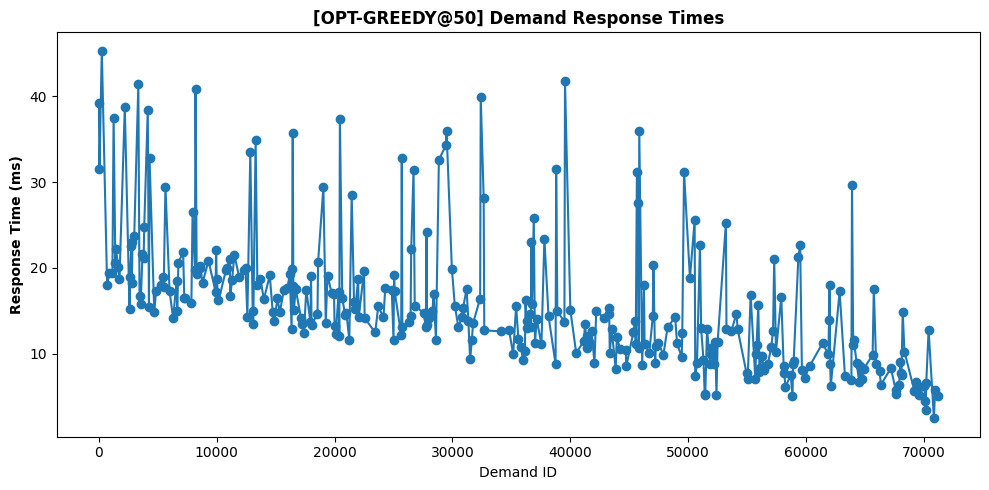

In [71]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

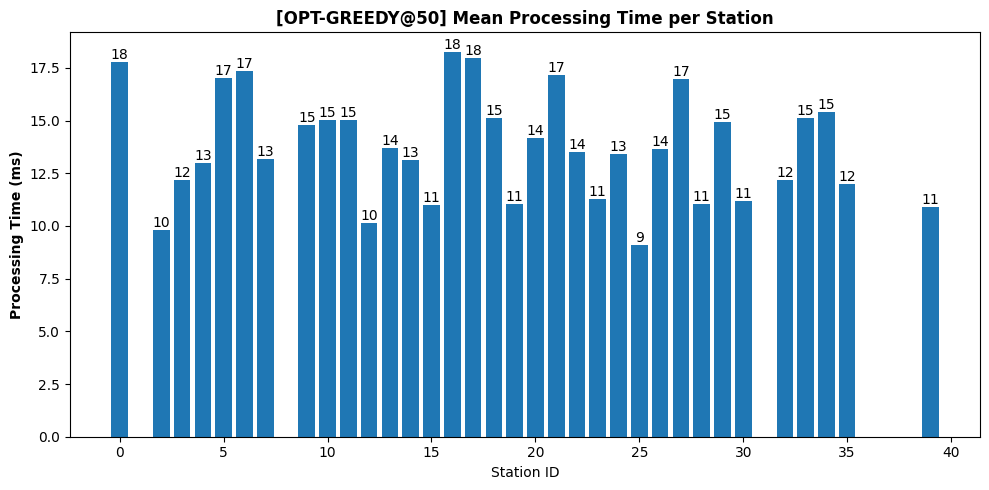

In [72]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [73]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           4  0.000000  0.000000  0.000000  0.000000  0.000000   
1            0          11  0.203472  0.088194  0.018750  0.000000  0.000000   
2            0          12  0.070833  0.000000  0.000000  0.000000  0.000000   
3            0          13  0.000000  0.000000  0.000000  0.000000       NaN   
4            0          14  0.165972  0.059028  0.000000  0.000000  0.000000   
5            0          16  0.120833  0.000000  0.000000  0.000000  0.000000   
6            0          19  0.175694  0.028472  0.000000  0.000000       NaN   
7            0          20  0.086806  0.000000  0.000000  0.000000  0.000000   
8            0          23  0.066667  0.000000  0.000000  0.000000       NaN   
9            0          24  0.116667  0.000000  0.000000  0.000000  0.000000   
10           0          31  0.000000  0.000000  0.000000  0.000000  0.000000   
11           0          33  0.565972  0.

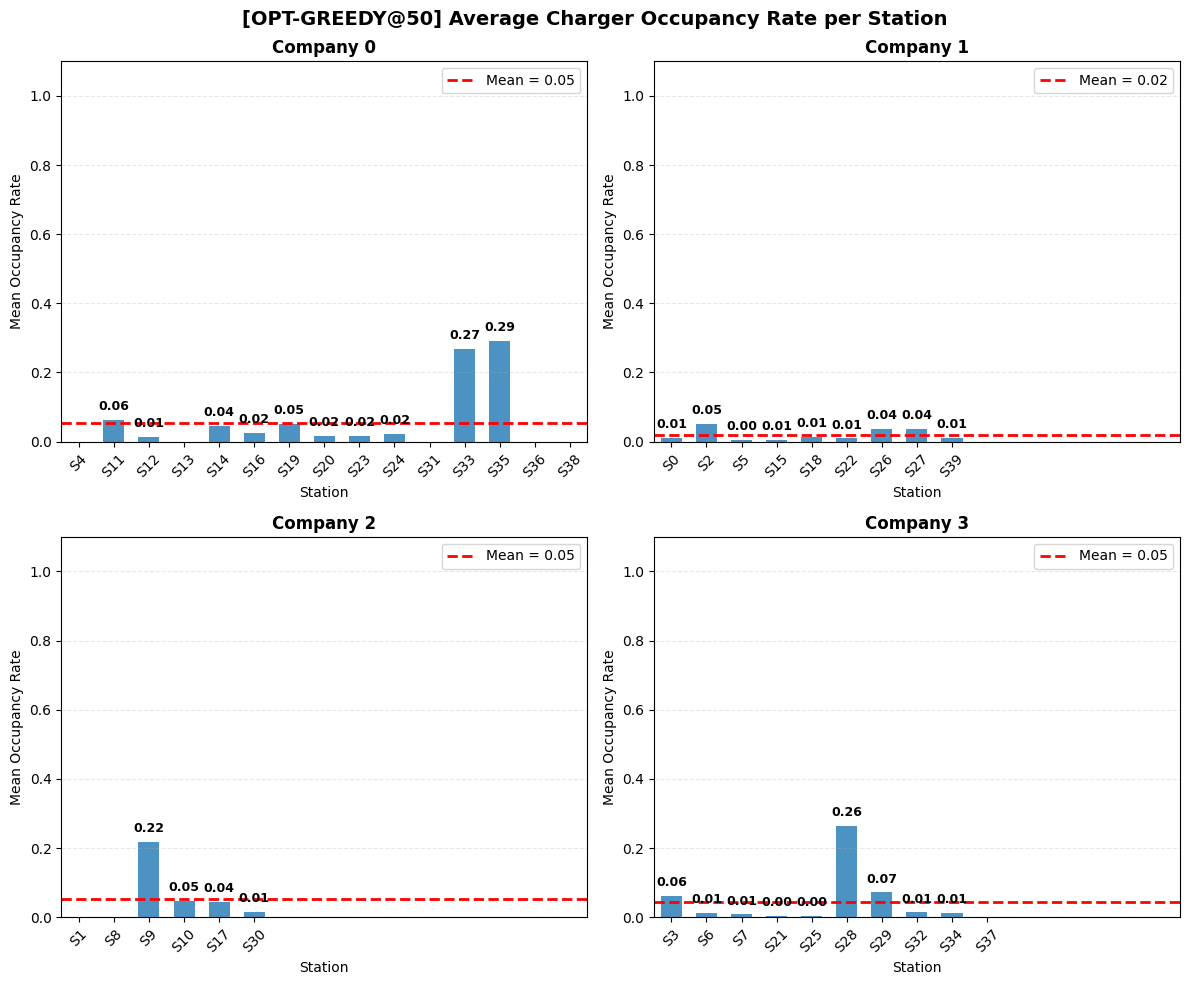

In [74]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

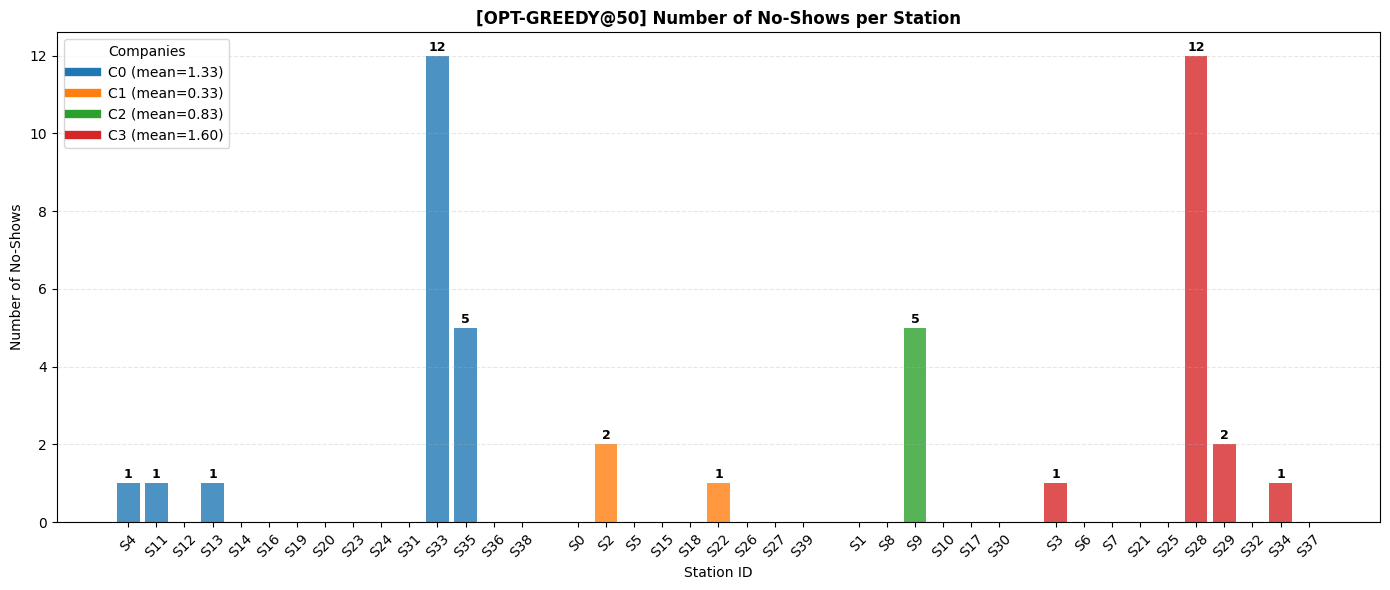

In [75]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [76]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,4,1,0,1,0,0,0.000000,1.000000,0.0,0.0
1,0,11,13,12,1,0,0,0.923077,0.076923,0.0,0.0
2,0,12,3,3,0,0,0,1.000000,0.000000,0.0,0.0
3,0,13,1,0,1,0,0,0.000000,1.000000,0.0,0.0
4,0,14,10,10,0,0,0,1.000000,0.000000,0.0,0.0
5,0,16,4,4,0,0,0,1.000000,0.000000,0.0,0.0
6,0,19,9,9,0,0,0,1.000000,0.000000,0.0,0.0
7,0,20,3,3,0,0,0,1.000000,0.000000,0.0,0.0
8,0,23,2,2,0,0,0,1.000000,0.000000,0.0,0.0
9,0,24,4,4,0,0,0,1.000000,0.000000,0.0,0.0


NUMBER OF REJECTED REQUESTS

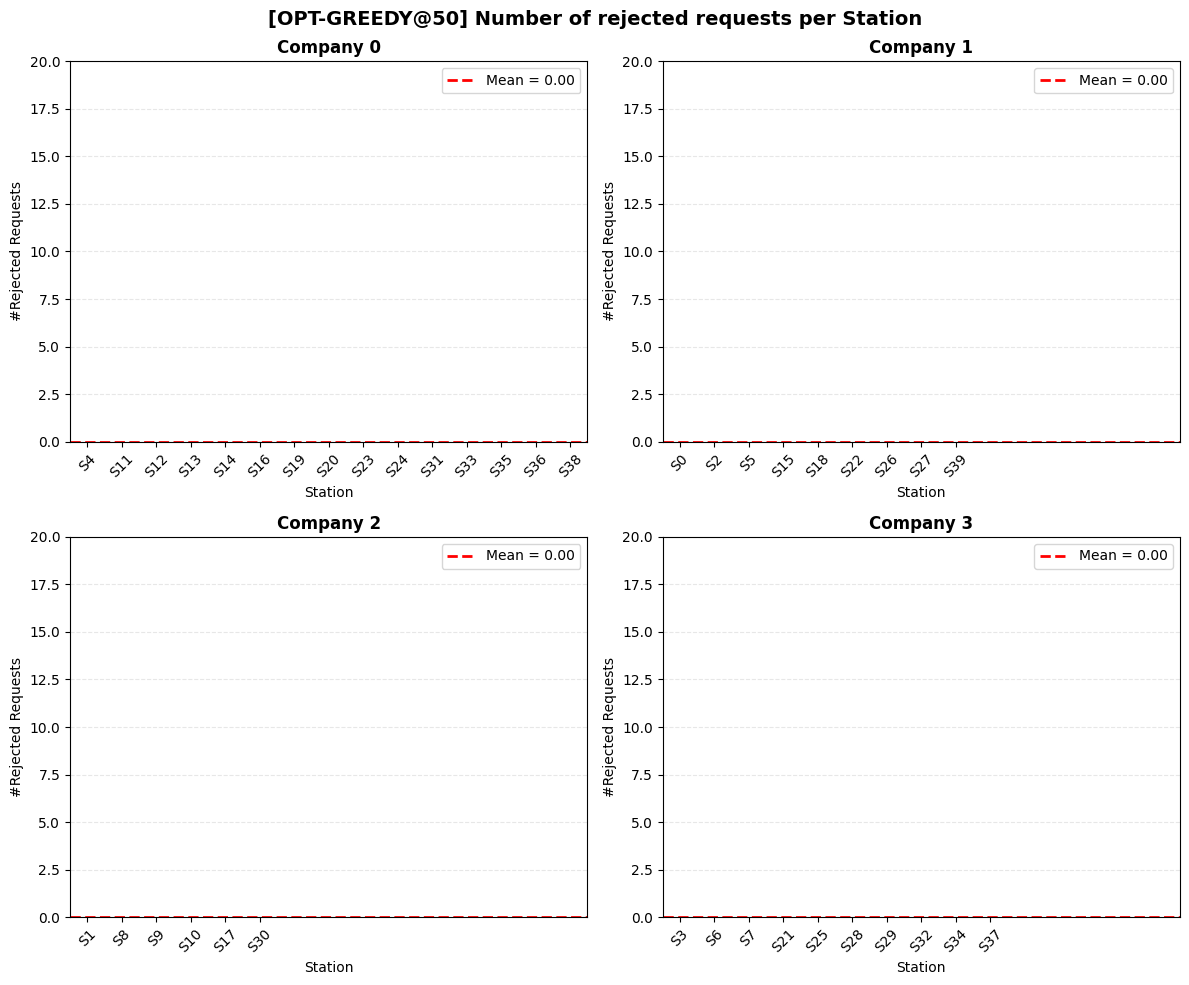

In [77]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [78]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [79]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [80]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:30:52.328 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:30:52.550 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:30:52.904 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:30:53.055 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:30:53.458 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:30:53.691 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:30:54.565 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:30:54.892 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:30:55.516 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:30:55.839 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:30:56.616 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [81]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 9.25 kWh
  Station 1: 61.59 kWh
  Station 2: 3.78 kWh
  Station 3: 79.53 kWh
  Station 4: 4.47 kWh
  Station 5: 6.06 kWh
  Station 6: 2.07 kWh
  Station 7: 0.00 kWh
  Station 8: 0.00 kWh
  Station 9: 3.72 kWh
  Station 10: 7.49 kWh
  Station 11: 2.40 kWh
  Station 12: 17.86 kWh
  Station 13: 0.00 kWh
  Station 14: 106.39 kWh
  Station 15: 0.00 kWh
  Station 16: 10.11 kWh
  Station 17: 0.00 kWh
  Station 18: 0.00 kWh
  Station 19: 18.57 kWh
  Station 20: 49.61 kWh
  Station 21: 1.60 kWh
  Station 22: 18.81 kWh
  Station 23: 13.87 kWh
  Station 24: 0.00 kWh
  Station 25: 24.15 kWh
  Station 26: 23.18 kWh
  Station 27: 18.88 kWh
  Station 28: 3.53 kWh
  Station 29: 1.67 kWh
  Station 30: 9.32 kWh
  Station 31: 1.75 kWh
  Station 32: 11.02 kWh
  Station 33: 6.52 kWh
  Station 34: 8.04 kWh
  Station 35: 0.00 kWh
  Station 36: 15.53 kWh
  Station 37: 3.84 kWh
  Station 38: 11.62 kWh
  Station 39: 3.25 kWh

--- User R

In [82]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

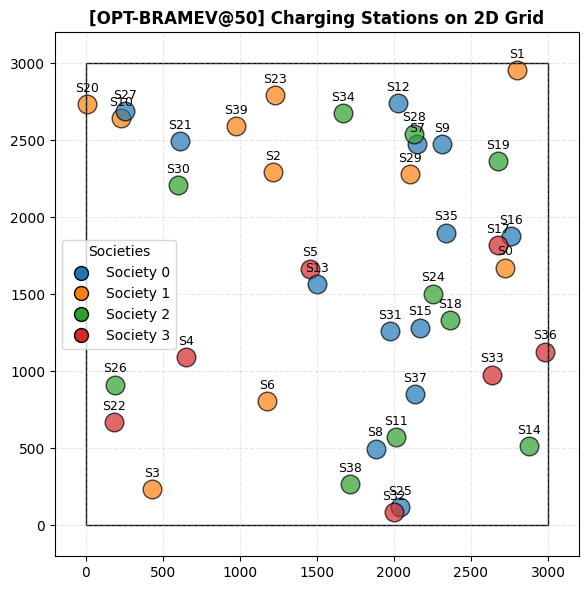

In [83]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

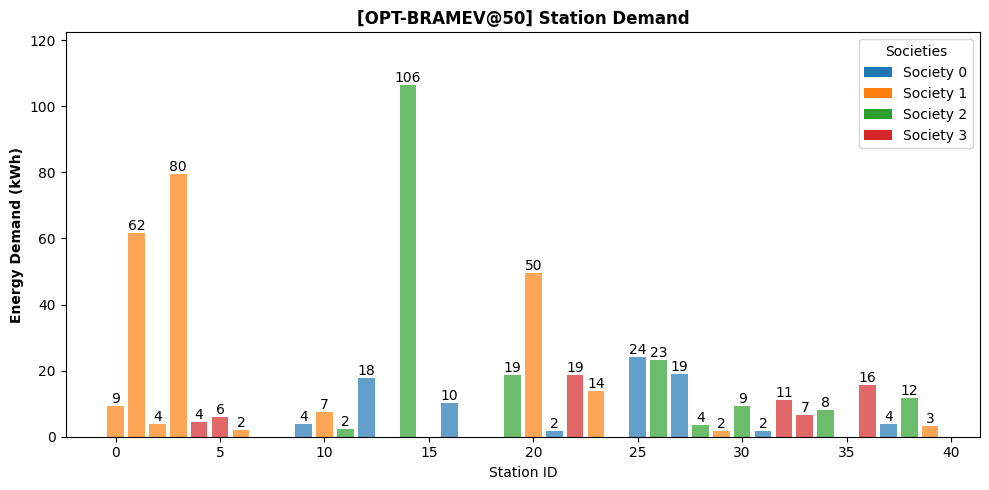

In [84]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

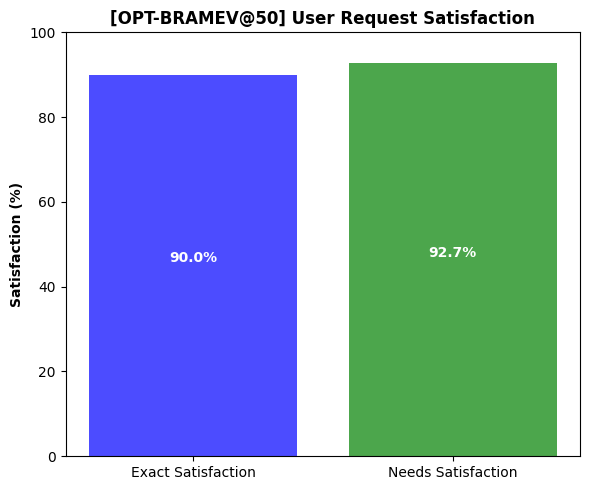

In [85]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

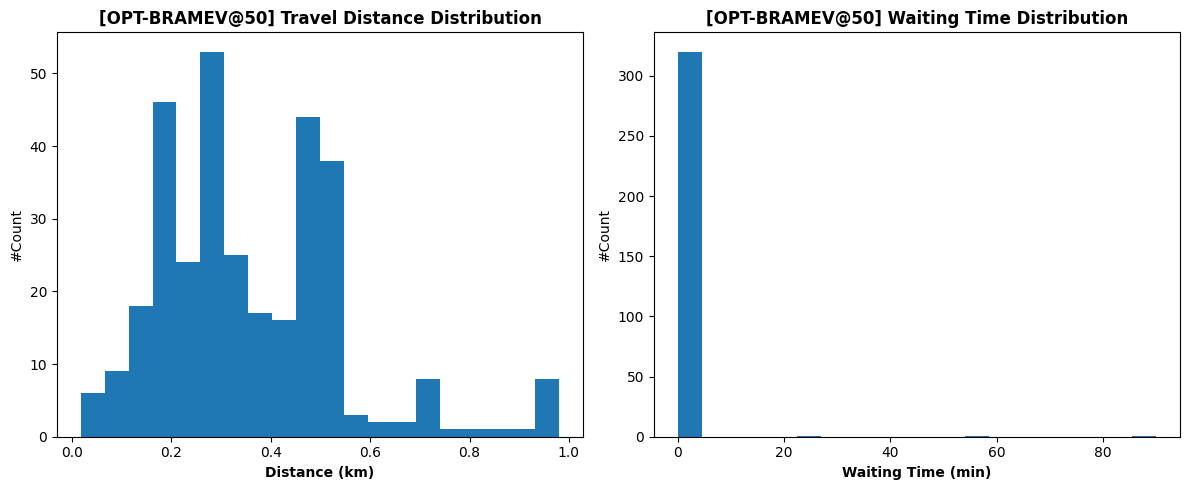

In [86]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

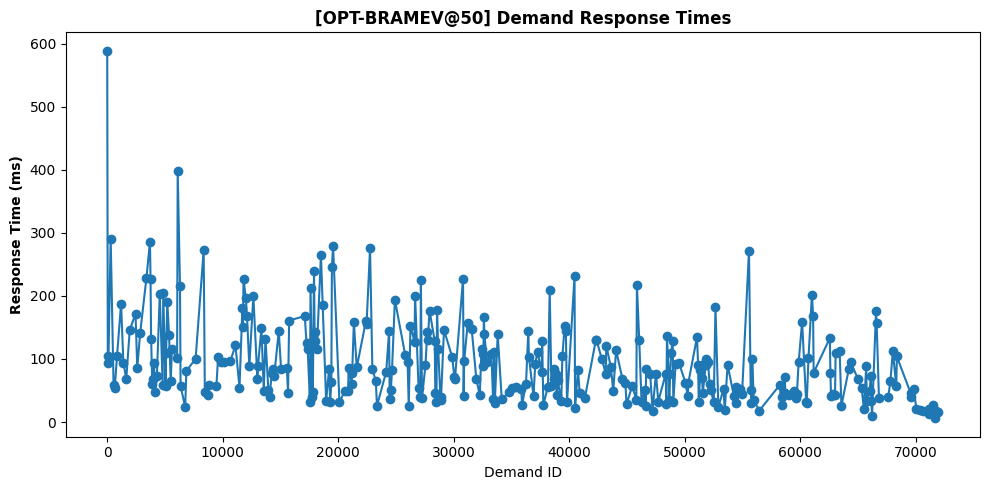

In [87]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

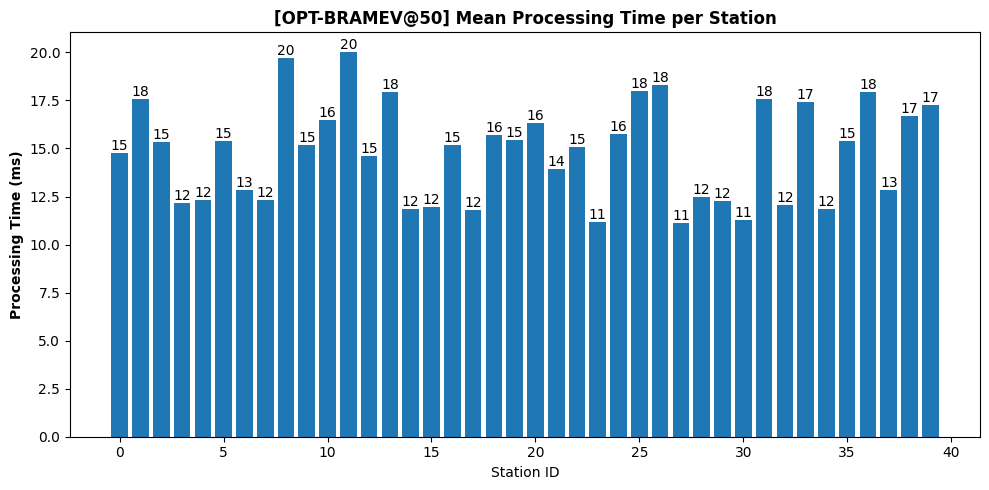

In [88]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

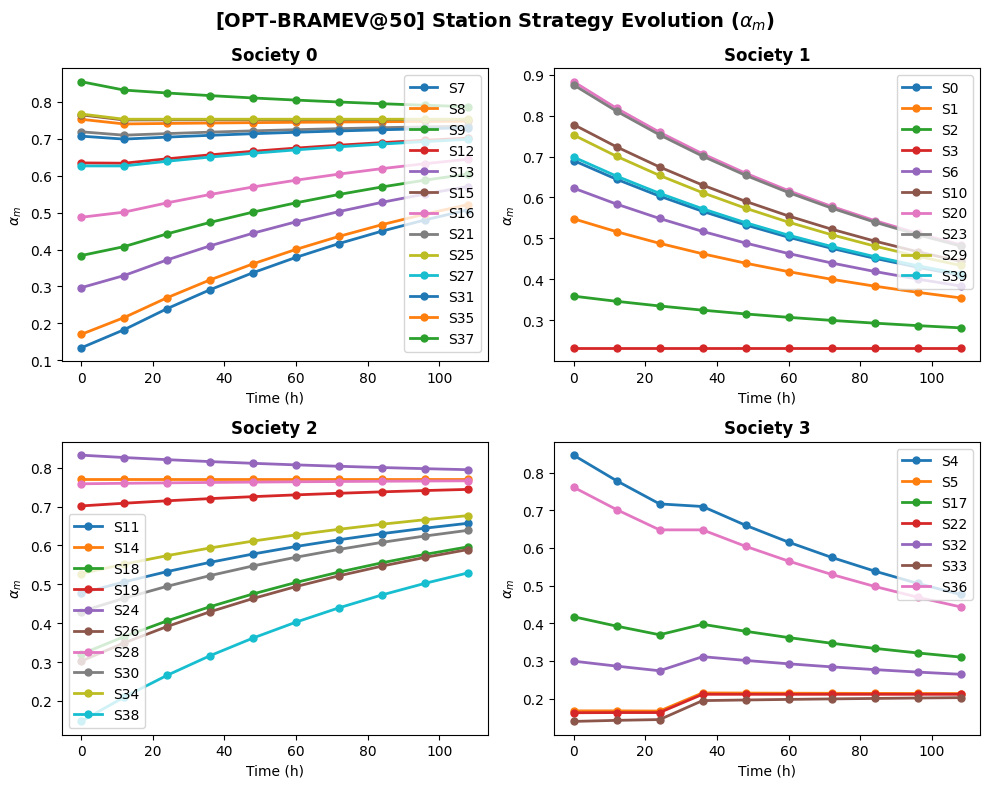

In [89]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [90]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           7  0.000000  0.000000  0.000000  0.000000       NaN   
1            0           8  0.000000  0.000000  0.000000  0.000000  0.000000   
2            0           9  0.045833  0.000000  0.000000  0.000000  0.000000   
3            0          12  0.228472  0.000000  0.000000  0.000000  0.000000   
4            0          13  0.000000  0.000000  0.000000  0.000000  0.000000   
5            0          15  0.000000  0.000000  0.000000  0.000000       NaN   
6            0          16  0.112500  0.000000  0.000000  0.000000  0.000000   
7            0          21  0.016667  0.000000  0.000000  0.000000  0.000000   
8            0          25  0.210417  0.088889  0.000000  0.000000  0.000000   
9            0          27  0.236111  0.020833  0.000000  0.000000       NaN   
10           0          31  0.020833  0.000000  0.000000  0.000000  0.000000   
11           0          35  0.000000  0.

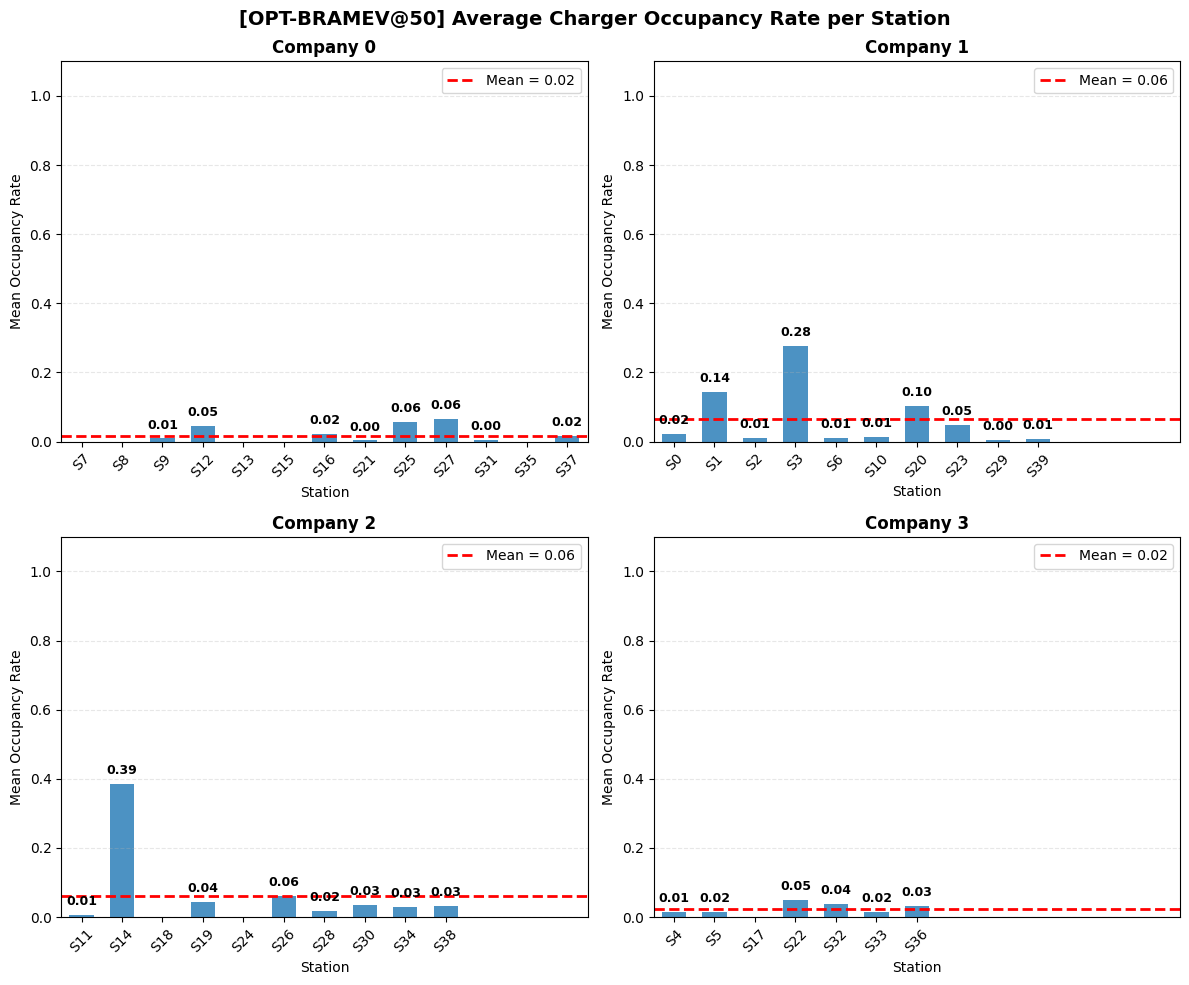

In [91]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

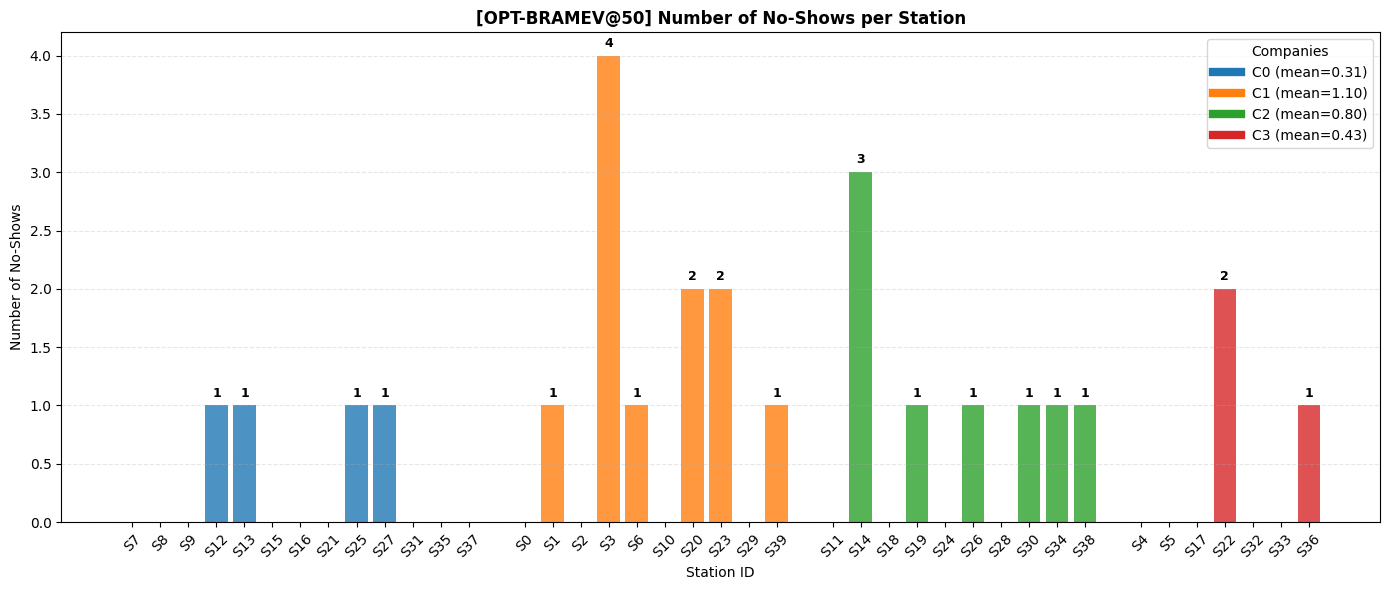

In [92]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [93]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,7,0,0,0,0,0,NaN,NaN,NaN,NaN
1,0,8,0,0,0,0,0,NaN,NaN,NaN,NaN
2,0,9,2,2,0,0,0,1.000000,0.000000,0.0,0.0
3,0,12,12,11,1,0,0,0.916667,0.083333,0.0,0.0
4,0,13,1,0,1,0,0,0.000000,1.000000,0.0,0.0
5,0,15,0,0,0,0,0,NaN,NaN,NaN,NaN
6,0,16,6,6,0,0,0,1.000000,0.000000,0.0,0.0
7,0,21,1,1,0,0,0,1.000000,0.000000,0.0,0.0
8,0,25,14,13,1,0,0,0.928571,0.071429,0.0,0.0
9,0,27,12,11,1,0,0,0.916667,0.083333,0.0,0.0


NUMBER OF REJECTED REQUESTS

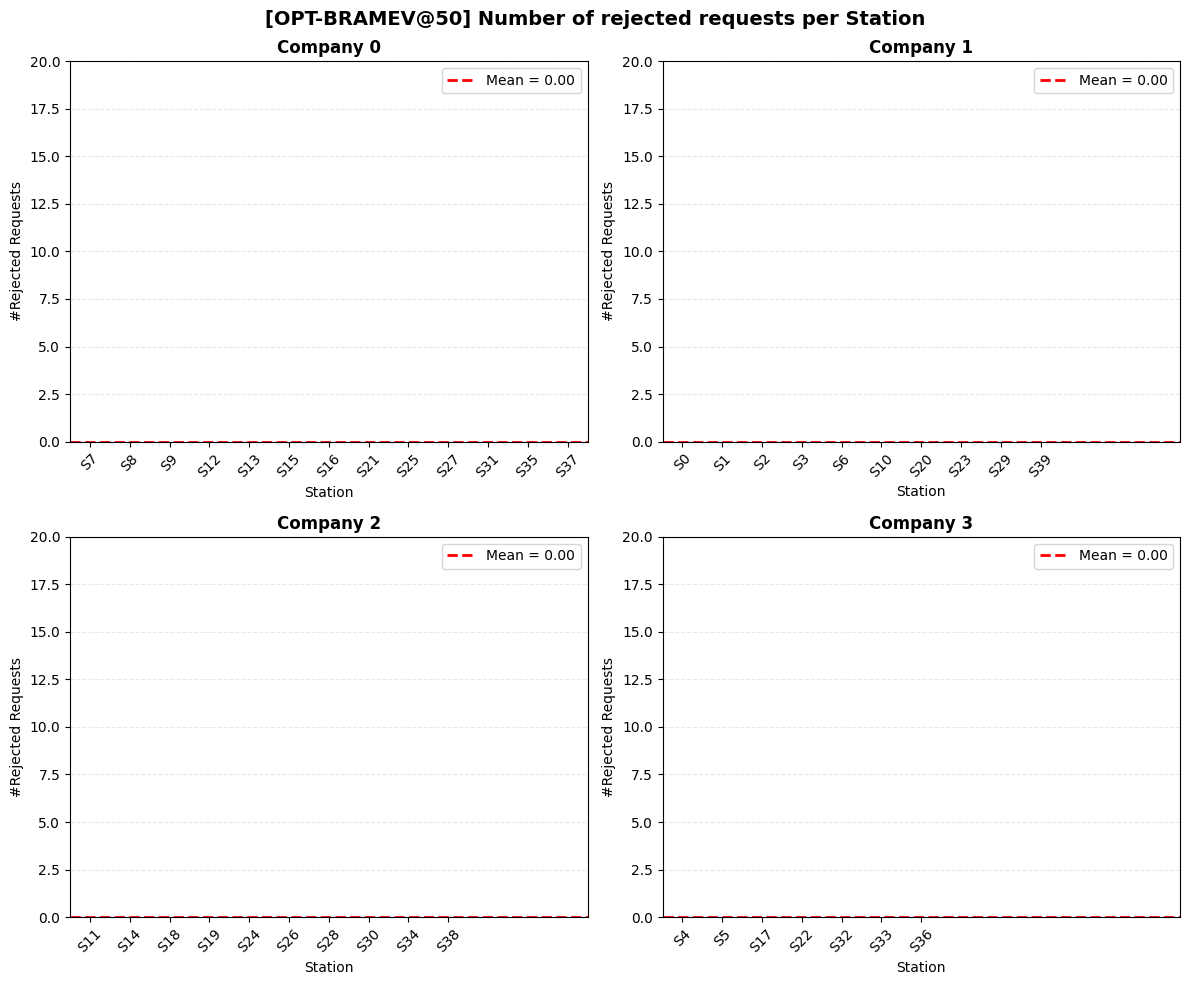

In [94]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [95]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

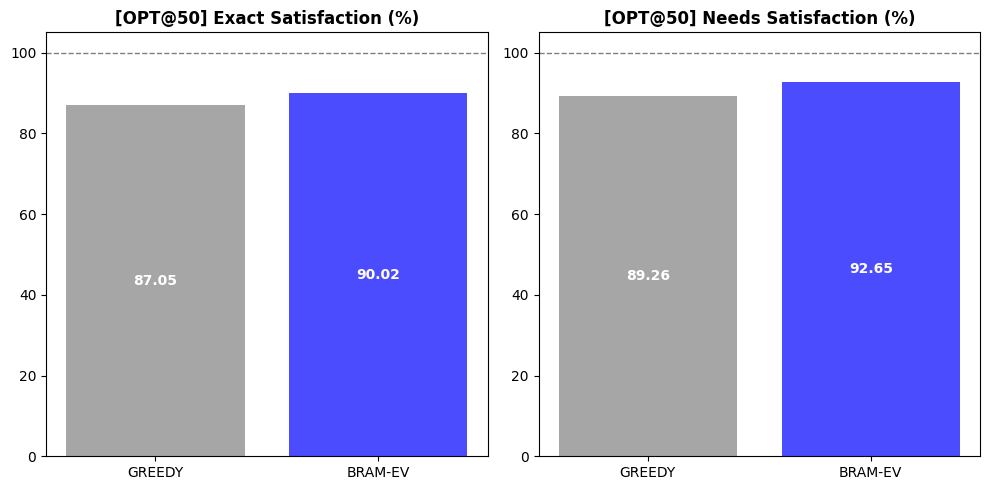

In [96]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

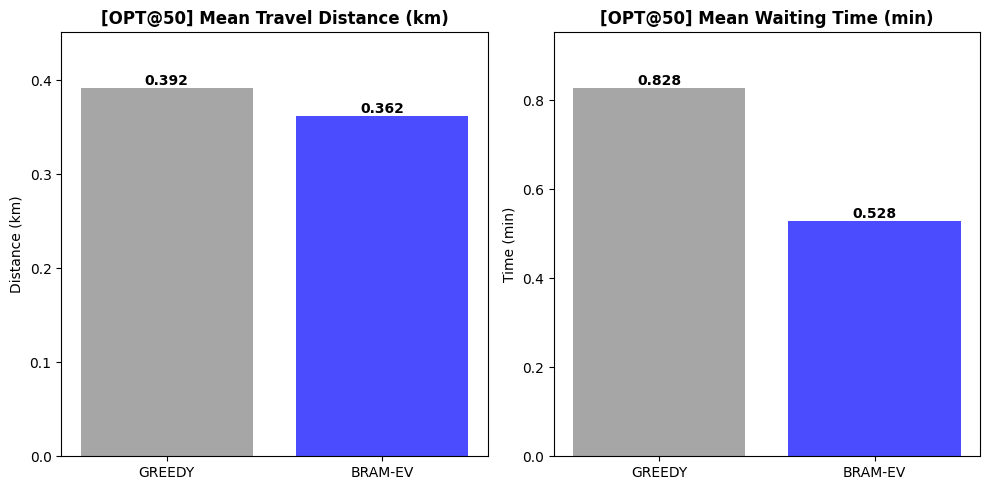

In [97]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

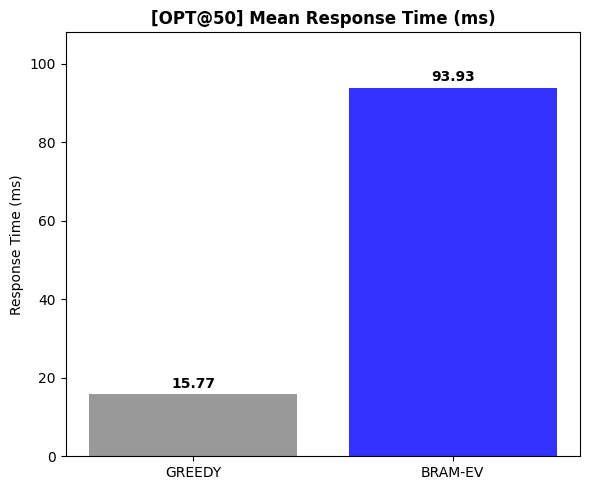

In [98]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [99]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [100]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [101]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [102]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:31:22.794 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:31:22.910 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:31:23.078 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:31:23.143 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:31:23.297 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:31:23.533 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:31:23.749 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:31:23.937 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:31:24.179 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:31:24.309 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:31:24.447 | IN

##### *Metrics*

In [103]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 138.49 kWh
  Station 1: 36.14 kWh
  Station 2: 1.80 kWh
  Station 3: 39.58 kWh
  Station 4: 6.19 kWh
  Station 5: 42.26 kWh
  Station 6: 10.42 kWh
  Station 7: 8.07 kWh
  Station 8: 20.63 kWh
  Station 9: 142.12 kWh
  Station 10: 8.22 kWh
  Station 11: 19.68 kWh
  Station 12: 8.10 kWh
  Station 13: 36.79 kWh
  Station 14: 1.77 kWh
  Station 15: 138.80 kWh
  Station 16: 29.79 kWh
  Station 17: 53.81 kWh
  Station 18: 7.07 kWh
  Station 19: 0.00 kWh
  Station 20: 24.71 kWh
  Station 21: 0.00 kWh
  Station 22: 132.26 kWh
  Station 23: 1.80 kWh
  Station 24: 7.53 kWh
  Station 25: 7.28 kWh
  Station 26: 2.73 kWh
  Station 27: 5.20 kWh
  Station 28: 13.46 kWh
  Station 29: 14.97 kWh
  Station 30: 4.78 kWh
  Station 31: 3.40 kWh
  Station 32: 26.77 kWh
  Station 33: 0.97 kWh
  Station 34: 20.83 kWh
  Station 35: 4.01 kWh
  Station 36: 1.45 kWh
  Station 37: 37.77 kWh
  Station 38: 5.17 kWh
  Station 39: 35.31 kWh

--

In [104]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

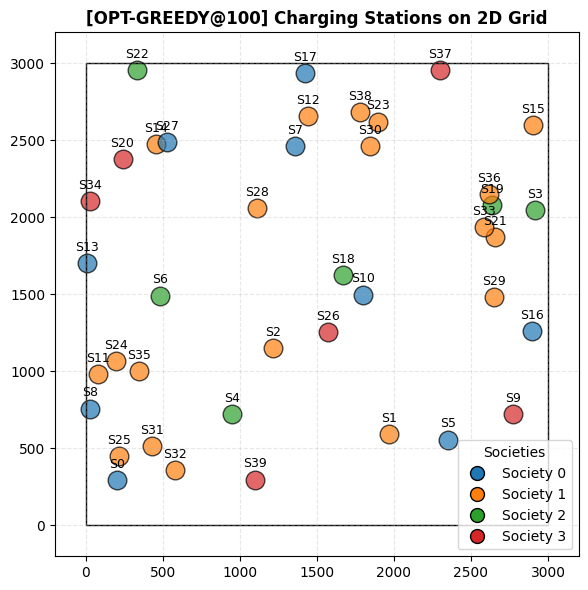

In [105]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

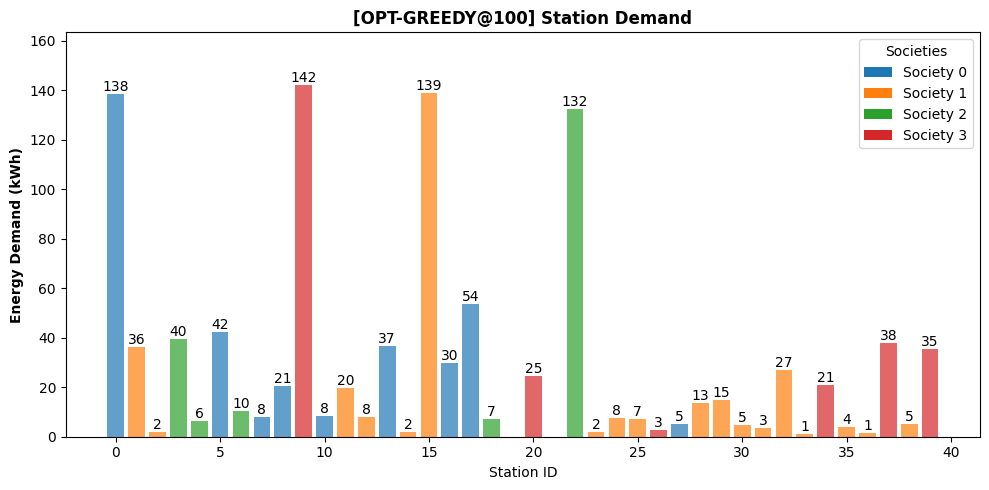

In [106]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

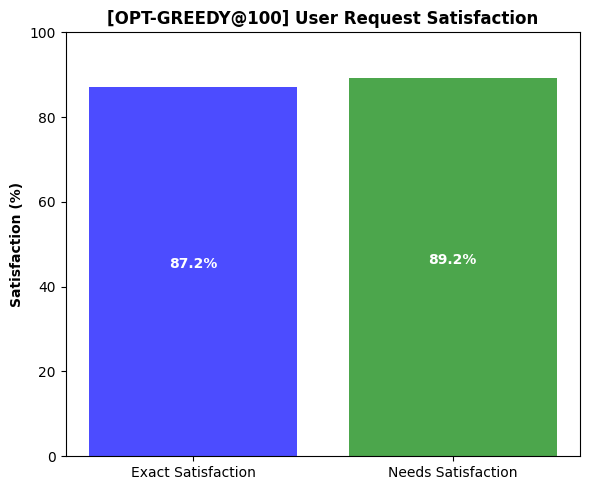

In [107]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

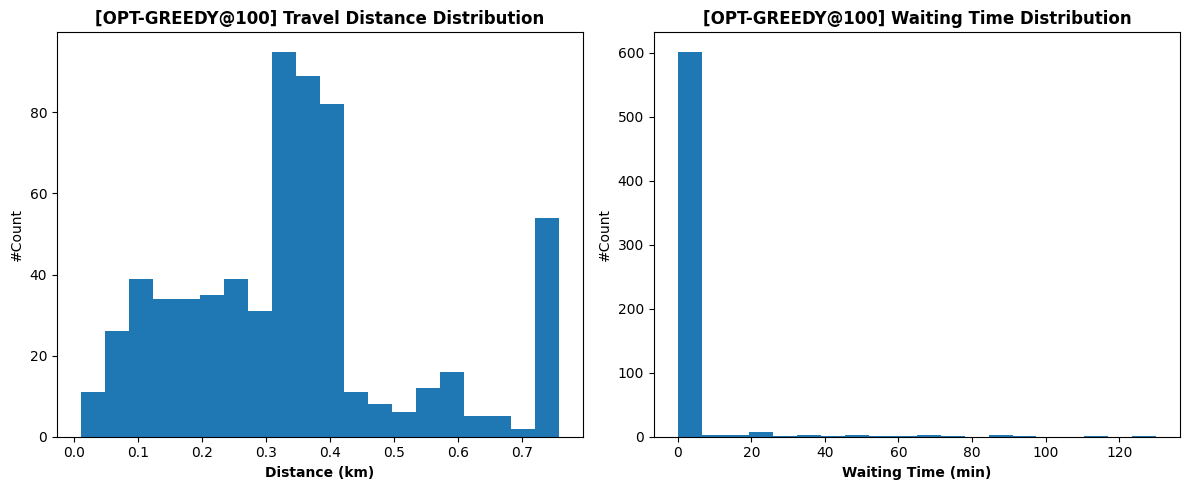

In [108]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

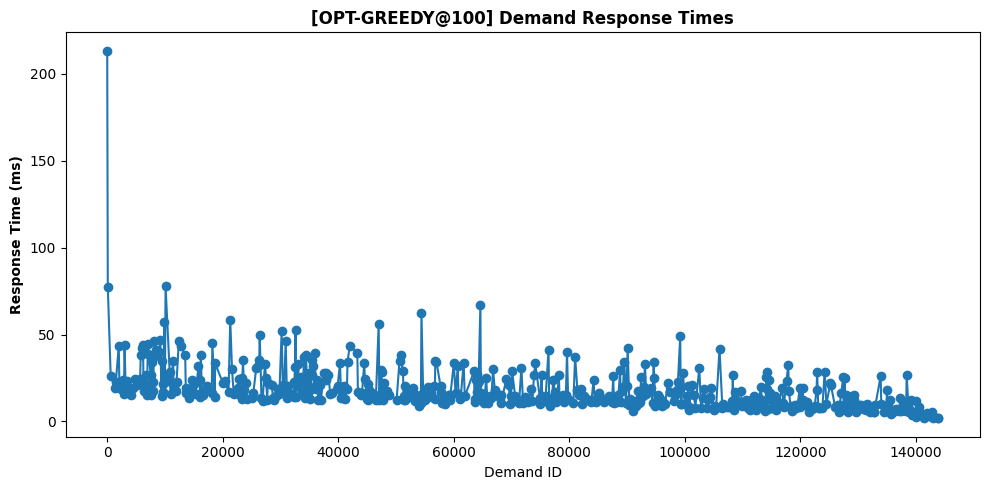

In [109]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

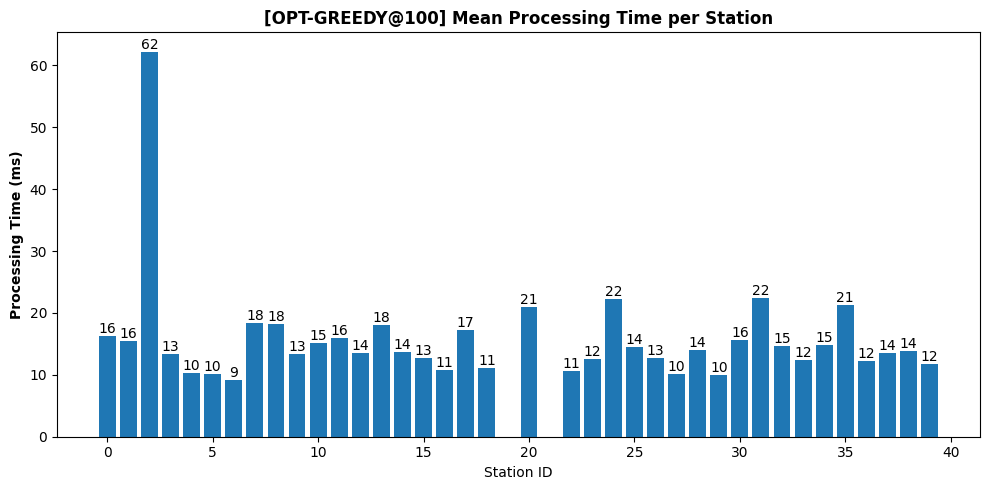

In [110]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [111]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.557639  0.537500  0.222222  0.083333  0.210417   
1            0           5  0.354861  0.200694  0.018750  0.054861       NaN   
2            0           7  0.129861  0.000000  0.000000  0.000000  0.000000   
3            0           8  0.186111  0.059028  0.000000  0.000000  0.000000   
4            0          10  0.122222  0.000000  0.000000  0.000000  0.000000   
5            0          13  0.391667  0.132639  0.000000  0.000000  0.027778   
6            0          16  0.345833  0.043056  0.034722  0.000000       NaN   
7            0          17  0.399306  0.238194  0.072917  0.000000  0.000000   
8            0          27  0.055556  0.012500  0.000000  0.000000       NaN   
9            1           1  0.365972  0.161111  0.000000  0.000000  0.031944   
10           1           2  0.037500  0.000000  0.000000  0.000000  0.000000   
11           1          11  0.253472  0.

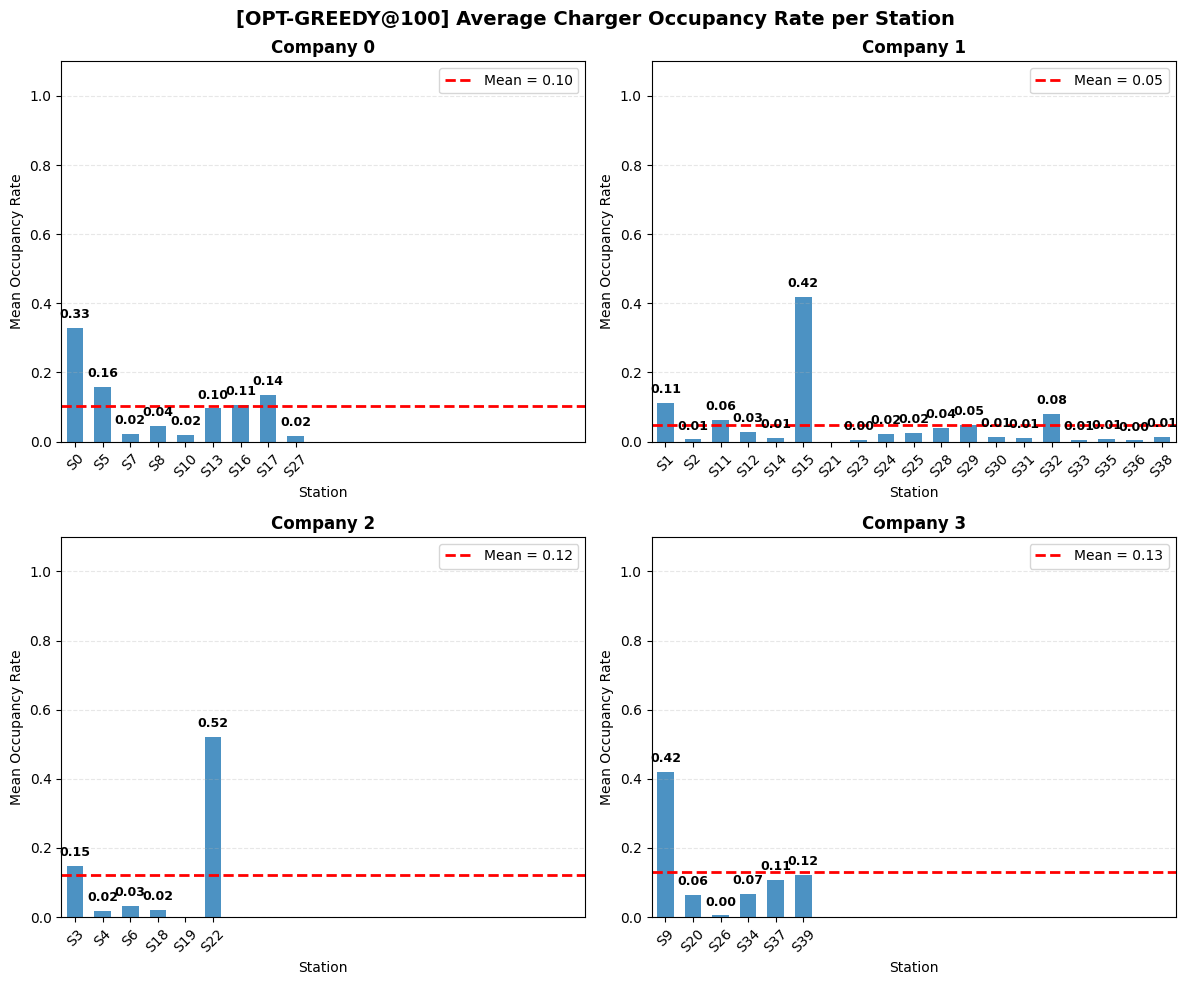

In [112]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

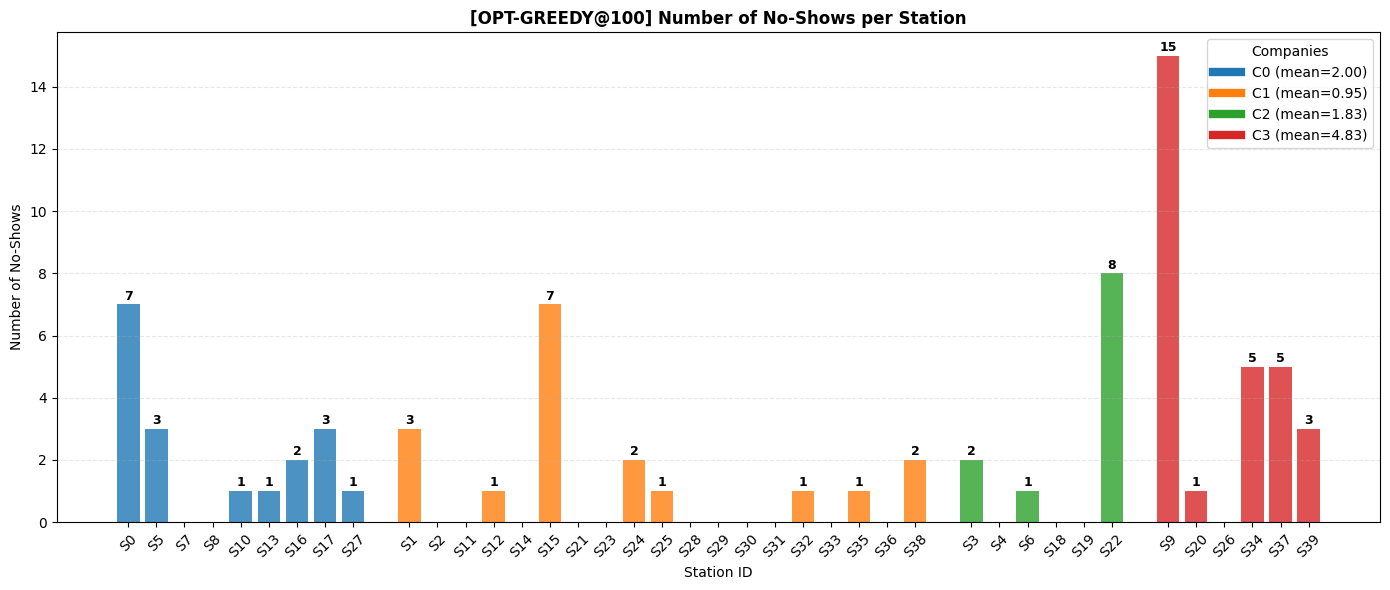

In [113]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [114]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,85,77,7,0,0,0.905882,0.082353,0.0,0.0
1,0,5,27,23,3,0,0,0.851852,0.111111,0.0,0.0
2,0,7,5,5,0,0,0,1.000000,0.000000,0.0,0.0
3,0,8,12,12,0,0,0,1.000000,0.000000,0.0,0.0
4,0,10,6,5,1,0,0,0.833333,0.166667,0.0,0.0
5,0,13,22,21,1,0,0,0.954545,0.045455,0.0,0.0
6,0,16,20,18,2,0,0,0.900000,0.100000,0.0,0.0
7,0,17,31,28,3,0,0,0.903226,0.096774,0.0,0.0
8,0,27,5,4,1,0,0,0.800000,0.200000,0.0,0.0
9,1,1,23,20,3,0,0,0.869565,0.130435,0.0,0.0


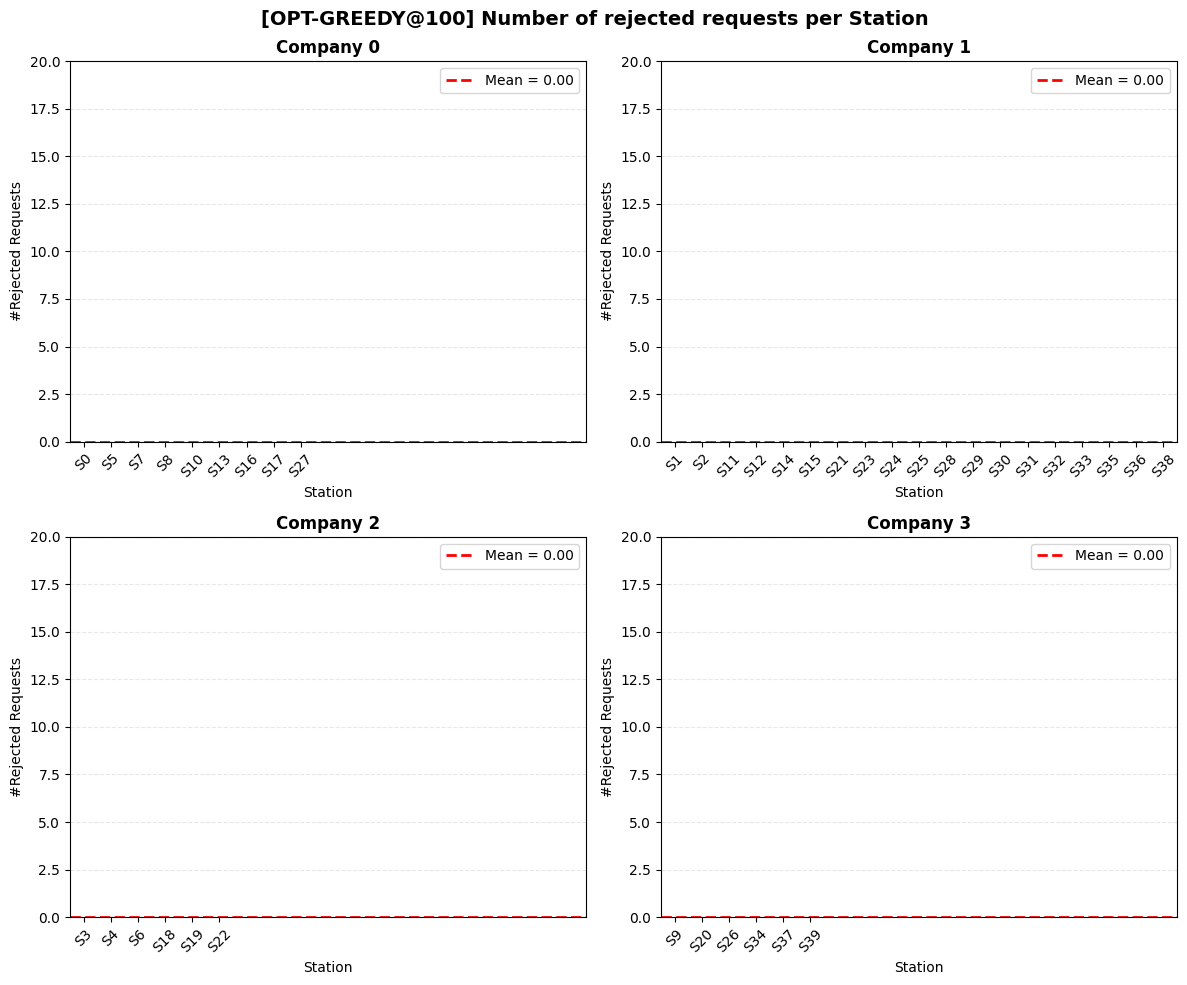

In [115]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [116]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [117]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [118]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:31:36.659 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:31:37.519 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:31:38.333 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:31:39.213 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:31:39.753 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:31:40.622 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:31:41.445 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:31:42.412 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:31:43.064 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:31:43.776 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:31:44.234 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [119]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 14.27 kWh
  Station 1: 9.20 kWh
  Station 2: 34.98 kWh
  Station 3: 121.97 kWh
  Station 4: 41.56 kWh
  Station 5: 11.08 kWh
  Station 6: 19.68 kWh
  Station 7: 0.70 kWh
  Station 8: 18.07 kWh
  Station 9: 13.63 kWh
  Station 10: 34.45 kWh
  Station 11: 5.40 kWh
  Station 12: 9.16 kWh
  Station 13: 3.77 kWh
  Station 14: 24.75 kWh
  Station 15: 135.47 kWh
  Station 16: 43.38 kWh
  Station 17: 2.72 kWh
  Station 18: 1.50 kWh
  Station 19: 14.70 kWh
  Station 20: 9.53 kWh
  Station 21: 0.00 kWh
  Station 22: 36.58 kWh
  Station 23: 11.53 kWh
  Station 24: 120.26 kWh
  Station 25: 76.27 kWh
  Station 26: 15.37 kWh
  Station 27: 1.83 kWh
  Station 28: 20.55 kWh
  Station 29: 9.41 kWh
  Station 30: 21.68 kWh
  Station 31: 12.37 kWh
  Station 32: 2.17 kWh
  Station 33: 2.12 kWh
  Station 34: 106.58 kWh
  Station 35: 27.95 kWh
  Station 36: 0.00 kWh
  Station 37: 7.27 kWh
  Station 38: 32.21 kWh
  Station 39: 23.46 kW

In [120]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

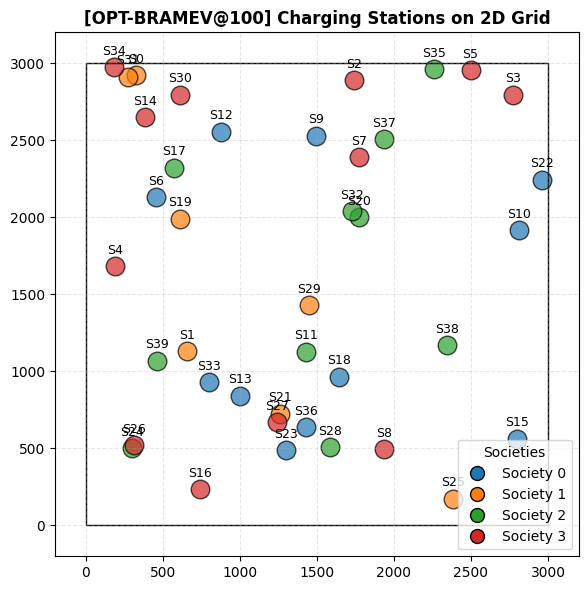

In [121]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

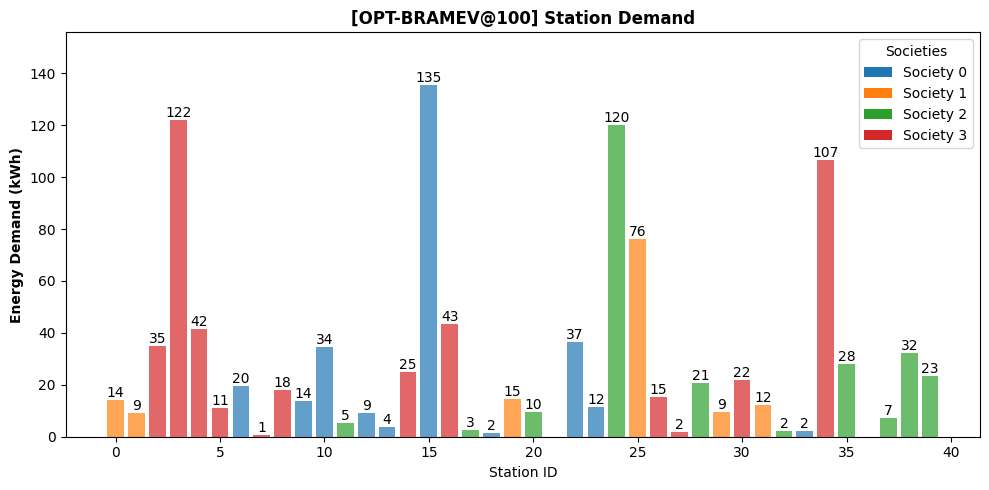

In [122]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

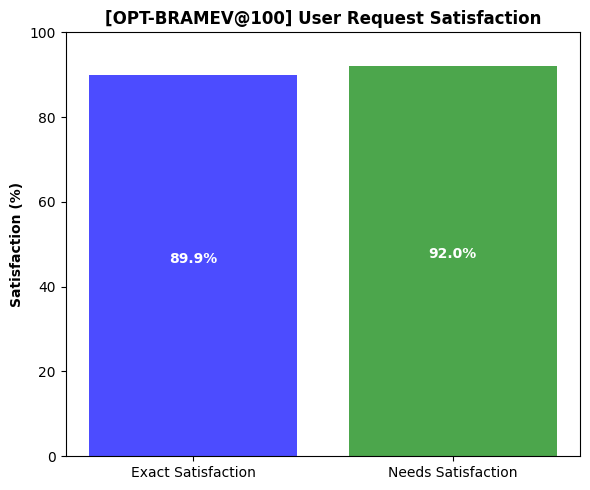

In [123]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

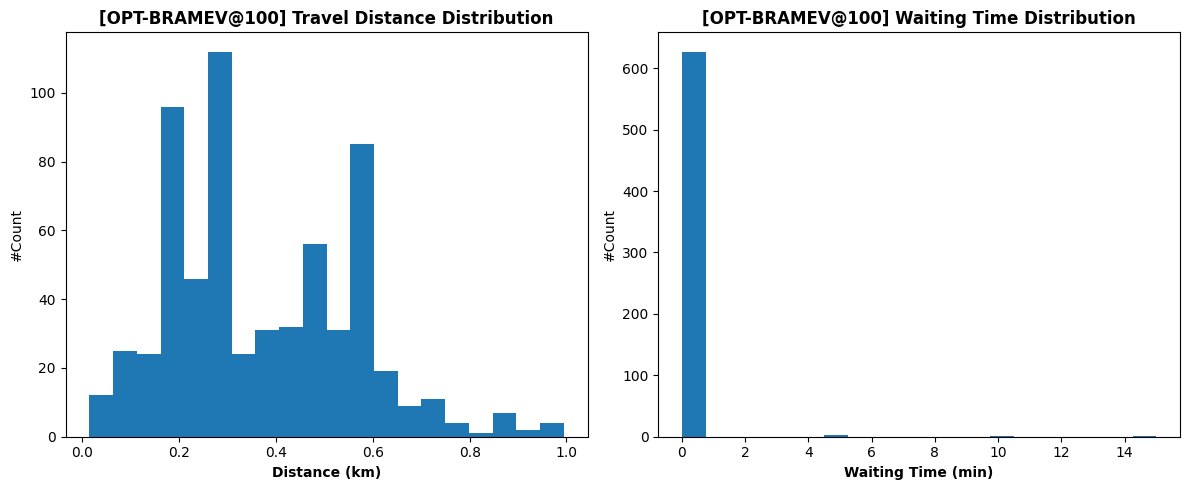

In [124]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

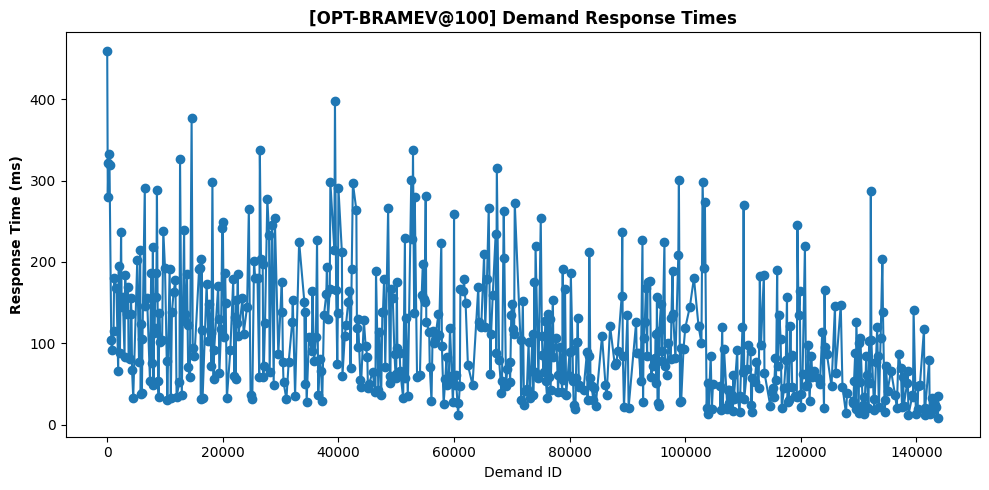

In [125]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

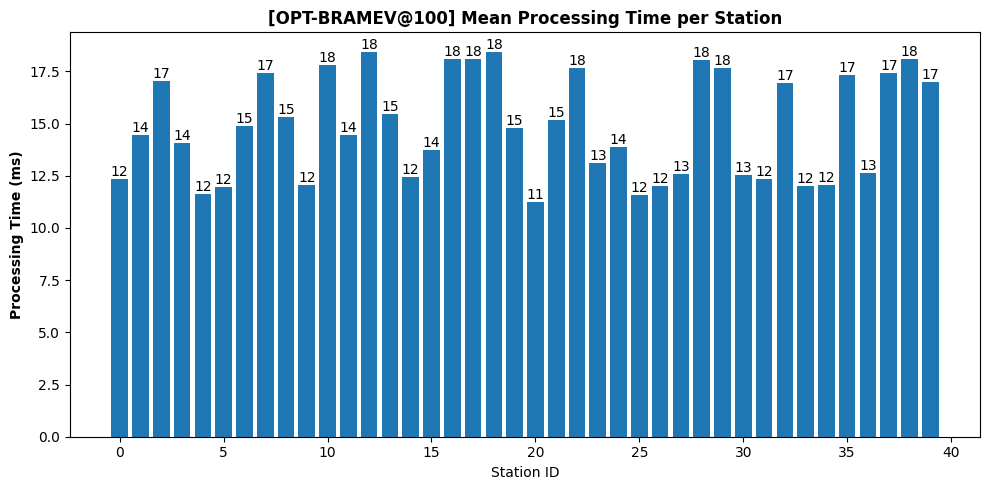

In [126]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

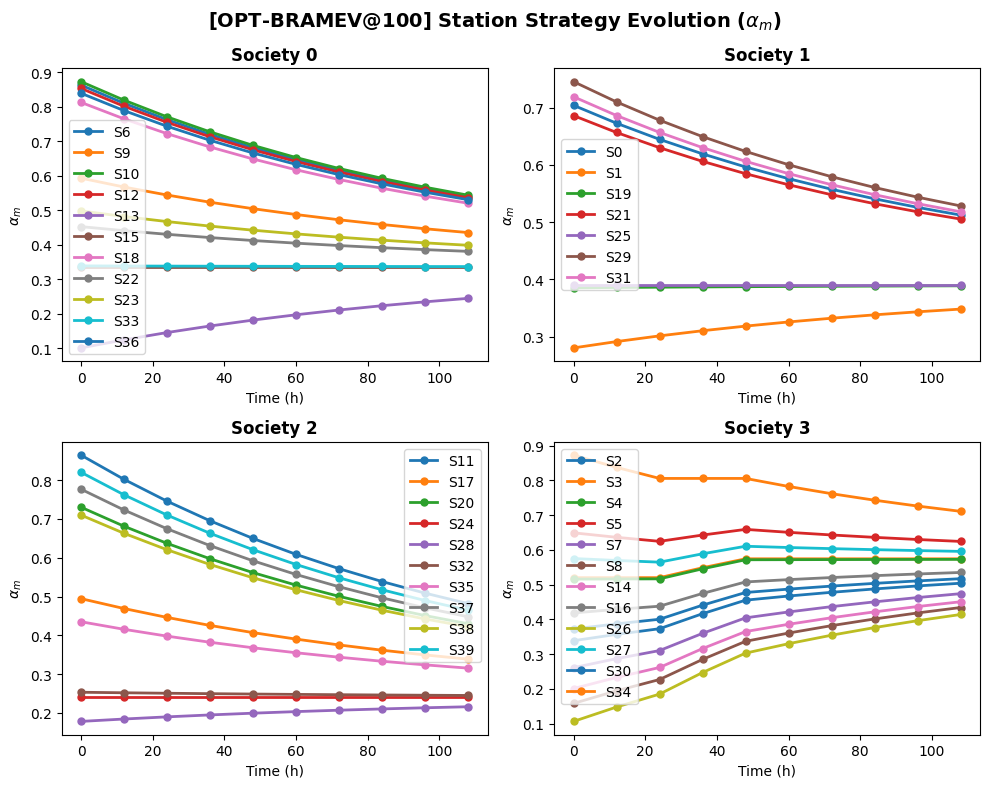

In [127]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [128]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           6  0.255556  0.045139  0.014583  0.000000  0.000000   
1            0           9  0.191667  0.000000  0.000000  0.000000       NaN   
2            0          10  0.327778  0.086111  0.000000  0.000000  0.000000   
3            0          12  0.125000  0.000000  0.000000  0.000000  0.000000   
4            0          13  0.064583  0.000000  0.000000  0.000000  0.000000   
5            0          15  0.649306  0.590972  0.244444  0.248611  0.272222   
6            0          18  0.020833  0.000000  0.000000  0.000000  0.000000   
7            0          22  0.312500  0.165278  0.050694  0.000000  0.000000   
8            0          23  0.171528  0.000000  0.000000  0.000000       NaN   
9            0          33  0.029861  0.000000  0.000000  0.000000       NaN   
10           0          36  0.000000  0.000000  0.000000  0.000000       NaN   
11           1           0  0.198611  0.

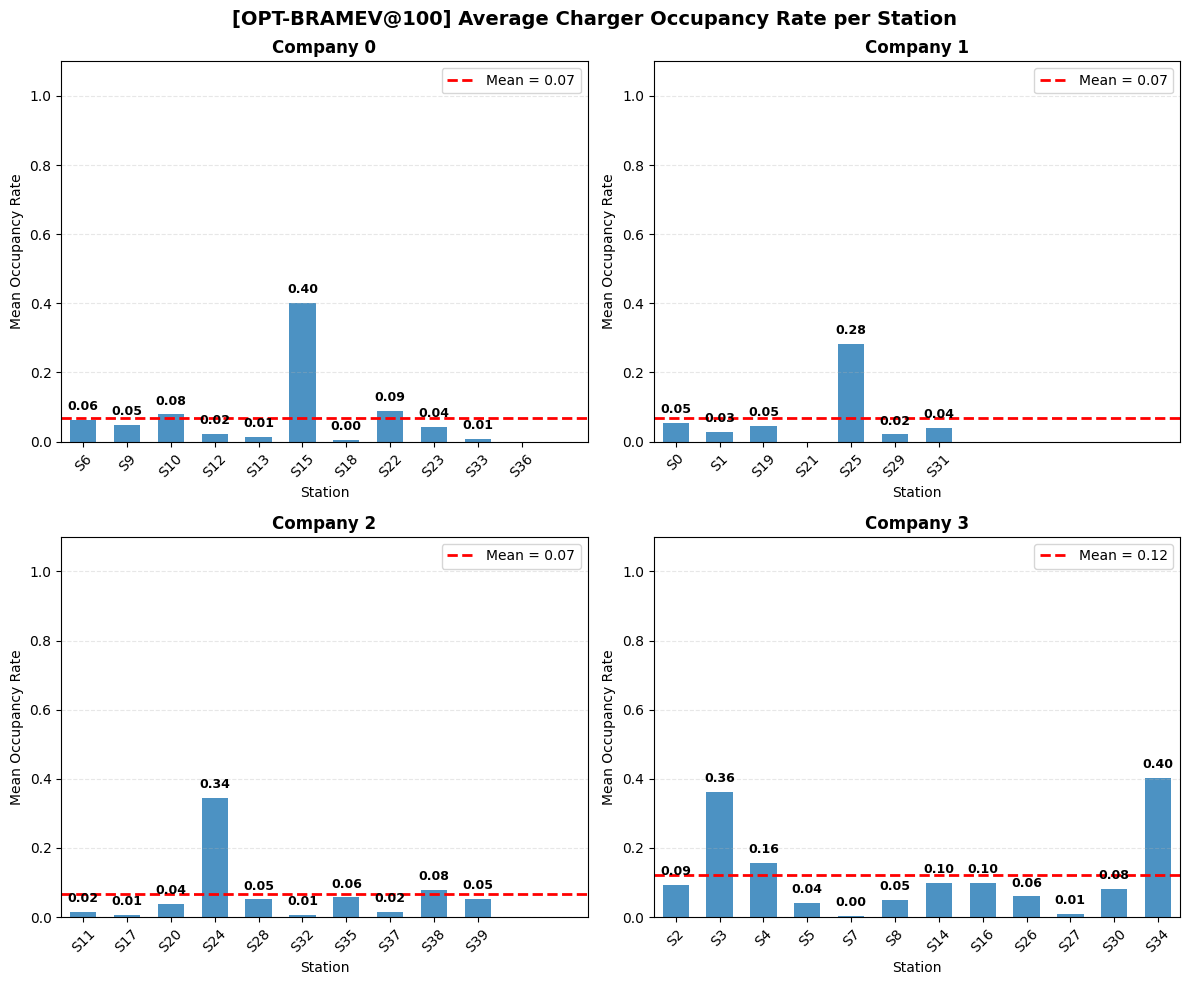

In [129]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

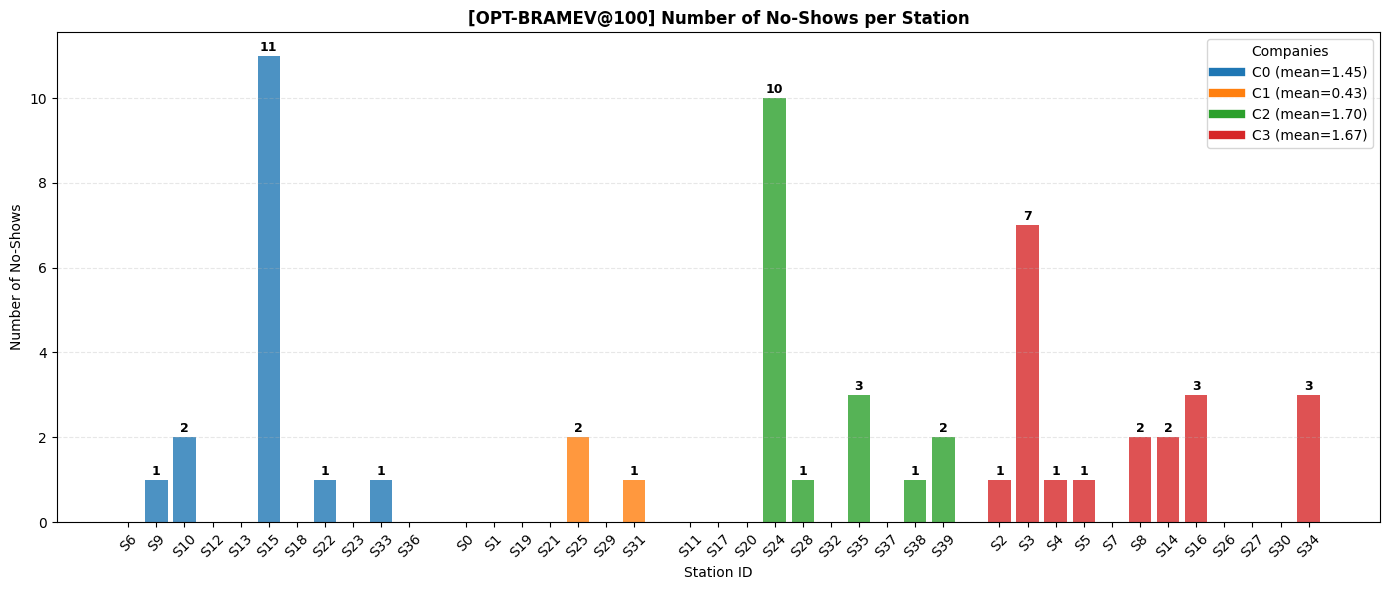

In [130]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [131]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,6,12,12,0,0,0,1.000000,0.000000,0.0,0.0
1,0,9,9,8,1,0,0,0.888889,0.111111,0.0,0.0
2,0,10,22,20,2,0,0,0.909091,0.090909,0.0,0.0
3,0,12,5,5,0,0,0,1.000000,0.000000,0.0,0.0
4,0,13,2,2,0,0,0,1.000000,0.000000,0.0,0.0
5,0,15,90,78,11,0,0,0.866667,0.122222,0.0,0.0
6,0,18,1,1,0,0,0,1.000000,0.000000,0.0,0.0
7,0,22,22,21,1,0,0,0.954545,0.045455,0.0,0.0
8,0,23,6,6,0,0,0,1.000000,0.000000,0.0,0.0
9,0,33,3,1,1,0,0,0.333333,0.333333,0.0,0.0


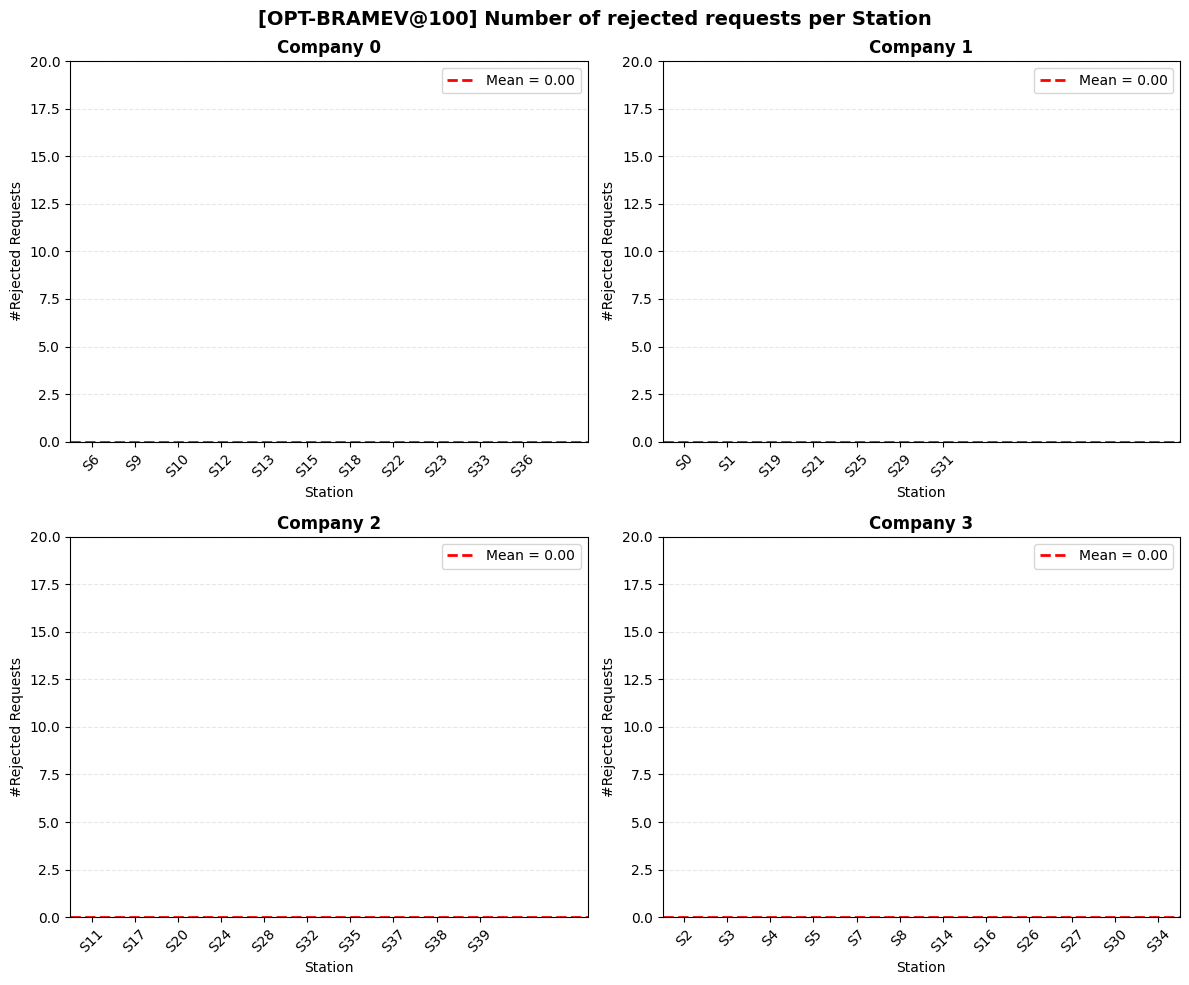

In [132]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [133]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

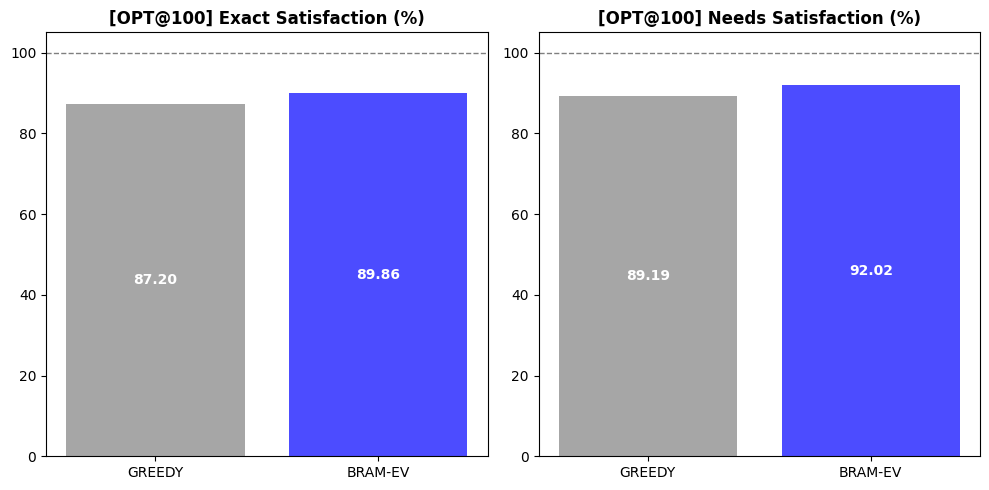

In [134]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

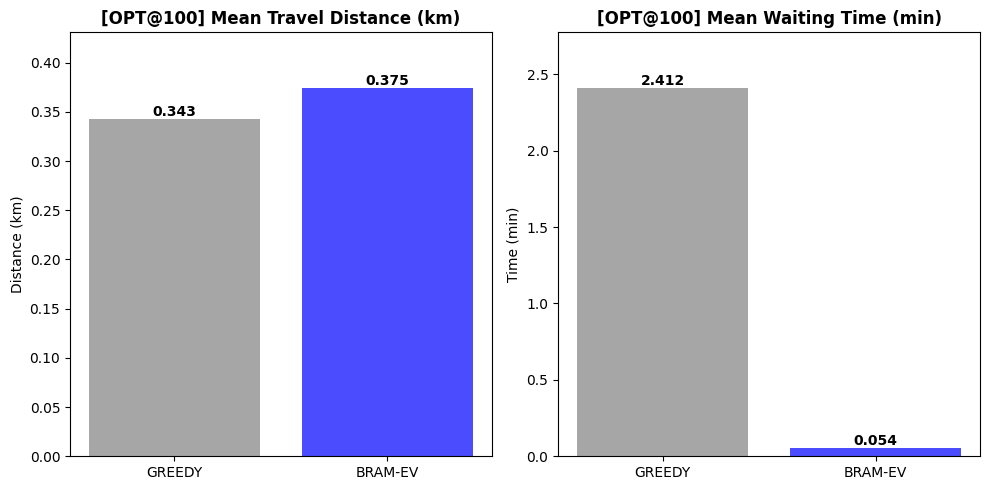

In [135]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

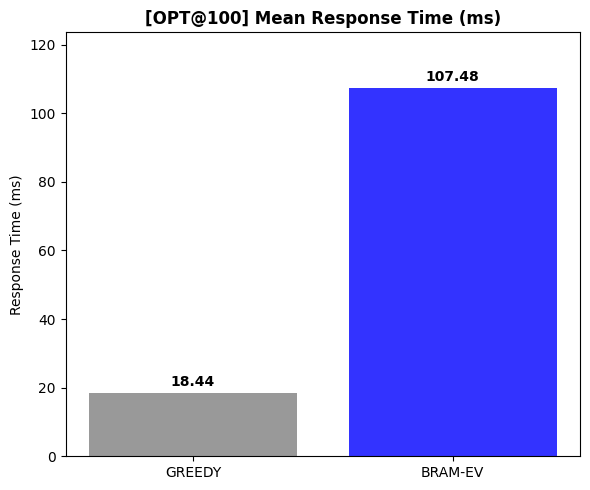

In [136]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [137]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [138]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [139]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [140]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:32:38.609 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:32:38.823 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:32:39.056 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:32:39.214 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:32:39.423 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:32:39.608 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:32:39.929 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:32:40.054 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:32:40.266 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:32:40.513 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:32:40.726 | IN

##### *Metrics*

In [141]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 36.97 kWh
  Station 1: 8.35 kWh
  Station 2: 61.39 kWh
  Station 3: 188.15 kWh
  Station 4: 66.09 kWh
  Station 5: 77.92 kWh
  Station 6: 40.09 kWh
  Station 7: 3.12 kWh
  Station 8: 26.68 kWh
  Station 9: 50.75 kWh
  Station 10: 66.21 kWh
  Station 11: 13.89 kWh
  Station 12: 2.07 kWh
  Station 13: 52.13 kWh
  Station 14: 1.27 kWh
  Station 15: 3.75 kWh
  Station 16: 1.75 kWh
  Station 17: 1.73 kWh
  Station 18: 8.53 kWh
  Station 19: 233.53 kWh
  Station 20: 26.68 kWh
  Station 21: 3.64 kWh
  Station 22: 186.48 kWh
  Station 23: 54.94 kWh
  Station 24: 10.31 kWh
  Station 25: 15.62 kWh
  Station 26: 34.92 kWh
  Station 27: 186.03 kWh
  Station 28: 21.23 kWh
  Station 29: 1.63 kWh
  Station 30: 0.00 kWh
  Station 31: 2.79 kWh
  Station 32: 45.28 kWh
  Station 33: 6.20 kWh
  Station 34: 0.00 kWh
  Station 35: 5.29 kWh
  Station 36: 13.65 kWh
  Station 37: 14.47 kWh
  Station 38: 11.38 kWh
  Station 39: 12.04 kW

In [142]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

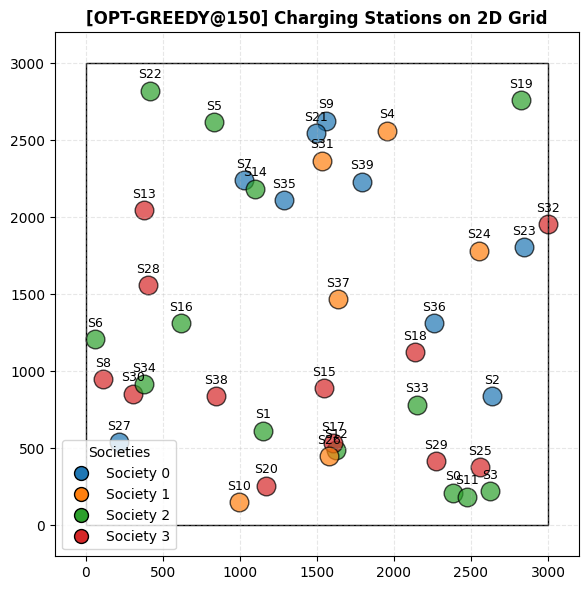

In [143]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

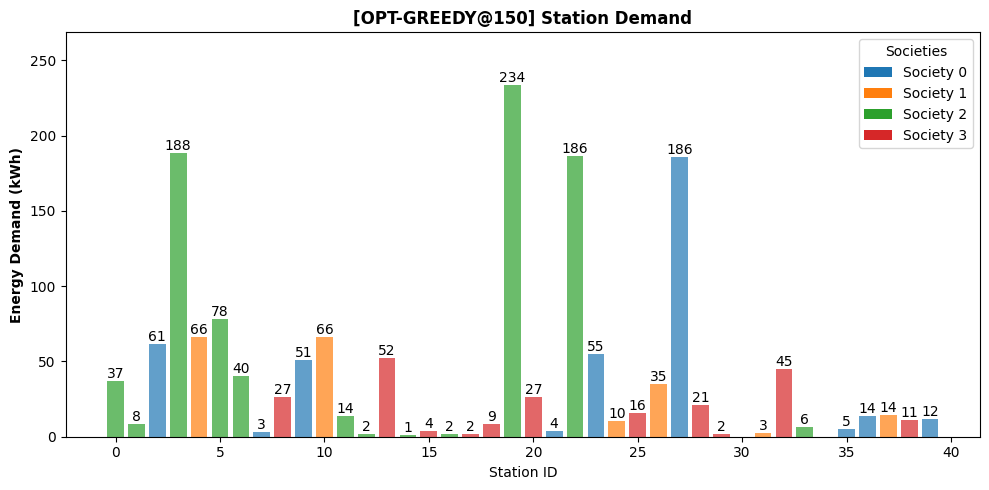

In [144]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

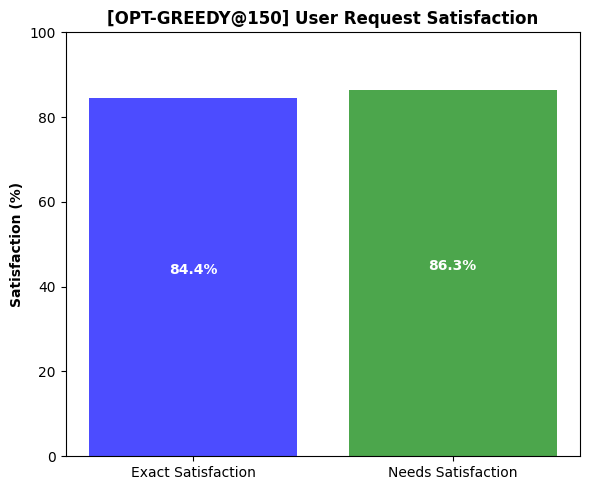

In [145]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

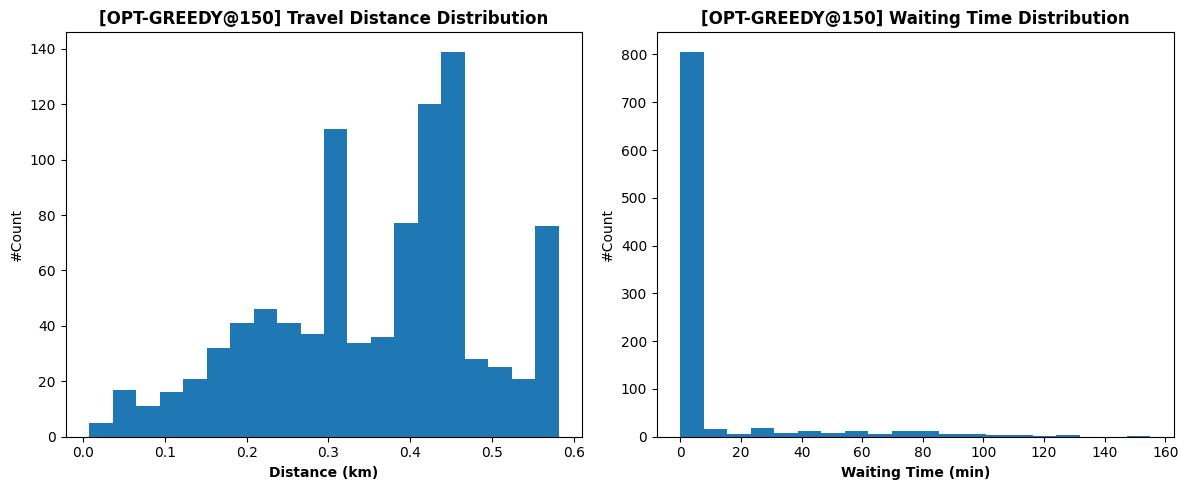

In [146]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

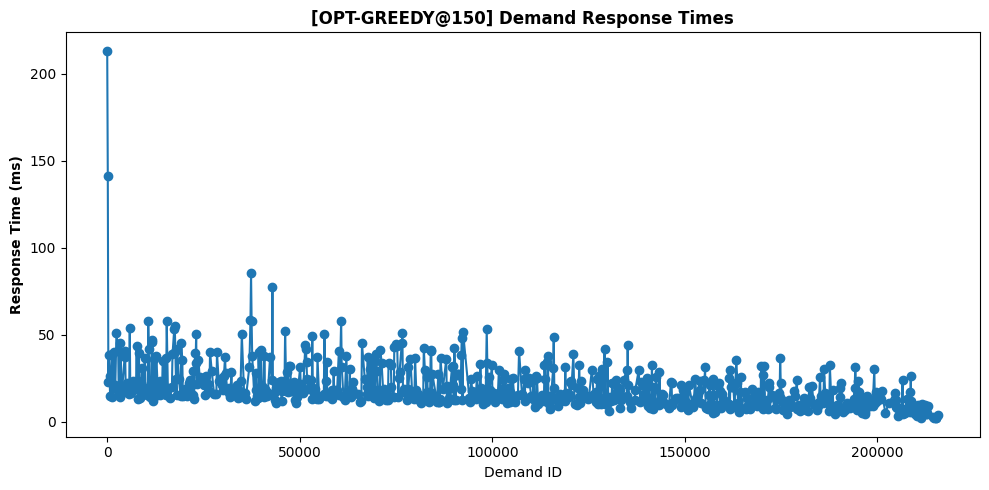

In [147]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

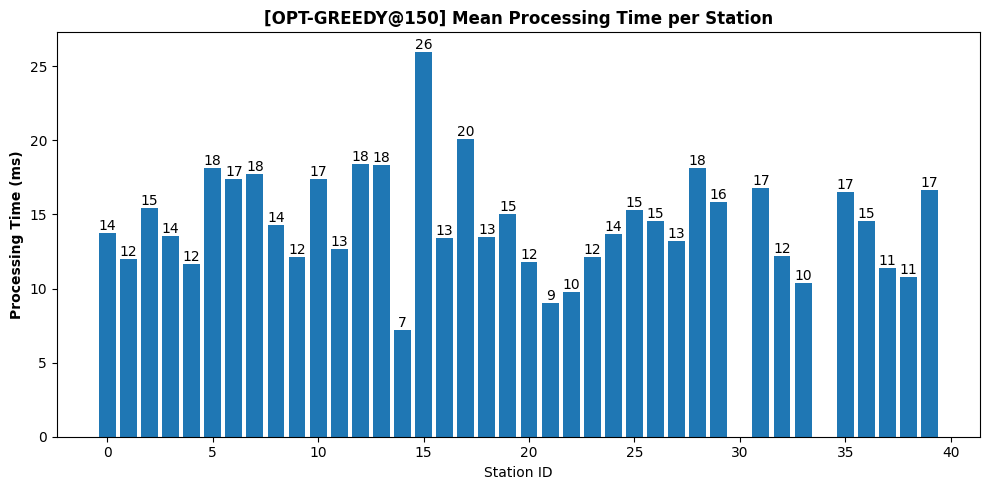

In [148]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [149]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.454167  0.361111  0.018750  0.000000  0.030556   
1            0           7  0.043056  0.000000  0.000000  0.000000  0.000000   
2            0           9  0.468056  0.236806  0.015278  0.079861       NaN   
3            0          21  0.059722  0.000000  0.000000  0.000000       NaN   
4            0          23  0.467361  0.265972  0.040972  0.071528       NaN   
5            0          27  0.752083  0.633333  0.468056  0.411806  0.531250   
6            0          35  0.065972  0.000000  0.000000  0.000000  0.000000   
7            0          36  0.169444  0.080556  0.000000  0.000000       NaN   
8            0          39  0.150694  0.000000  0.000000  0.000000  0.036806   
9            1           4  0.541667  0.358333  0.062500  0.116667       NaN   
10           1          10  0.515972  0.315972  0.017361  0.000694  0.029861   
11           1          24  0.141667  0.

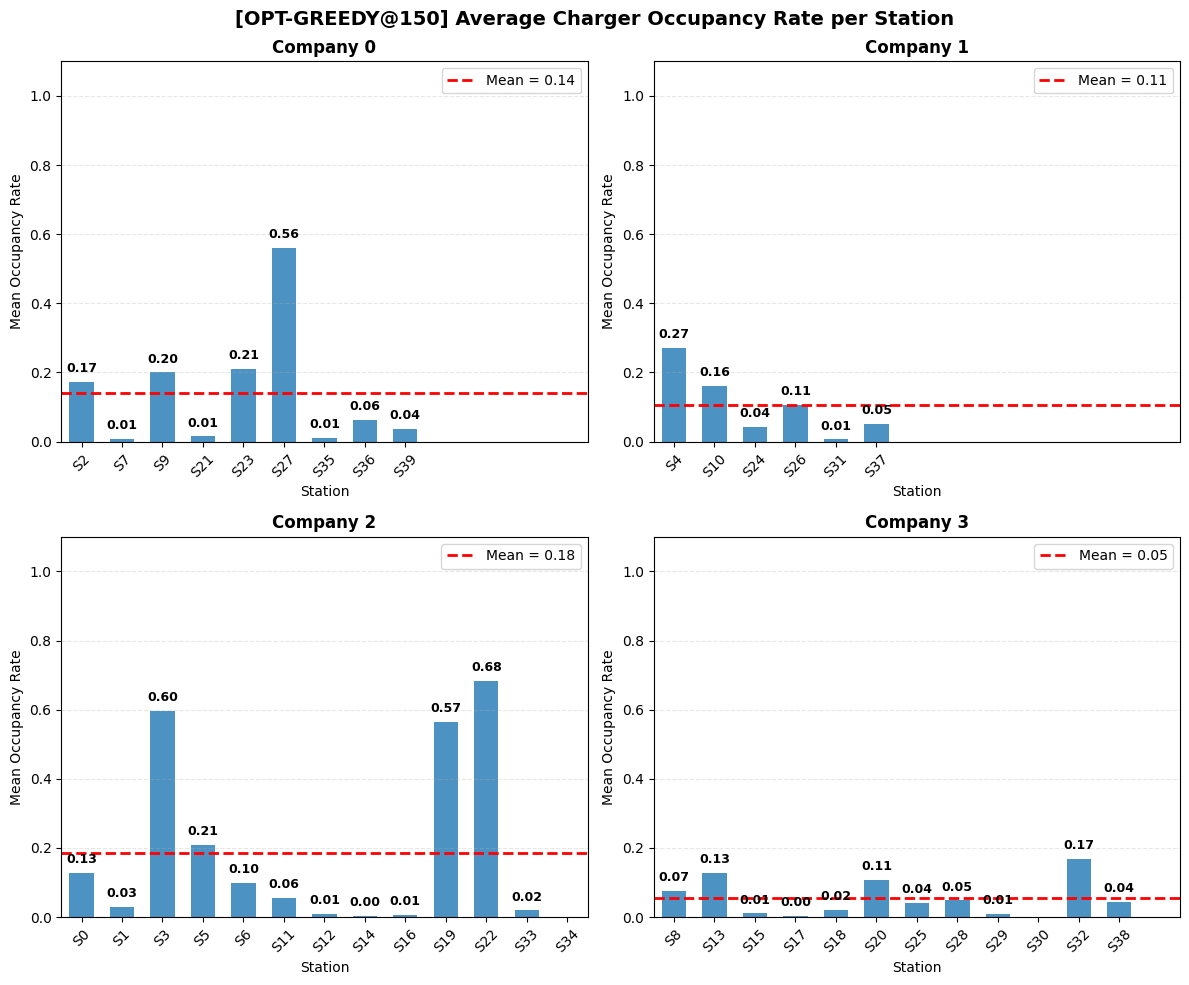

In [150]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

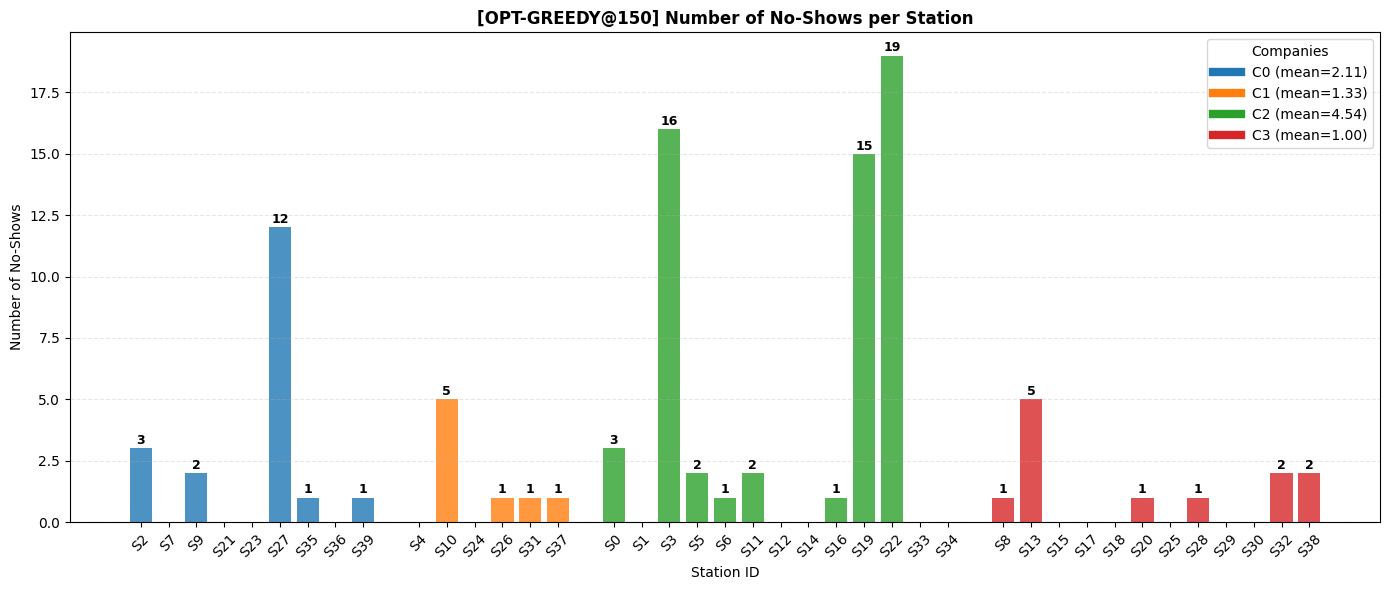

In [151]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [152]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,35,32,3,0,0,0.914286,0.085714,0.0,0.0
1,0,7,2,2,0,0,0,1.000000,0.000000,0.0,0.0
2,0,9,30,28,2,0,0,0.933333,0.066667,0.0,0.0
3,0,21,2,2,0,0,0,1.000000,0.000000,0.0,0.0
4,0,23,30,30,0,0,0,1.000000,0.000000,0.0,0.0
5,0,27,121,108,12,0,0,0.892562,0.099174,0.0,0.0
6,0,35,5,4,1,0,0,0.800000,0.200000,0.0,0.0
7,0,36,7,7,0,0,0,1.000000,0.000000,0.0,0.0
8,0,39,7,6,1,0,0,0.857143,0.142857,0.0,0.0
9,1,4,41,41,0,0,0,1.000000,0.000000,0.0,0.0


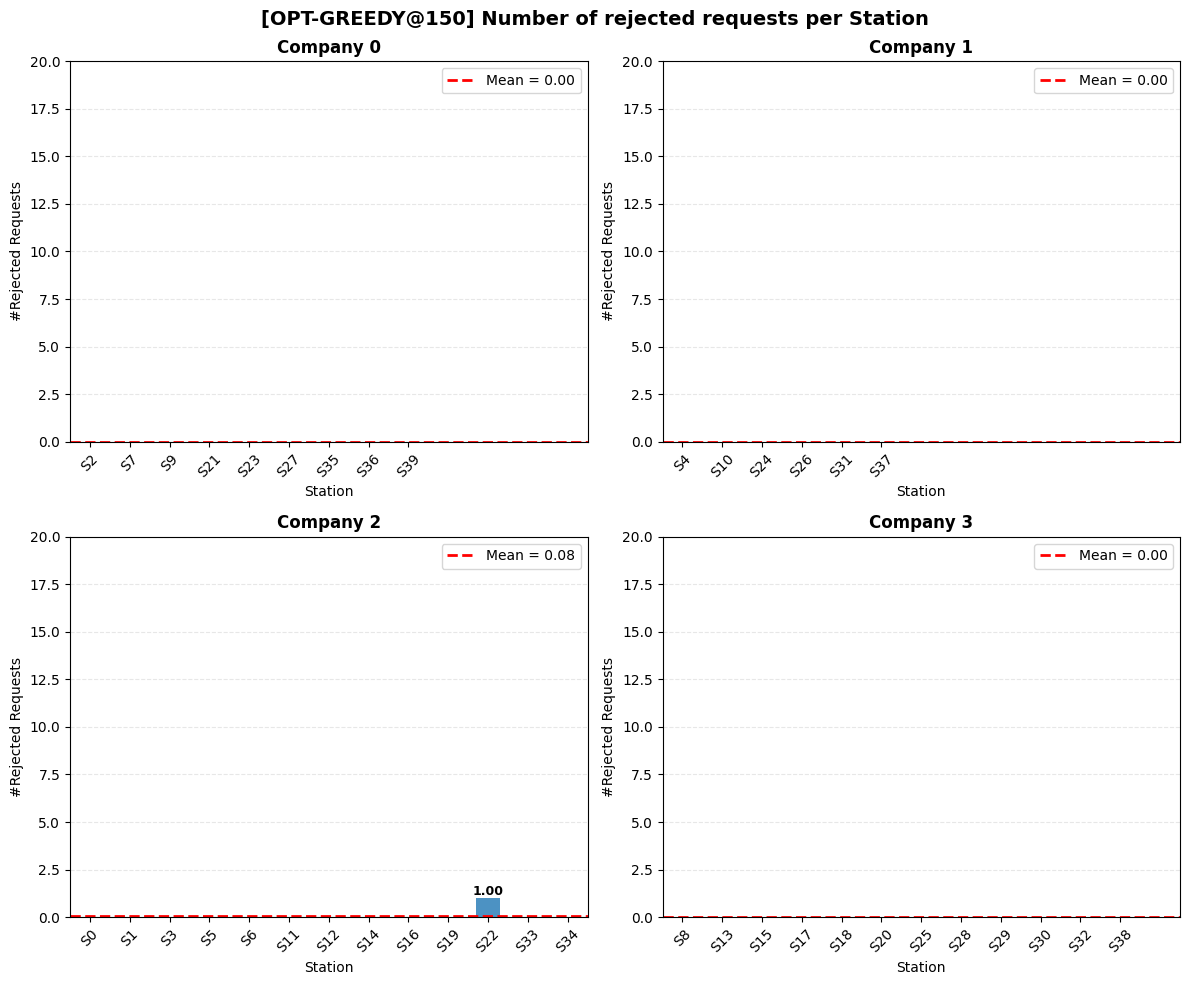

In [153]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [154]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [155]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [156]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:33:03.538 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:33:05.738 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:33:07.111 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:33:07.877 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:33:08.829 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:33:10.038 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:33:10.690 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:33:11.596 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:33:13.144 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:33:14.356 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:33:15.041 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [157]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 9.43 kWh
  Station 1: 22.80 kWh
  Station 2: 20.23 kWh
  Station 3: 38.62 kWh
  Station 4: 7.18 kWh
  Station 5: 165.57 kWh
  Station 6: 67.04 kWh
  Station 7: 30.23 kWh
  Station 8: 19.38 kWh
  Station 9: 27.70 kWh
  Station 10: 9.38 kWh
  Station 11: 59.78 kWh
  Station 12: 5.21 kWh
  Station 13: 3.66 kWh
  Station 14: 149.50 kWh
  Station 15: 41.34 kWh
  Station 16: 8.07 kWh
  Station 17: 22.02 kWh
  Station 18: 2.38 kWh
  Station 19: 44.07 kWh
  Station 20: 8.62 kWh
  Station 21: 56.44 kWh
  Station 22: 188.02 kWh
  Station 23: 4.64 kWh
  Station 24: 13.82 kWh
  Station 25: 22.88 kWh
  Station 26: 5.63 kWh
  Station 27: 5.92 kWh
  Station 28: 4.92 kWh
  Station 29: 48.32 kWh
  Station 30: 24.22 kWh
  Station 31: 16.02 kWh
  Station 32: 43.59 kWh
  Station 33: 95.28 kWh
  Station 34: 171.73 kWh
  Station 35: 9.10 kWh
  Station 36: 93.53 kWh
  Station 37: 7.77 kWh
  Station 38: 92.42 kWh
  Station 39: 6.98 kW

In [158]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

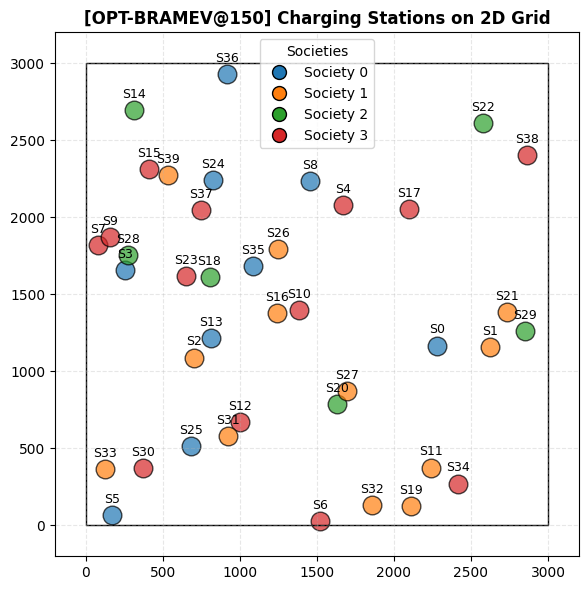

In [159]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

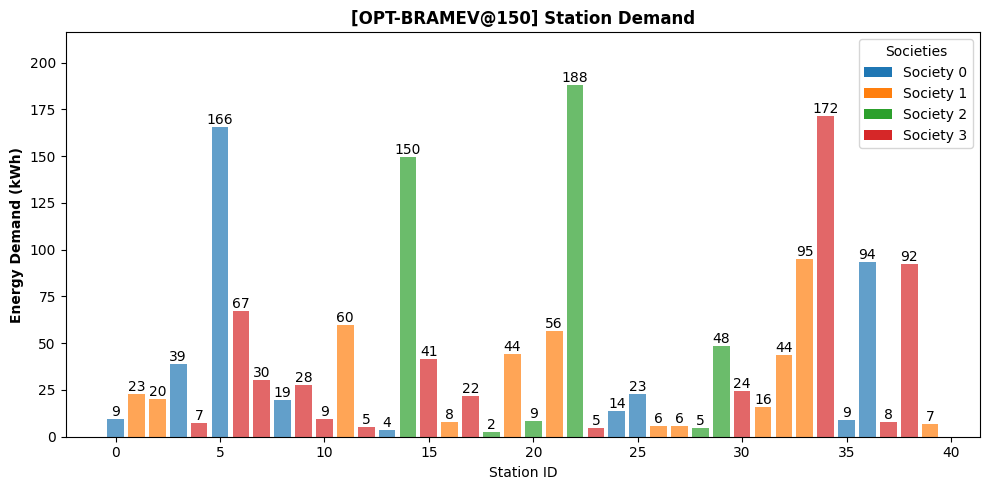

In [160]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

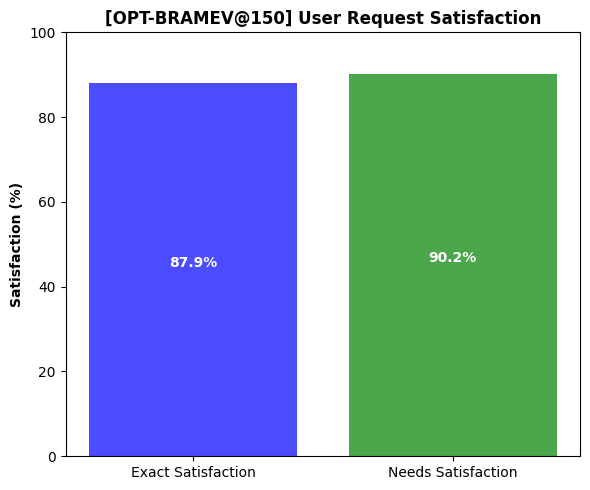

In [161]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

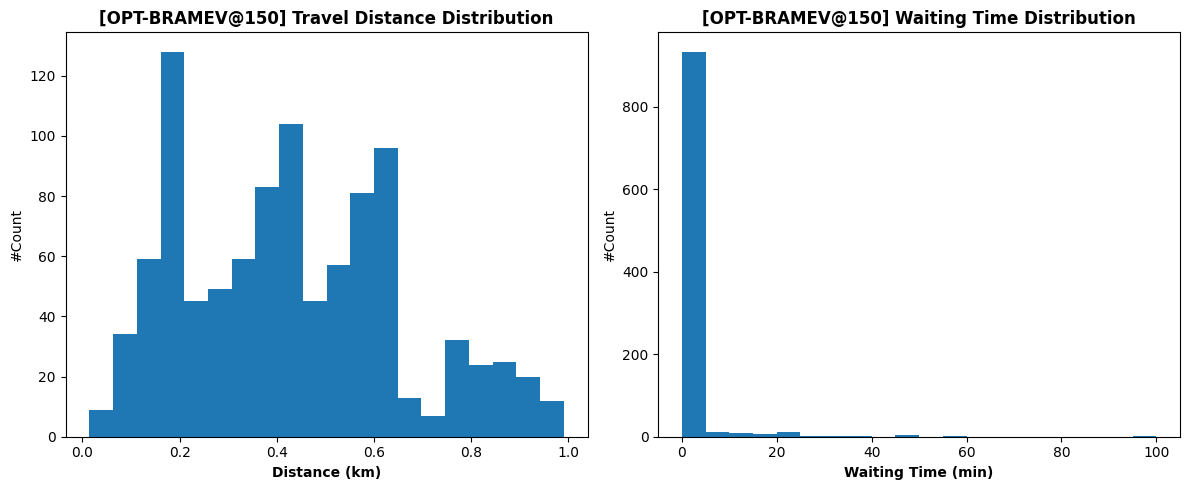

In [162]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

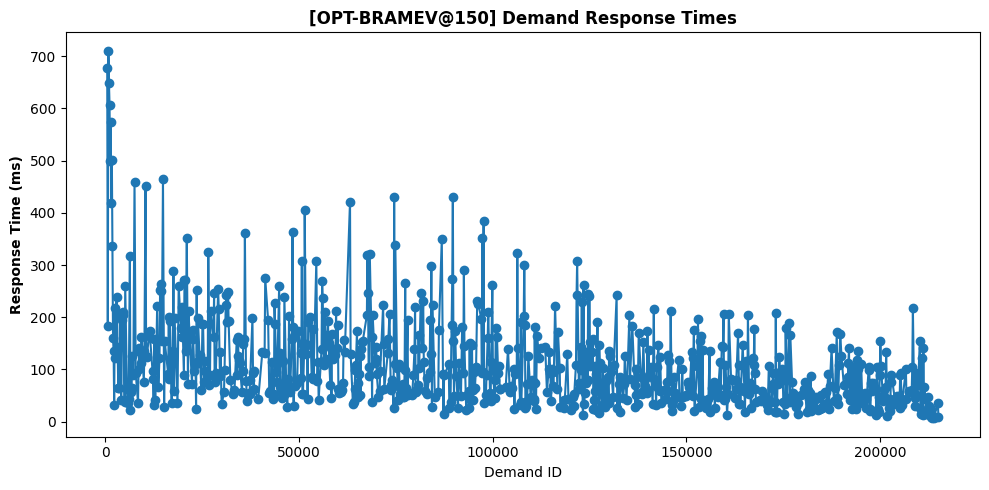

In [163]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

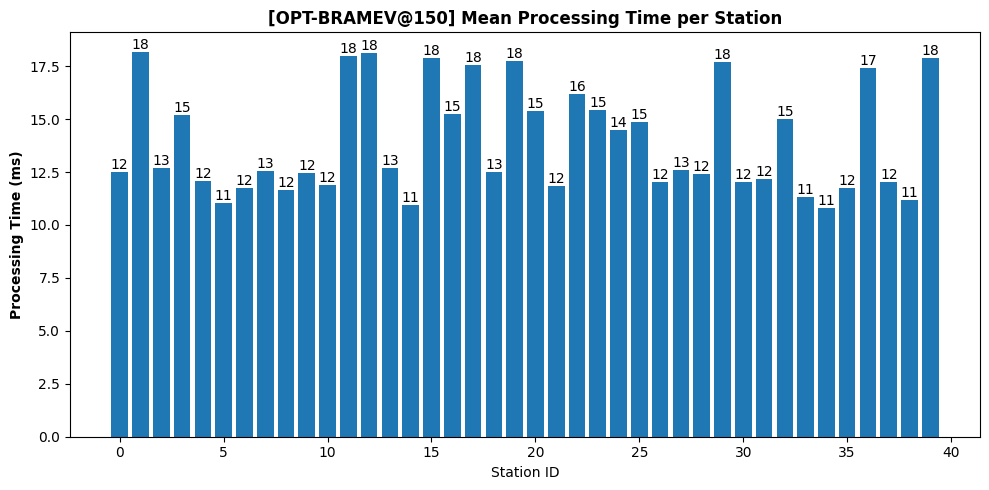

In [164]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

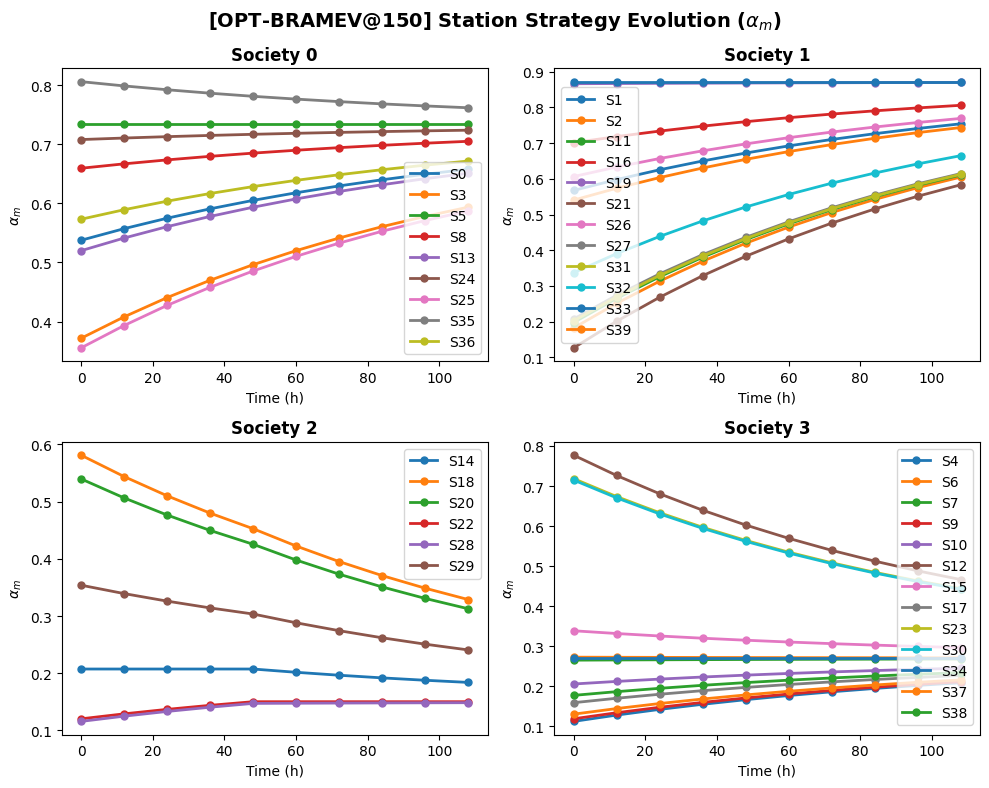

In [165]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [166]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.127083  0.000000  0.000000  0.000000       NaN   
1            0           3  0.288194  0.192361  0.060417  0.000000  0.029861   
2            0           5  0.735417  0.650000  0.427778  0.536806       NaN   
3            0           8  0.188194  0.068056  0.000000  0.000000       NaN   
4            0          13  0.056944  0.000000  0.000000  0.000000       NaN   
5            0          24  0.149306  0.025694  0.022222  0.000000  0.000000   
6            0          25  0.235417  0.052778  0.000000  0.000000  0.027083   
7            0          35  0.098611  0.026389  0.026389  0.000000       NaN   
8            0          36  0.504167  0.488889  0.147917  0.045833  0.035417   
9            1           1  0.279167  0.085417  0.000000  0.000000  0.000000   
10           1           2  0.163889  0.090278  0.039583  0.050000       NaN   
11           1          11  0.425694  0.

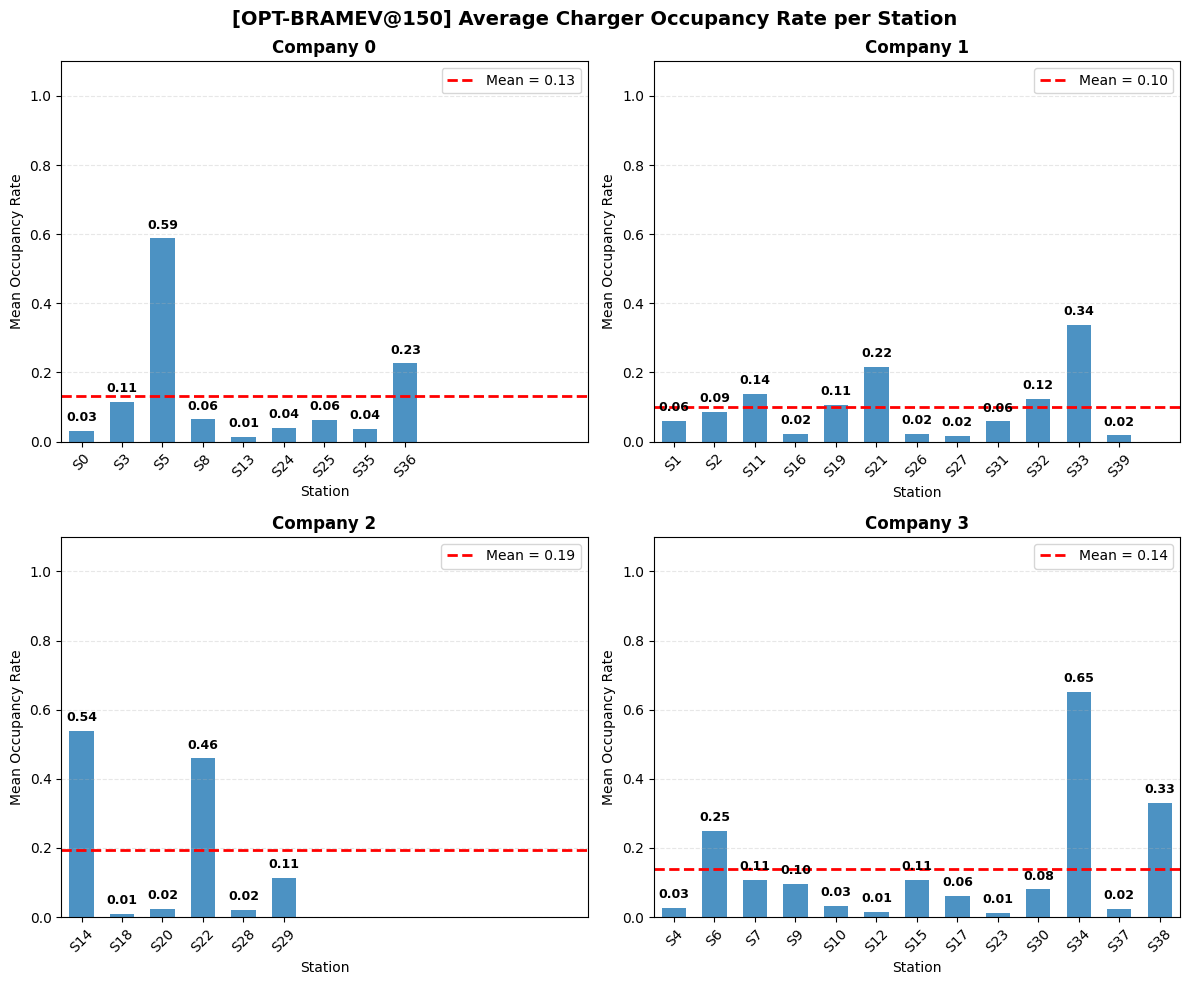

In [167]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

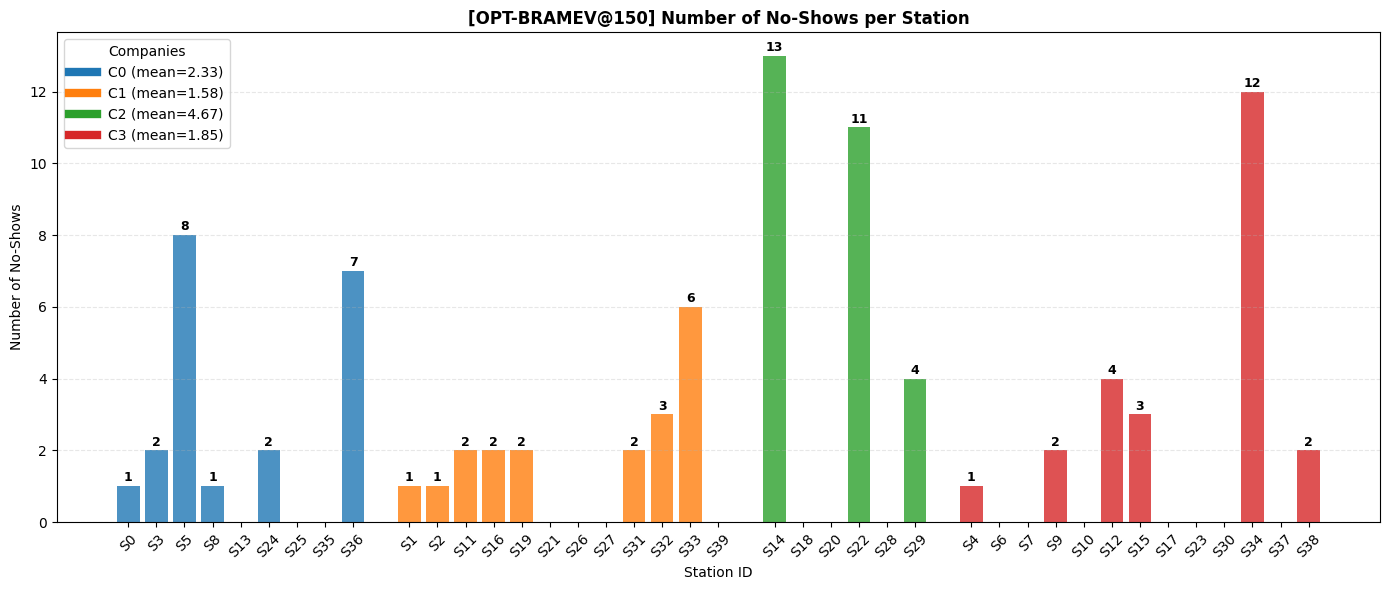

In [168]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [169]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,7,6,1,0,0,0.857143,0.142857,0.0,0.0
1,0,3,24,22,2,0,0,0.916667,0.083333,0.0,0.0
2,0,5,105,97,8,0,0,0.923810,0.076190,0.0,0.0
3,0,8,12,11,1,0,0,0.916667,0.083333,0.0,0.0
4,0,13,2,2,0,0,0,1.000000,0.000000,0.0,0.0
5,0,24,9,7,2,0,0,0.777778,0.222222,0.0,0.0
6,0,25,13,13,0,0,0,1.000000,0.000000,0.0,0.0
7,0,35,5,5,0,0,0,1.000000,0.000000,0.0,0.0
8,0,36,62,55,7,0,0,0.887097,0.112903,0.0,0.0
9,1,1,16,15,1,0,0,0.937500,0.062500,0.0,0.0


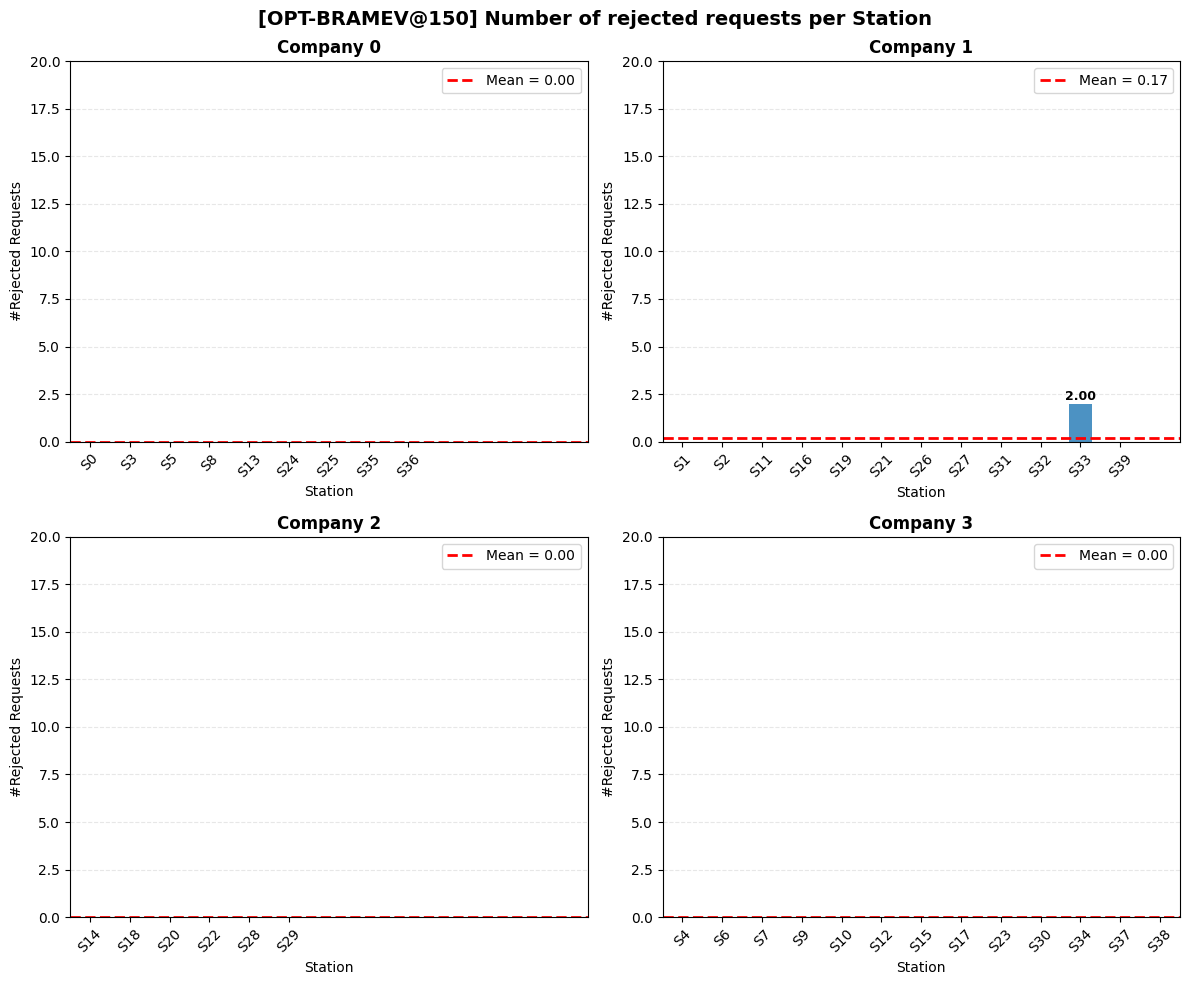

In [170]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [171]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

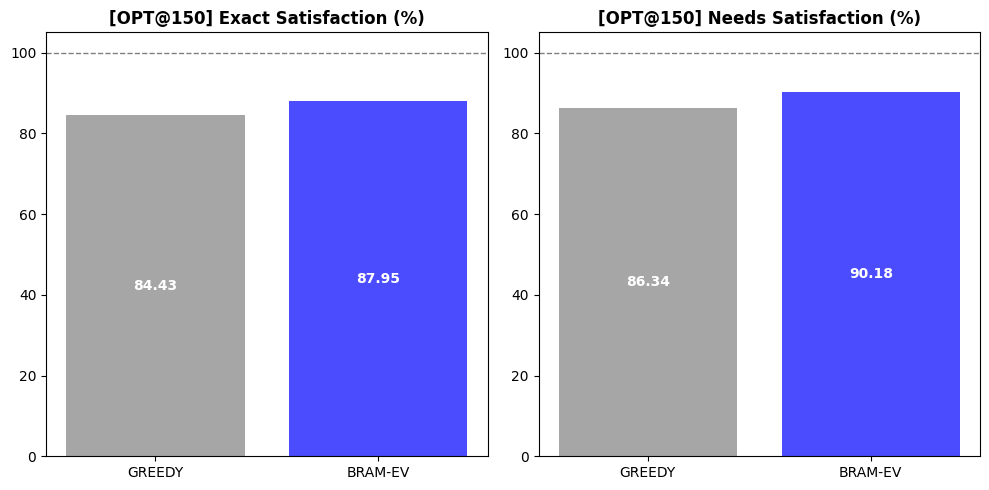

In [172]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

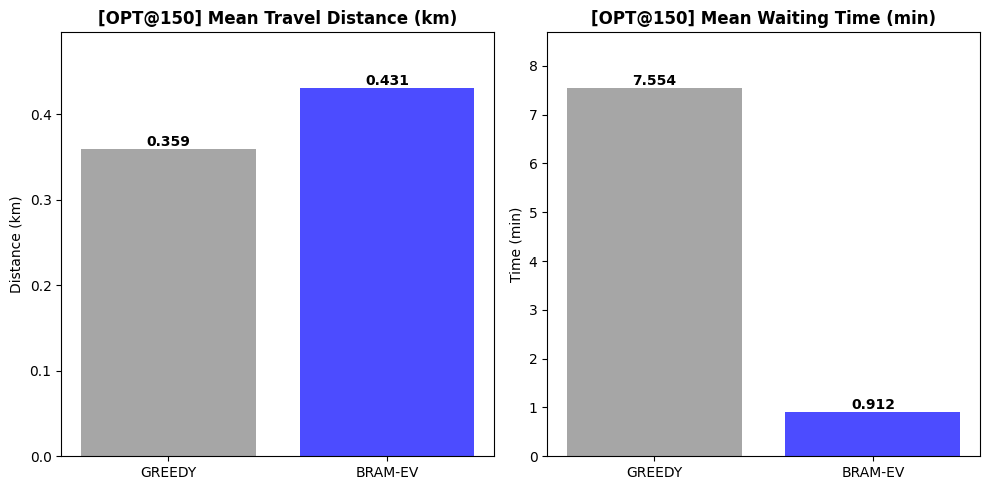

In [173]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

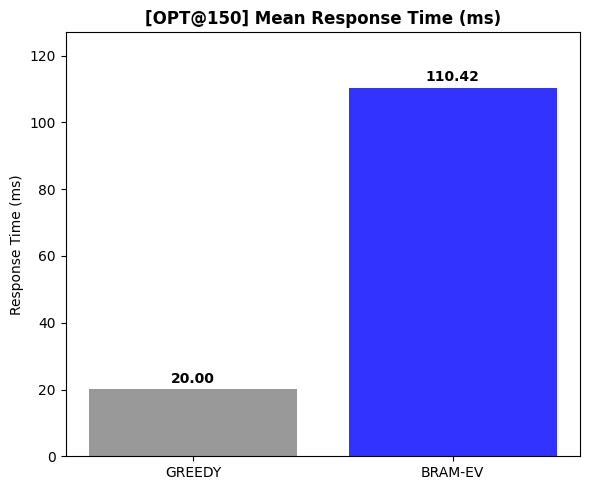

In [174]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [175]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [176]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [177]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [178]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:34:32.028 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:34:32.351 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:34:32.719 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:34:32.959 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:34:33.374 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:34:33.740 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:34:34.154 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:34:34.491 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:34:34.972 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:34:35.376 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:34:35.612 | IN

##### *Metrics*

In [179]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 3.00 kWh
  Station 1: 29.61 kWh
  Station 2: 1.29 kWh
  Station 3: 8.71 kWh
  Station 4: 24.25 kWh
  Station 5: 97.01 kWh
  Station 6: 5.42 kWh
  Station 7: 3.19 kWh
  Station 8: 30.57 kWh
  Station 9: 330.13 kWh
  Station 10: 98.91 kWh
  Station 11: 2.97 kWh
  Station 12: 1.62 kWh
  Station 13: 1.05 kWh
  Station 14: 317.80 kWh
  Station 15: 7.08 kWh
  Station 16: 96.37 kWh
  Station 17: 3.19 kWh
  Station 18: 15.09 kWh
  Station 19: 53.52 kWh
  Station 20: 28.82 kWh
  Station 21: 9.57 kWh
  Station 22: 80.08 kWh
  Station 23: 4.03 kWh
  Station 24: 272.02 kWh
  Station 25: 0.00 kWh
  Station 26: 60.29 kWh
  Station 27: 35.58 kWh
  Station 28: 12.51 kWh
  Station 29: 236.38 kWh
  Station 30: 14.35 kWh
  Station 31: 6.40 kWh
  Station 32: 12.41 kWh
  Station 33: 136.06 kWh
  Station 34: 58.33 kWh
  Station 35: 4.45 kWh
  Station 36: 3.68 kWh
  Station 37: 27.70 kWh
  Station 38: 3.93 kWh
  Station 39: 13.02 kWh

In [180]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

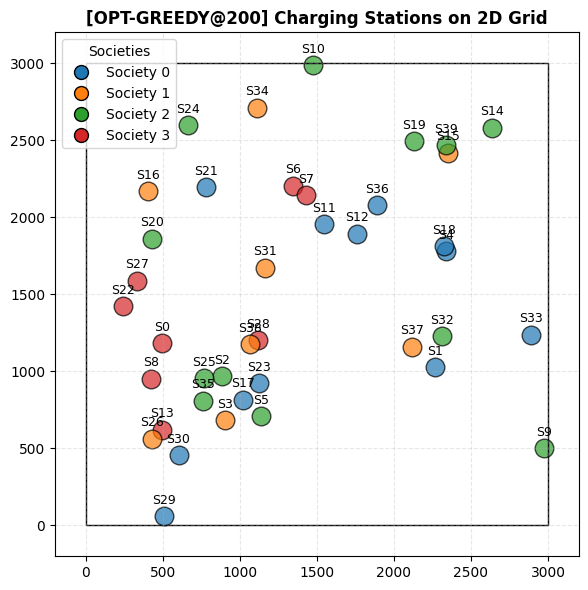

In [181]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

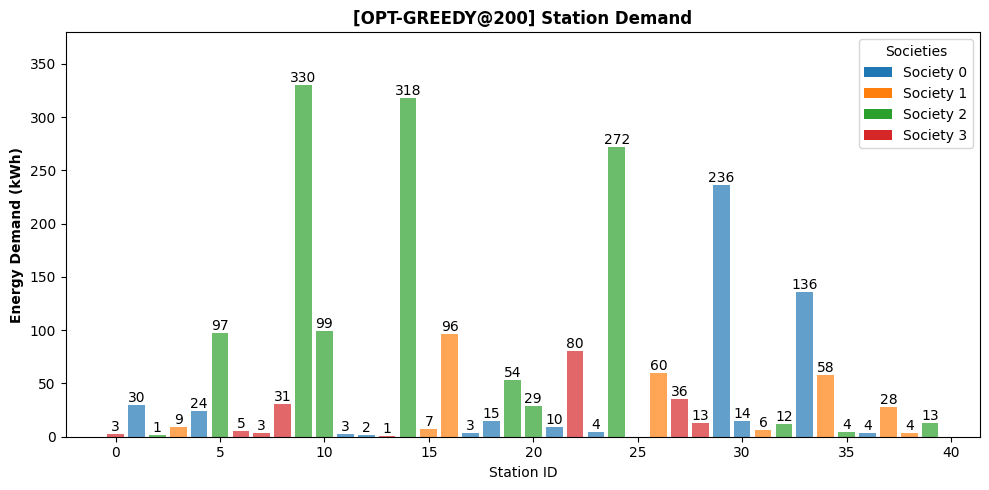

In [182]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

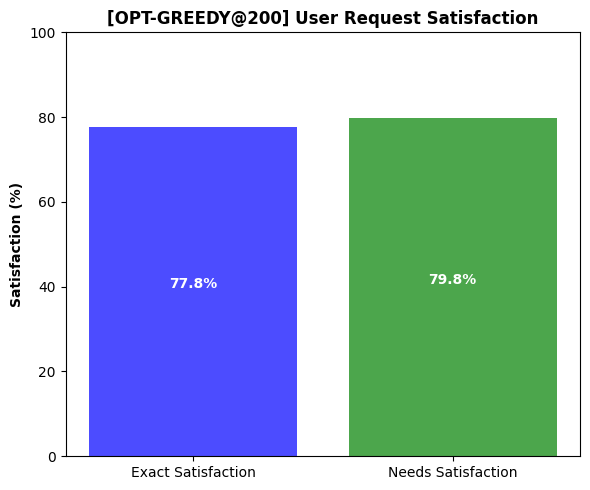

In [183]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

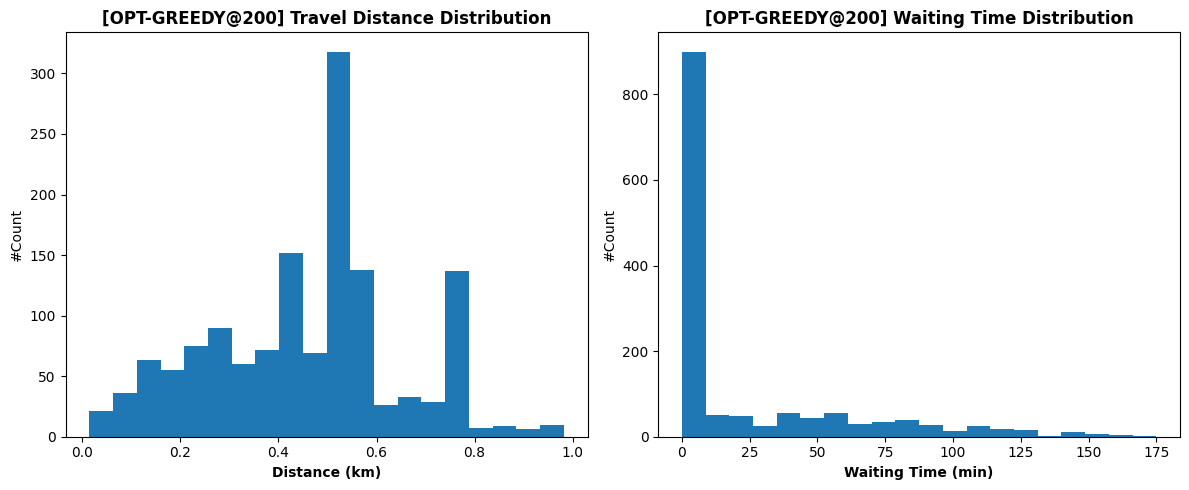

In [184]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

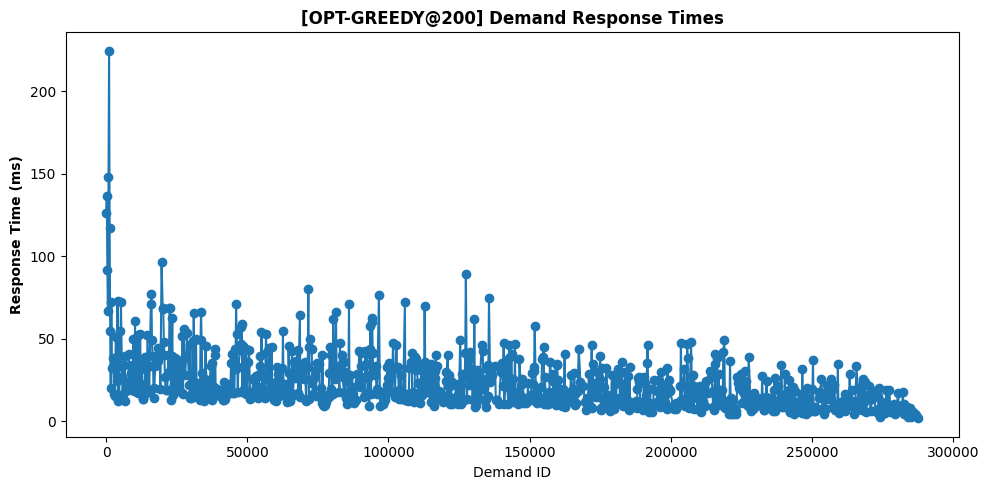

In [185]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

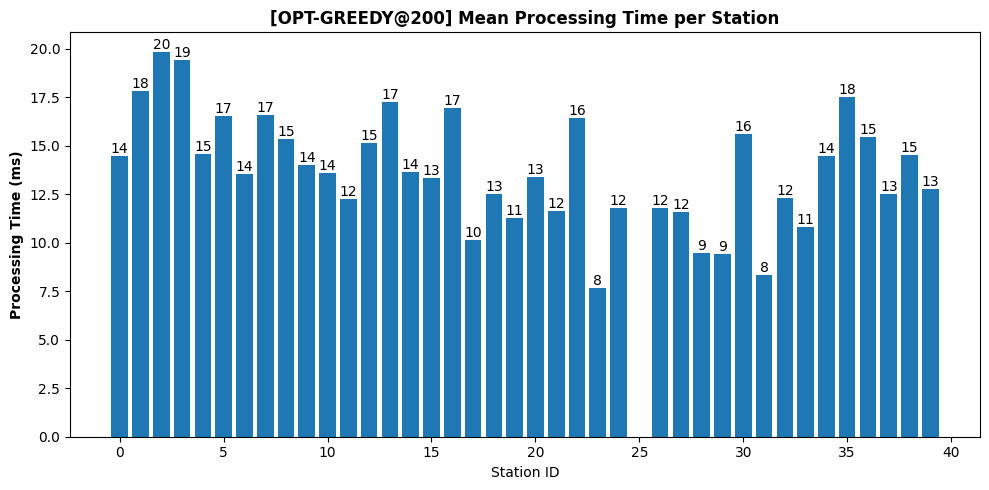

In [186]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [187]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.325694  0.051389  0.000000  0.000000  0.000000   
1            0           4  0.201389  0.151389  0.000000  0.000000  0.000000   
2            0          11  0.061806  0.000000  0.000000  0.000000       NaN   
3            0          12  0.027083  0.000000  0.000000  0.000000  0.000000   
4            0          17  0.045139  0.000000  0.000000  0.000000  0.000000   
5            0          18  0.106250  0.047222  0.000000  0.024306       NaN   
6            0          21  0.079861  0.019444  0.000000  0.016667       NaN   
7            0          23  0.054167  0.000000  0.000000  0.000000  0.000000   
8            0          29  0.934028  0.799306  0.800000  0.779861       NaN   
9            0          30  0.136111  0.065972  0.000000  0.000000  0.000000   
10           0          33  0.583333  0.663194  0.249306  0.438889       NaN   
11           0          36  0.065278  0.

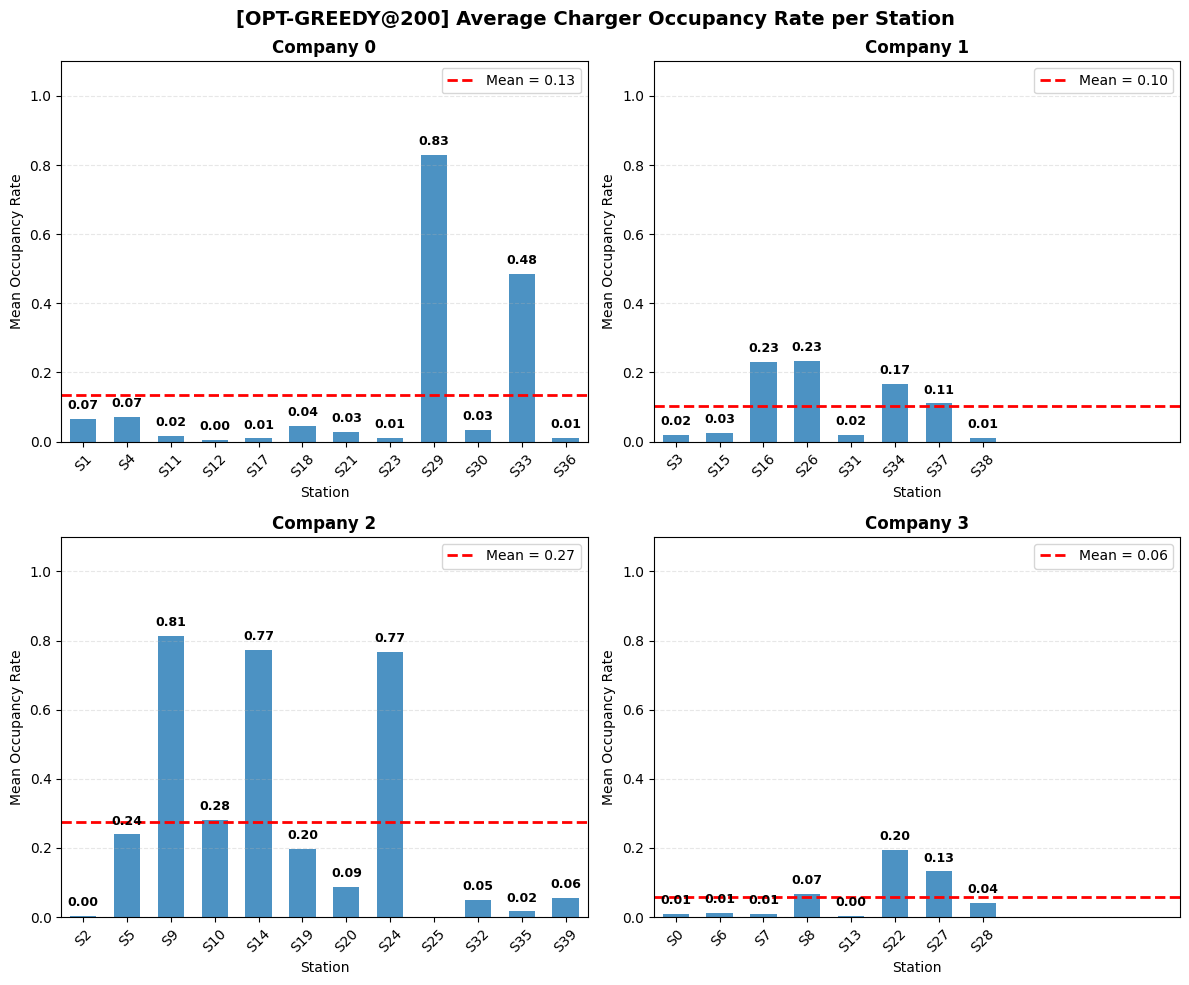

In [188]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

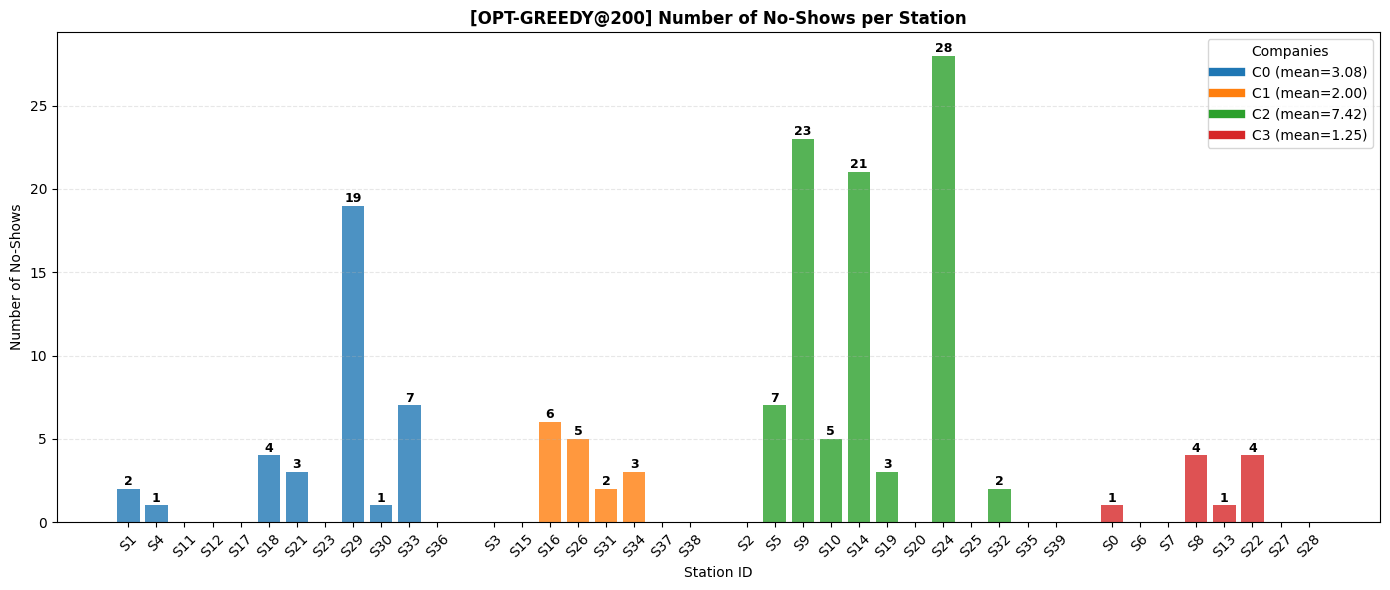

In [189]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [190]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,18,16,2,0,0,0.888889,0.111111,0.000000,0.000000
1,0,4,15,14,1,0,0,0.933333,0.066667,0.000000,0.000000
2,0,11,2,2,0,0,0,1.000000,0.000000,0.000000,0.000000
3,0,12,1,1,0,0,0,1.000000,0.000000,0.000000,0.000000
4,0,17,2,2,0,0,0,1.000000,0.000000,0.000000,0.000000
5,0,18,13,9,4,0,0,0.692308,0.307692,0.000000,0.000000
6,0,21,9,6,3,0,0,0.666667,0.333333,0.000000,0.000000
7,0,23,3,3,0,0,0,1.000000,0.000000,0.000000,0.000000
8,0,29,212,190,19,2,1,0.896226,0.089623,0.009434,0.004717
9,0,30,10,9,1,0,0,0.900000,0.100000,0.000000,0.000000


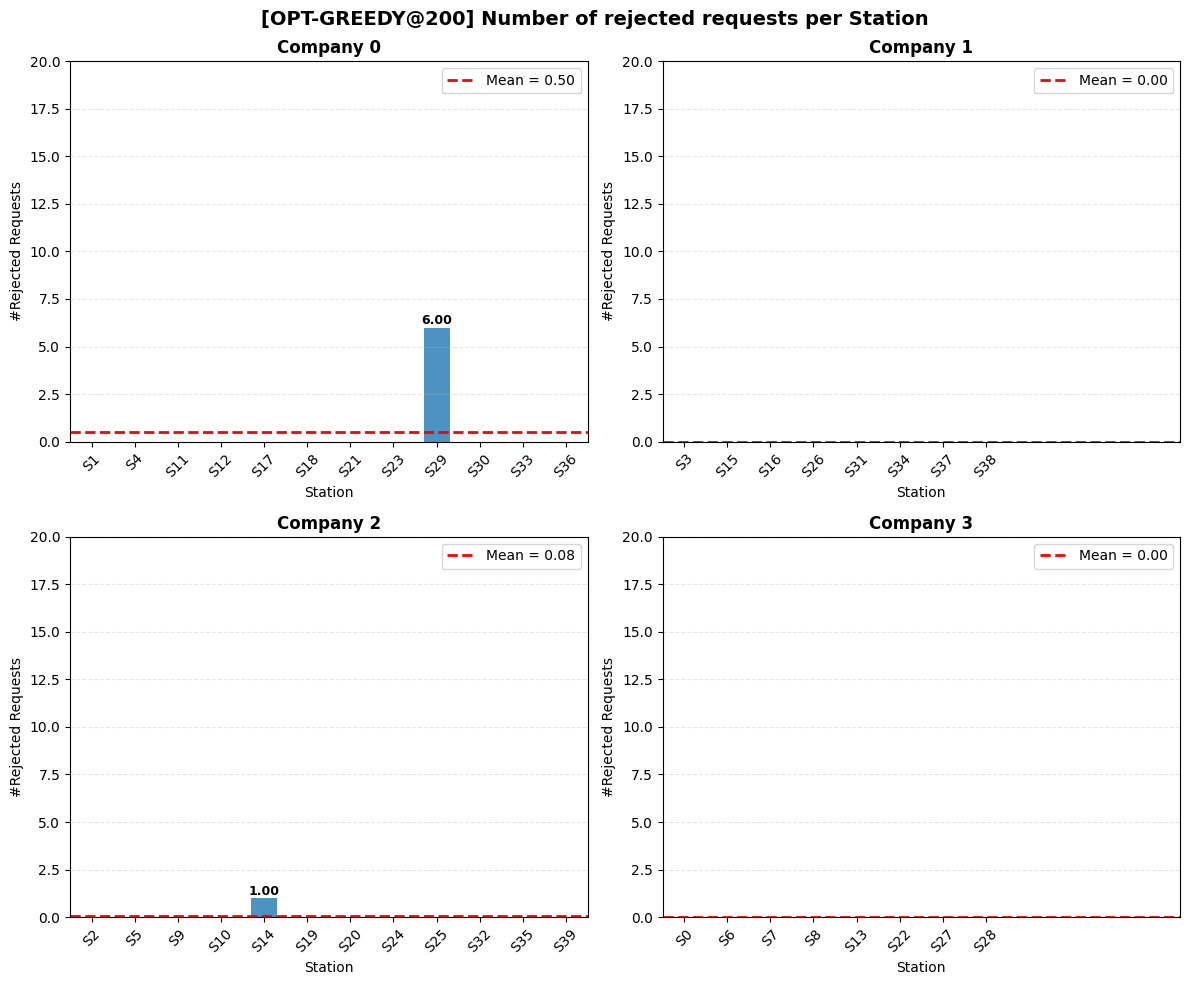

In [191]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [192]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [193]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [194]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:35:01.929 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:35:03.942 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:35:05.663 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:35:07.268 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:35:09.565 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:35:12.000 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:35:13.761 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:35:15.712 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:35:16.745 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:35:19.700 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:35:21.837 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [195]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 4.72 kWh
  Station 1: 8.89 kWh
  Station 2: 34.55 kWh
  Station 3: 70.88 kWh
  Station 4: 81.54 kWh
  Station 5: 36.80 kWh
  Station 6: 29.80 kWh
  Station 7: 228.90 kWh
  Station 8: 189.66 kWh
  Station 9: 32.04 kWh
  Station 10: 7.97 kWh
  Station 11: 155.97 kWh
  Station 12: 201.76 kWh
  Station 13: 31.76 kWh
  Station 14: 33.67 kWh
  Station 15: 48.72 kWh
  Station 16: 76.50 kWh
  Station 17: 11.53 kWh
  Station 18: 3.50 kWh
  Station 19: 65.82 kWh
  Station 20: 16.52 kWh
  Station 21: 75.00 kWh
  Station 22: 16.17 kWh
  Station 23: 21.04 kWh
  Station 24: 13.08 kWh
  Station 25: 138.48 kWh
  Station 26: 40.42 kWh
  Station 27: 14.38 kWh
  Station 28: 105.15 kWh
  Station 29: 11.87 kWh
  Station 30: 18.67 kWh
  Station 31: 76.57 kWh
  Station 32: 57.41 kWh
  Station 33: 12.58 kWh
  Station 34: 1.77 kWh
  Station 35: 85.33 kWh
  Station 36: 32.45 kWh
  Station 37: 96.12 kWh
  Station 38: 15.47 kWh
  Station 

In [196]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

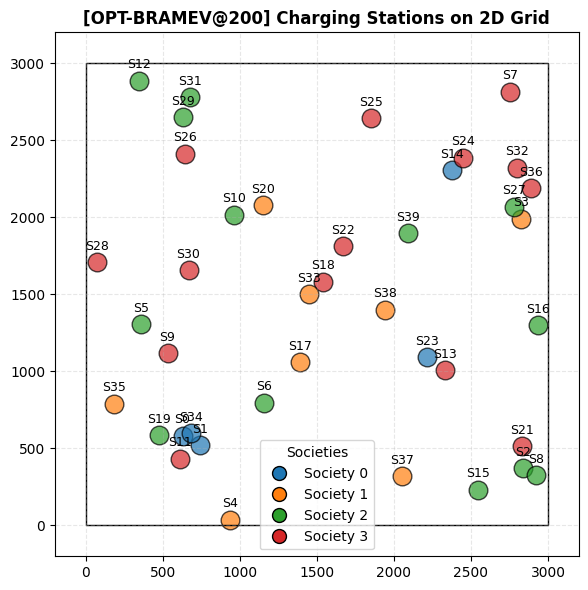

In [197]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

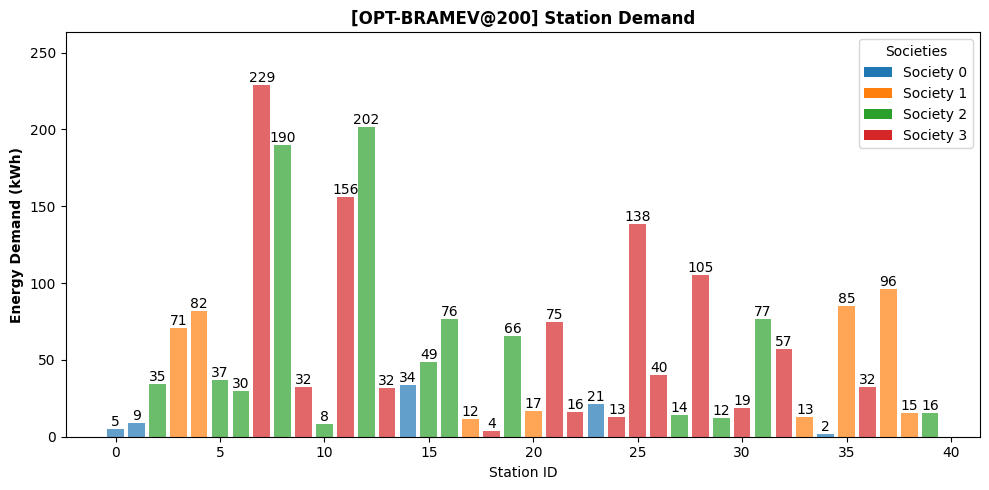

In [198]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

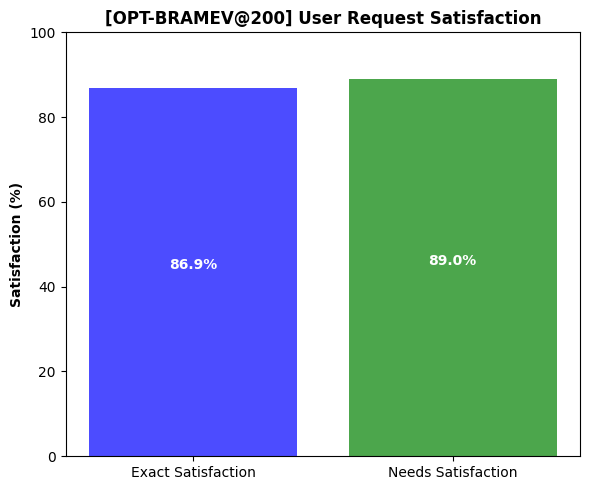

In [199]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

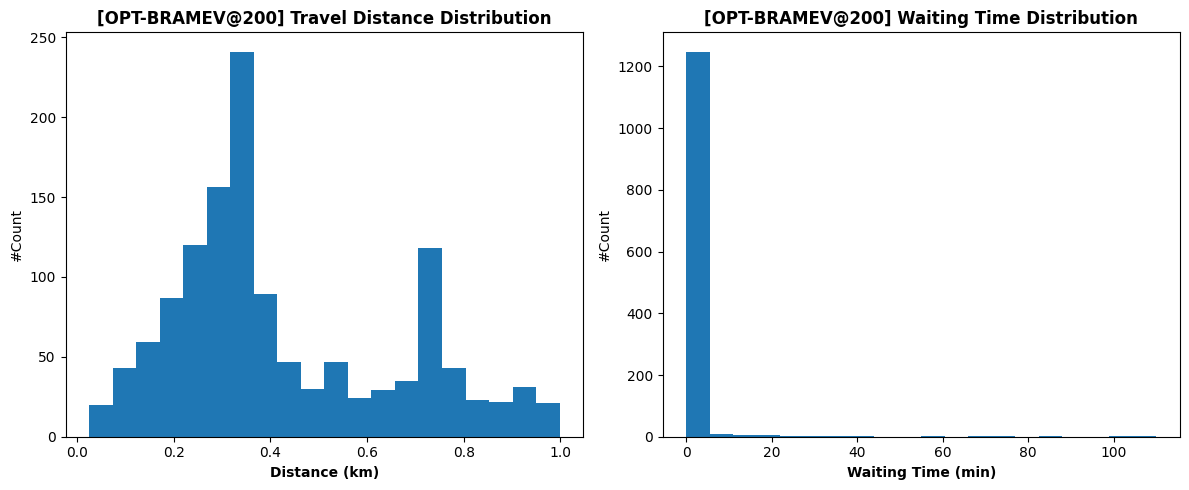

In [200]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

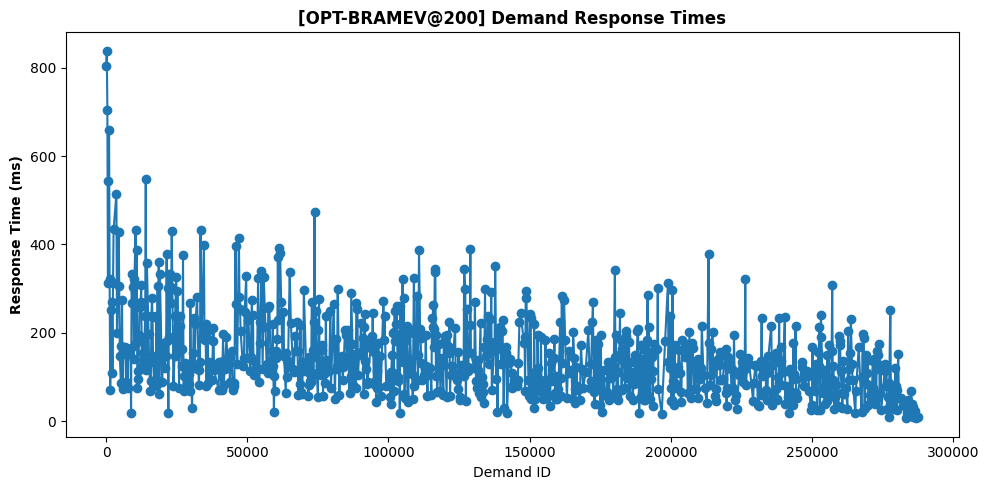

In [201]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

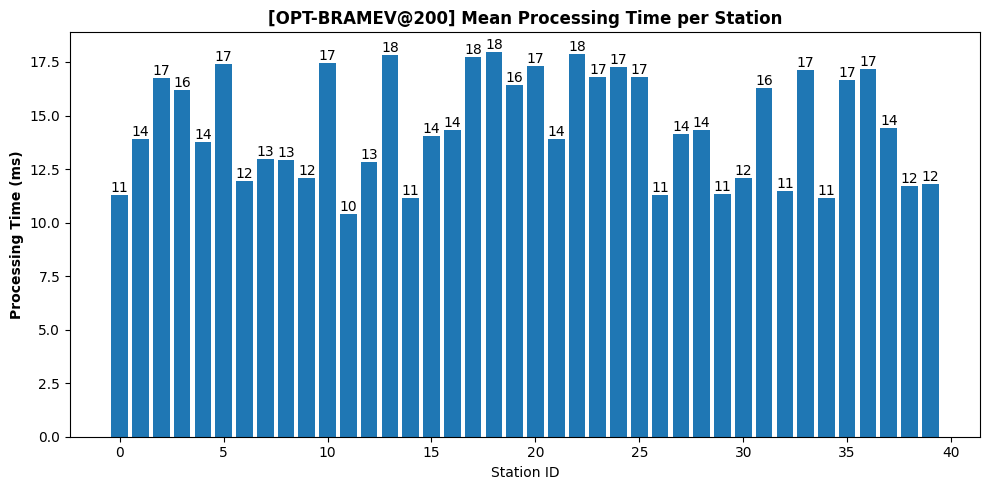

In [202]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

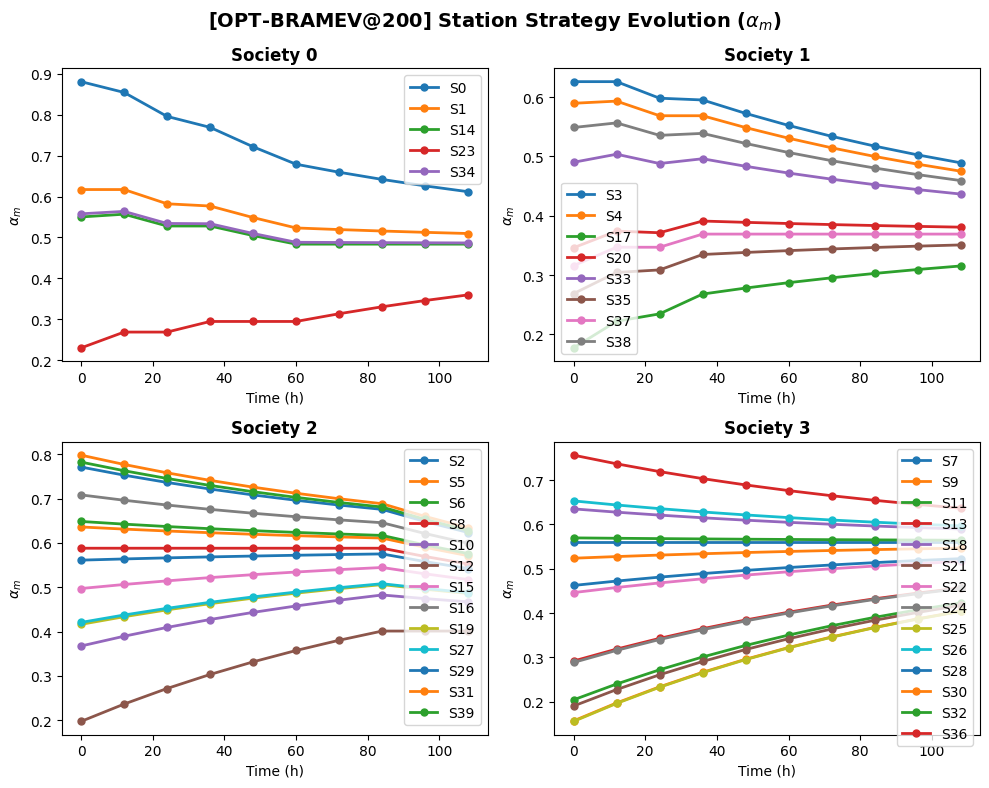

In [203]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [204]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.062500  0.000000  0.000000  0.000000       NaN   
1            0           1  0.135417  0.000000  0.000000  0.000000  0.000000   
2            0          14  0.385417  0.095139  0.035417  0.000000       NaN   
3            0          23  0.279861  0.024306  0.000000  0.000000  0.000000   
4            0          34  0.036806  0.000000  0.000000  0.000000       NaN   
5            1           3  0.415278  0.260417  0.116667  0.008333  0.059722   
6            1           4  0.502083  0.479861  0.118750  0.053472  0.115278   
7            1          17  0.118750  0.037500  0.000000  0.000000  0.000000   
8            1          20  0.172222  0.020833  0.000000  0.000000  0.000000   
9            1          33  0.122917  0.020833  0.000000  0.000000  0.000000   
10           1          35  0.617361  0.350000  0.127083  0.016667  0.000000   
11           1          37  0.661806  0.

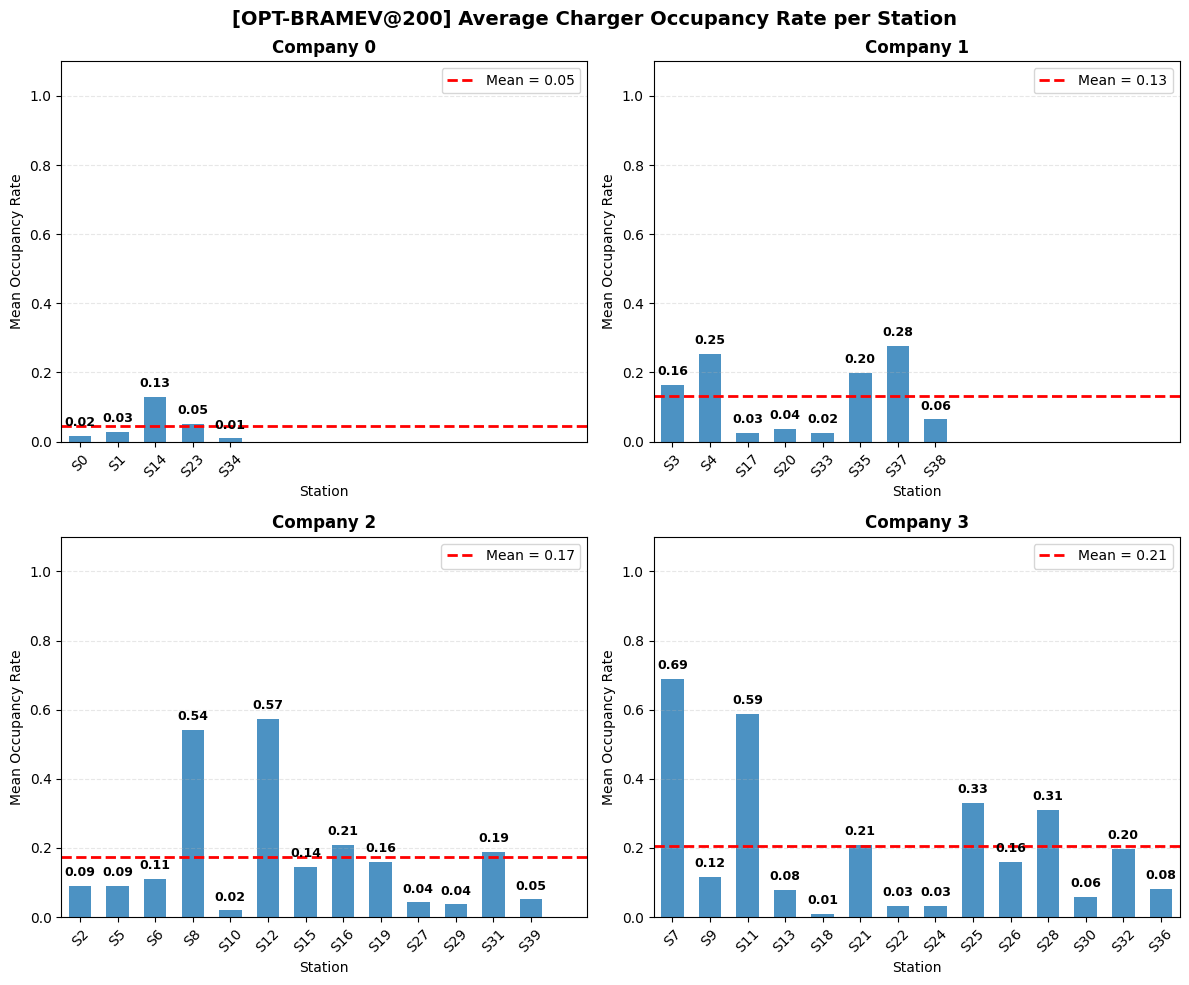

In [205]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

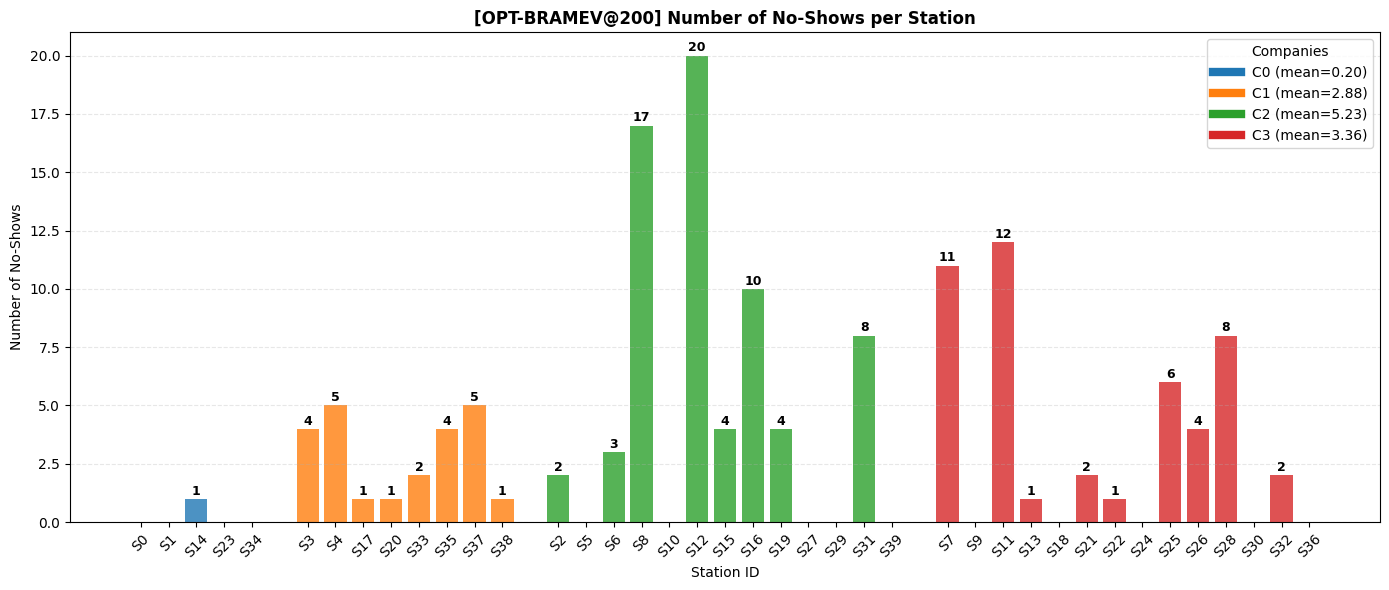

In [206]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [207]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,3,3,0,0,0,1.000000,0.000000,0.0,0.0
1,0,1,6,6,0,0,0,1.000000,0.000000,0.0,0.0
2,0,14,19,18,1,0,0,0.947368,0.052632,0.0,0.0
3,0,23,11,11,0,0,0,1.000000,0.000000,0.0,0.0
4,0,34,1,1,0,0,0,1.000000,0.000000,0.0,0.0
5,1,3,45,41,4,0,0,0.911111,0.088889,0.0,0.0
6,1,4,52,47,5,0,0,0.903846,0.096154,0.0,0.0
7,1,17,7,6,1,0,0,0.857143,0.142857,0.0,0.0
8,1,20,11,10,1,0,0,0.909091,0.090909,0.0,0.0
9,1,33,9,7,2,0,0,0.777778,0.222222,0.0,0.0


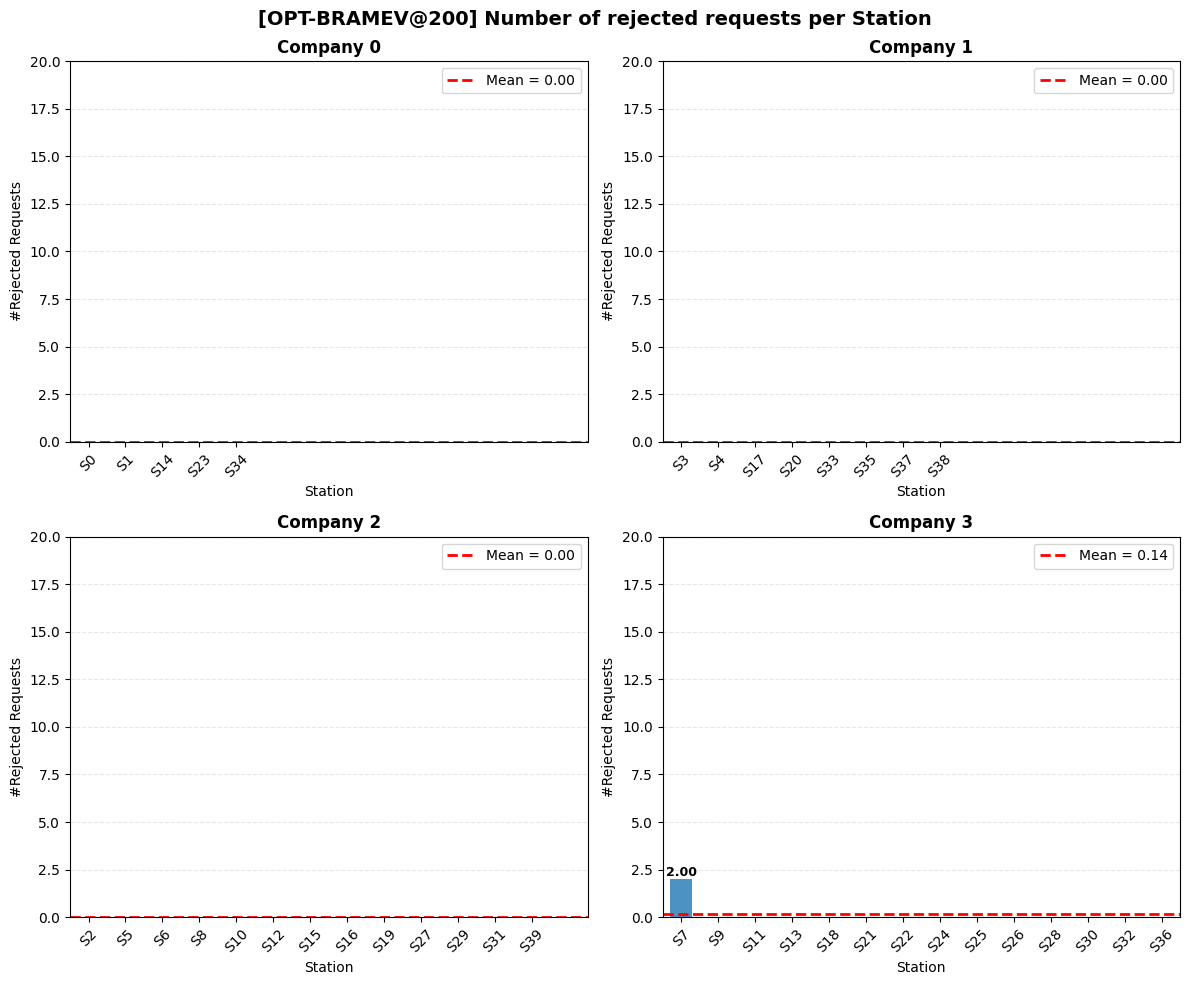

In [208]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [209]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

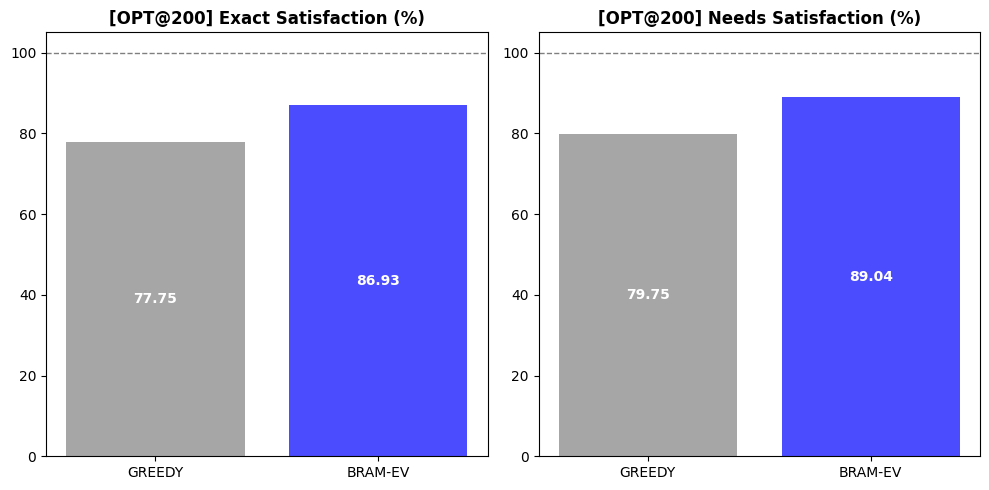

In [210]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

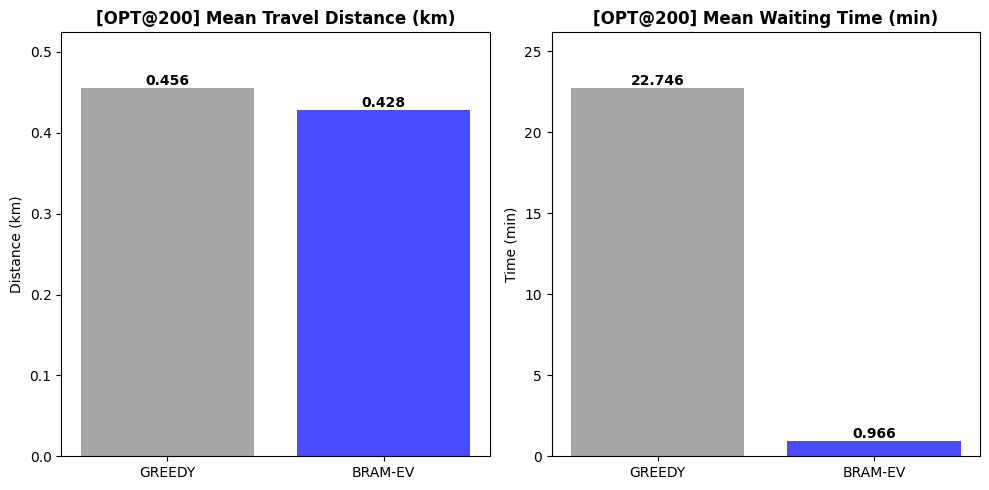

In [211]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

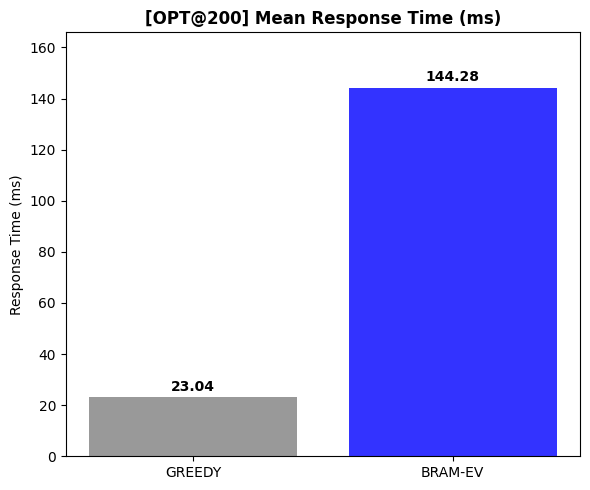

In [212]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [213]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [214]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [215]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [216]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:37:18.050 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-06-17 20:37:18.374 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-06-17 20:37:18.719 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-06-17 20:37:19.048 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-06-17 20:37:19.403 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-06-17 20:37:19.810 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-06-17 20:37:20.361 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-06-17 20:37:20.798 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-06-17 20:37:21.268 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-06-17 20:37:21.643 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-06-17 20:37:22.082 | IN

##### *Metrics*

In [217]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.45 kWh
  Station 1: 6.19 kWh
  Station 2: 55.81 kWh
  Station 3: 65.46 kWh
  Station 4: 11.66 kWh
  Station 5: 98.03 kWh
  Station 6: 36.62 kWh
  Station 7: 97.13 kWh
  Station 8: 326.27 kWh
  Station 9: 76.64 kWh
  Station 10: 14.03 kWh
  Station 11: 9.76 kWh
  Station 12: 290.03 kWh
  Station 13: 282.42 kWh
  Station 14: 13.86 kWh
  Station 15: 11.72 kWh
  Station 16: 310.54 kWh
  Station 17: 108.59 kWh
  Station 18: 25.32 kWh
  Station 19: 37.41 kWh
  Station 20: 7.18 kWh
  Station 21: 6.76 kWh
  Station 22: 34.38 kWh
  Station 23: 3.63 kWh
  Station 24: 77.02 kWh
  Station 25: 10.64 kWh
  Station 26: 149.07 kWh
  Station 27: 74.80 kWh
  Station 28: 21.90 kWh
  Station 29: 15.32 kWh
  Station 30: 12.65 kWh
  Station 31: 8.72 kWh
  Station 32: 63.27 kWh
  Station 33: 7.12 kWh
  Station 34: 73.92 kWh
  Station 35: 5.23 kWh
  Station 36: 18.25 kWh
  Station 37: 111.35 kWh
  Station 38: 10.71 kWh
  Station 39

In [218]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

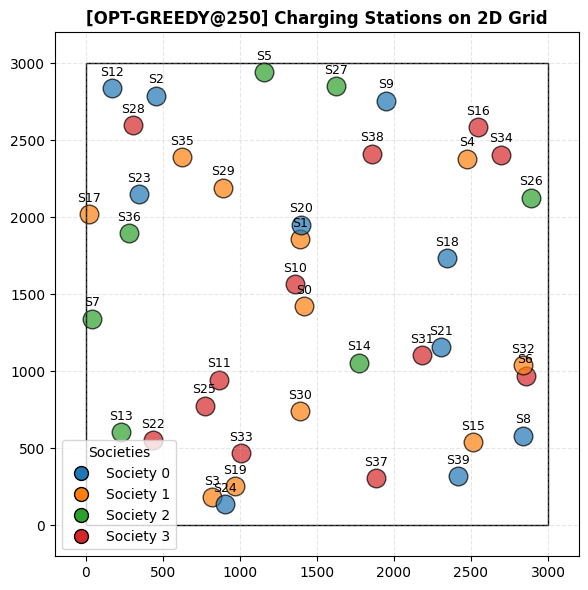

In [219]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

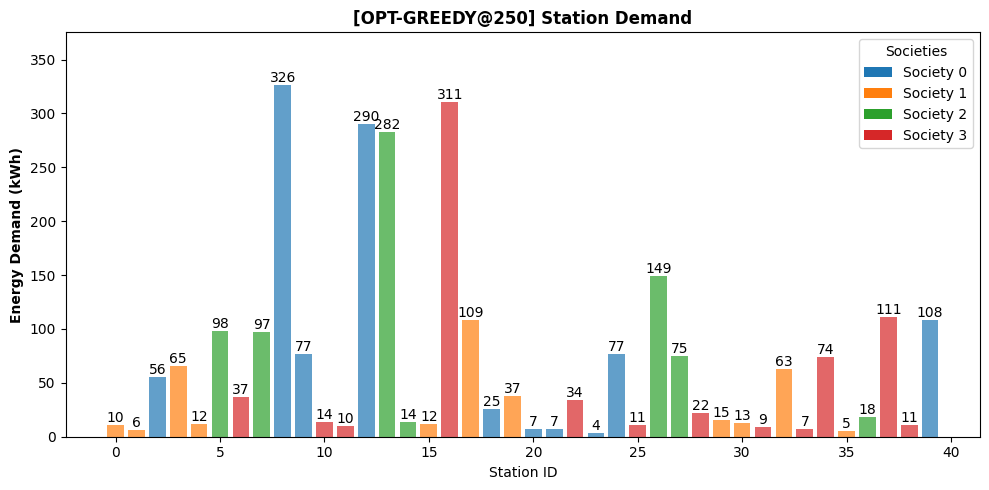

In [220]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

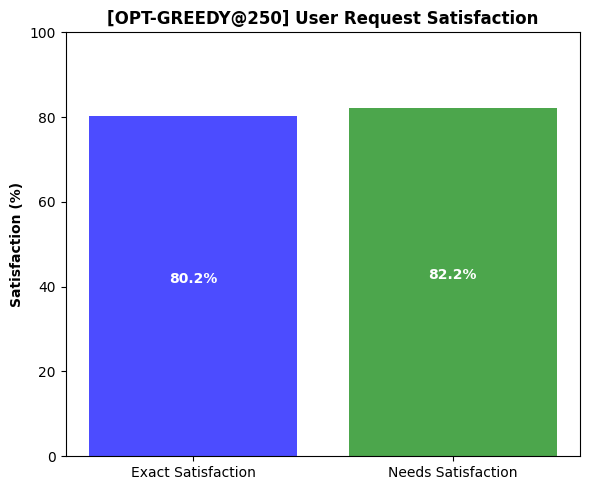

In [221]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

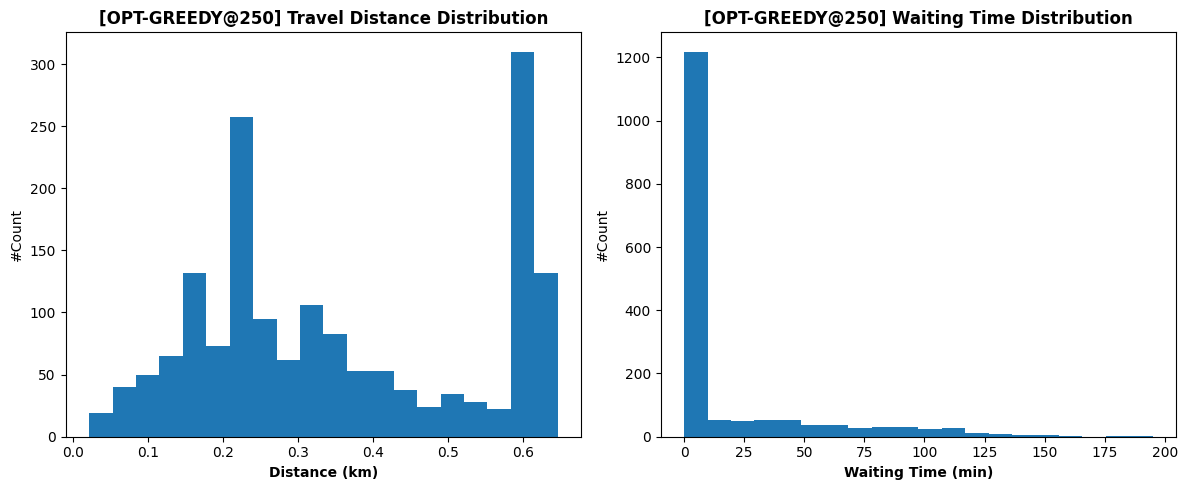

In [222]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

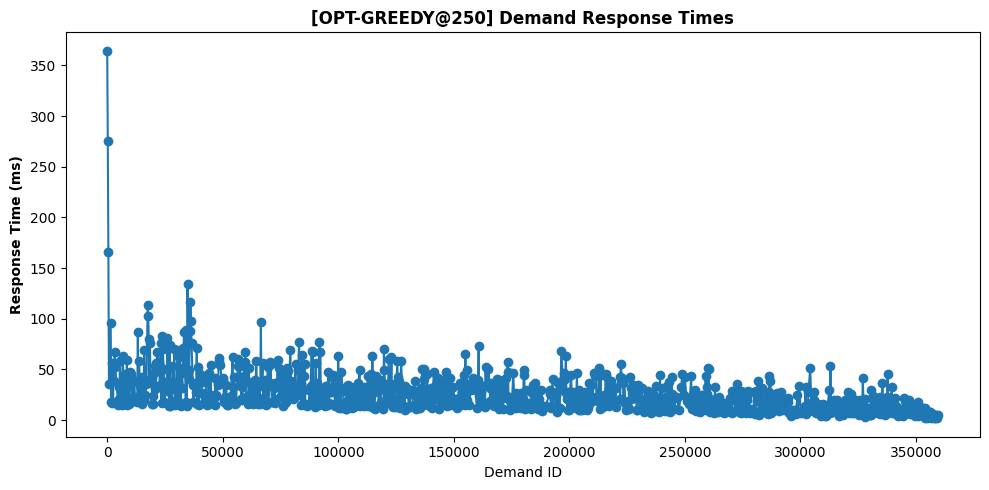

In [223]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

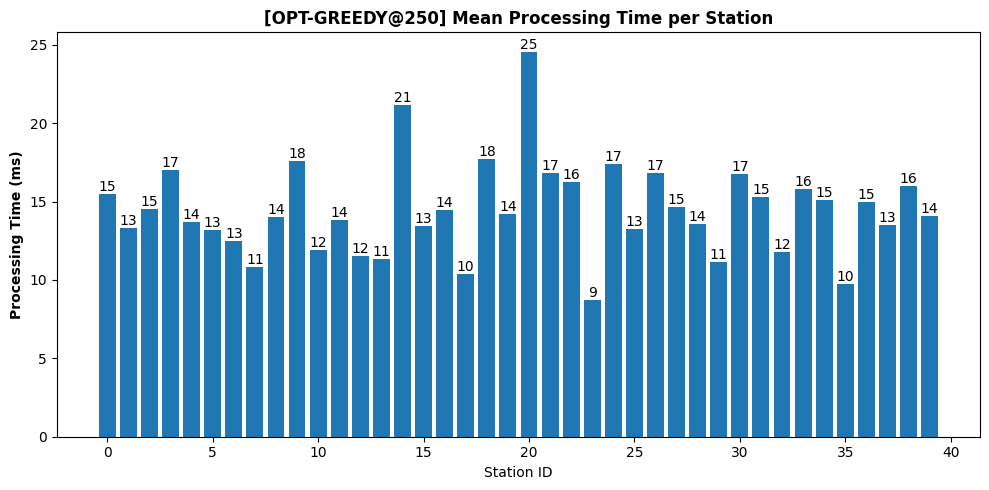

In [224]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [225]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.473611  0.225000  0.000000  0.035417  0.113194   
1            0           8  0.857639  0.881944  0.793056  0.740278  0.599306   
2            0           9  0.572222  0.282639  0.036806  0.024306  0.032639   
3            0          12  0.877778  0.863194  0.761111  0.750000  0.822222   
4            0          18  0.285417  0.105556  0.000000  0.000000  0.000000   
5            0          20  0.047917  0.072917  0.000000  0.000000  0.000000   
6            0          21  0.072222  0.017361  0.000000  0.000000  0.000000   
7            0          23  0.061806  0.000000  0.000000  0.000000       NaN   
8            0          24  0.644444  0.234028  0.020139  0.000000  0.072917   
9            0          39  0.631250  0.452083  0.054167  0.105556  0.229861   
10           1           0  0.135417  0.040278  0.000000  0.000000  0.000000   
11           1           1  0.085417  0.

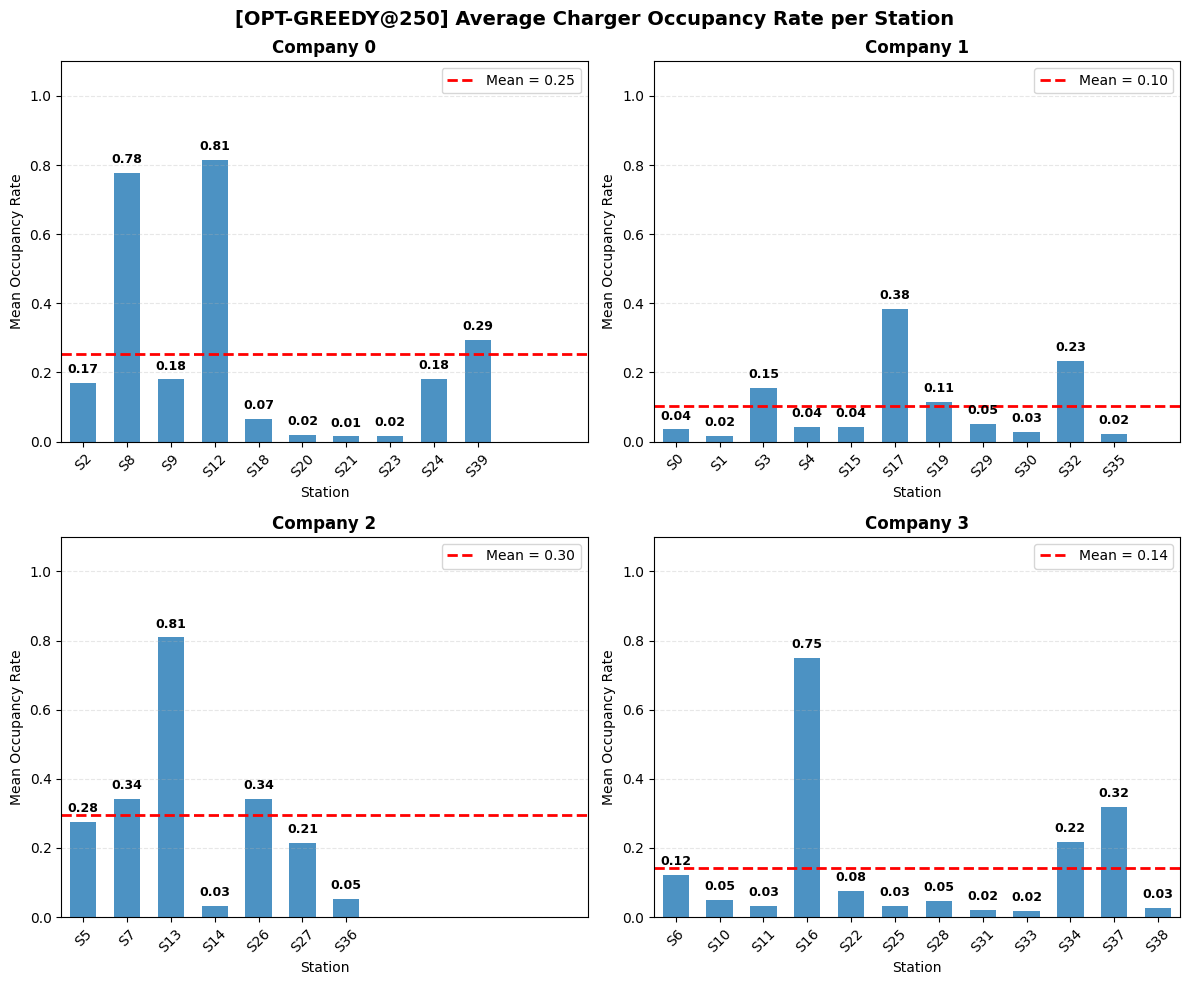

In [226]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

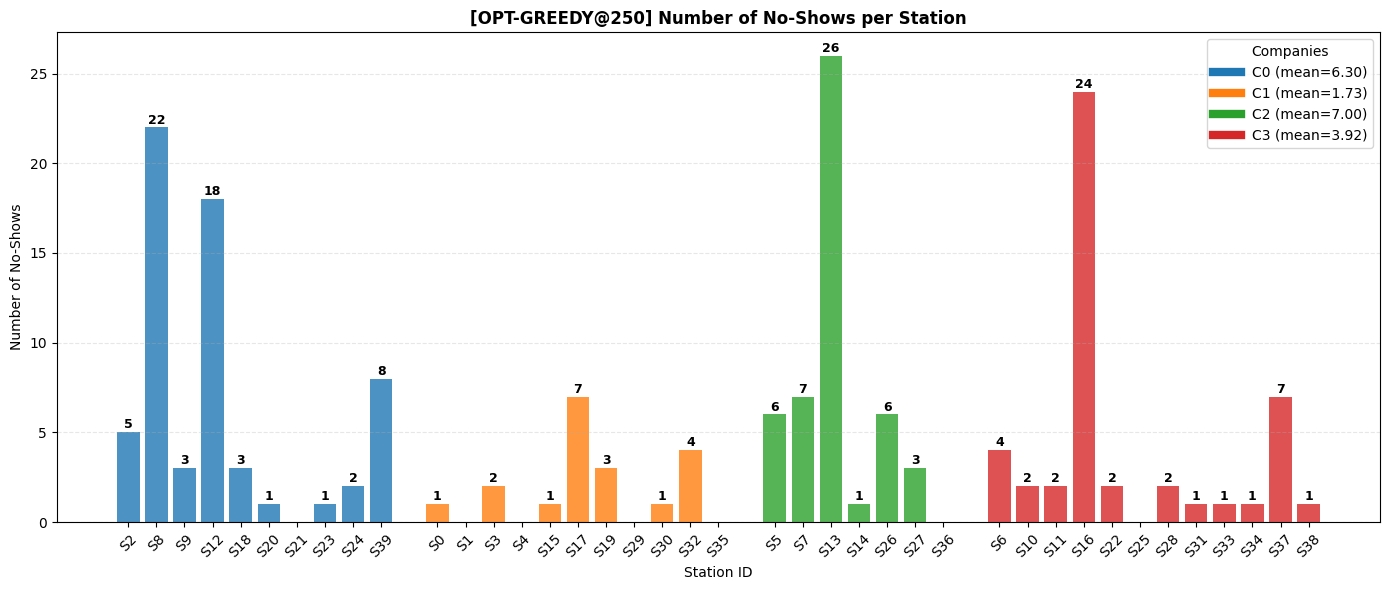

In [227]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [228]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,38,32,5,0,0,0.842105,0.131579,0.000000,0.000000
1,0,8,232,209,22,0,0,0.900862,0.094828,0.000000,0.000000
2,0,9,46,42,3,0,0,0.913043,0.065217,0.000000,0.000000
3,0,12,234,211,18,4,0,0.901709,0.076923,0.017094,0.000000
4,0,18,17,14,3,0,0,0.823529,0.176471,0.000000,0.000000
5,0,20,5,4,1,0,0,0.800000,0.200000,0.000000,0.000000
6,0,21,4,4,0,0,0,1.000000,0.000000,0.000000,0.000000
7,0,23,4,2,1,0,0,0.500000,0.250000,0.000000,0.000000
8,0,24,47,45,2,0,0,0.957447,0.042553,0.000000,0.000000
9,0,39,70,62,8,0,0,0.885714,0.114286,0.000000,0.000000


NUMBER OF REJECTED REQUESTS

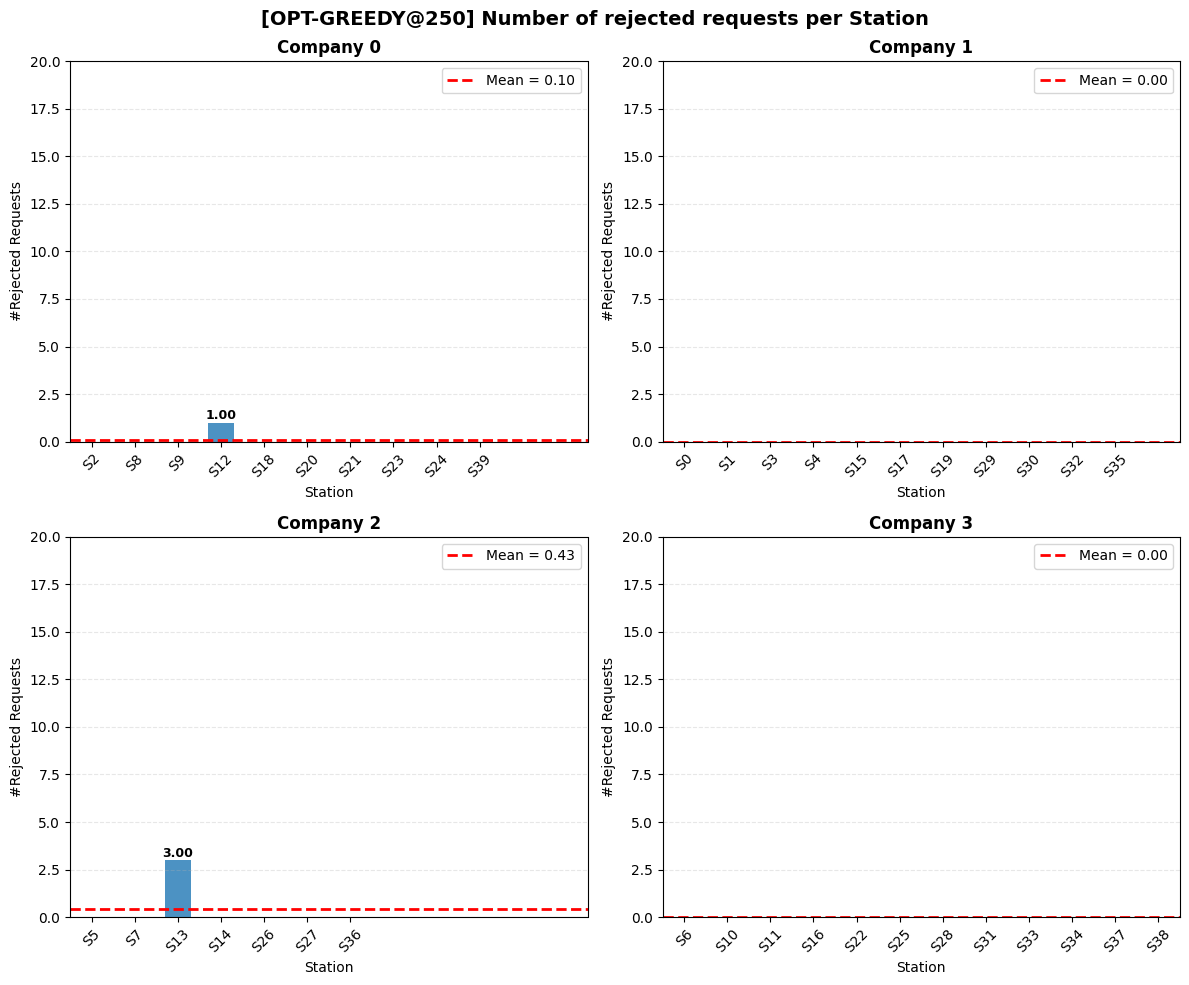

In [229]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [230]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [231]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [232]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-17 20:37:56.603 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-17 20:37:59.998 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-17 20:38:01.304 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-17 20:38:02.988 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-17 20:38:04.317 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-17 20:38:06.999 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-17 20:38:09.219 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-17 20:38:10.707 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-17 20:38:12.803 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-17 20:38:14.072 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-17 20:38:15.885 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [233]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 25.74 kWh
  Station 1: 41.27 kWh
  Station 2: 47.73 kWh
  Station 3: 0.00 kWh
  Station 4: 45.17 kWh
  Station 5: 215.42 kWh
  Station 6: 26.23 kWh
  Station 7: 66.81 kWh
  Station 8: 70.56 kWh
  Station 9: 190.20 kWh
  Station 10: 13.41 kWh
  Station 11: 67.03 kWh
  Station 12: 120.08 kWh
  Station 13: 13.78 kWh
  Station 14: 103.26 kWh
  Station 15: 192.24 kWh
  Station 16: 91.88 kWh
  Station 17: 68.08 kWh
  Station 18: 46.45 kWh
  Station 19: 174.21 kWh
  Station 20: 34.62 kWh
  Station 21: 18.75 kWh
  Station 22: 209.50 kWh
  Station 23: 12.86 kWh
  Station 24: 14.22 kWh
  Station 25: 49.61 kWh
  Station 26: 7.39 kWh
  Station 27: 13.18 kWh
  Station 28: 16.48 kWh
  Station 29: 81.33 kWh
  Station 30: 184.62 kWh
  Station 31: 177.12 kWh
  Station 32: 28.51 kWh
  Station 33: 73.98 kWh
  Station 34: 17.84 kWh
  Station 35: 7.58 kWh
  Station 36: 58.56 kWh
  Station 37: 81.37 kWh
  Station 38: 20.67 kWh
  Sta

In [234]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

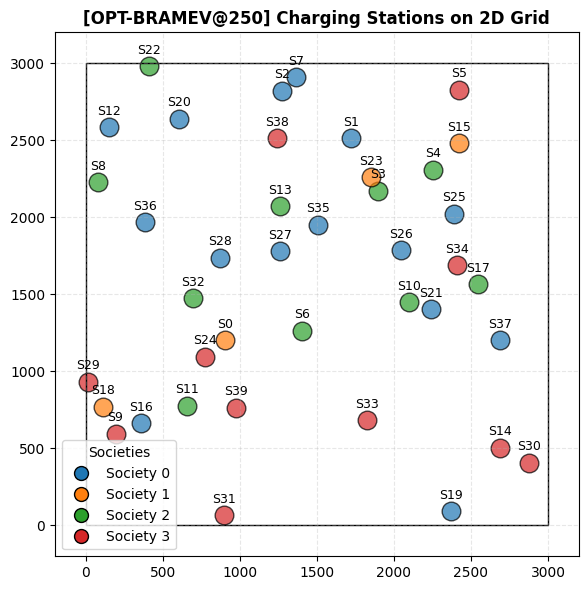

In [235]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

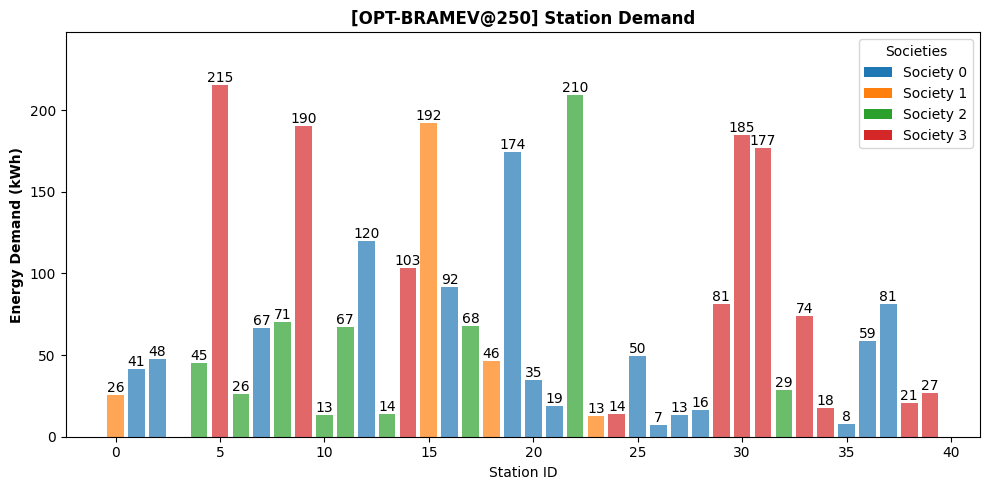

In [236]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

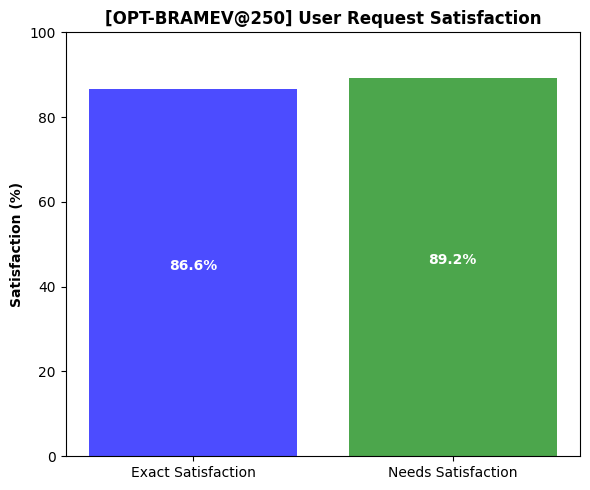

In [237]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

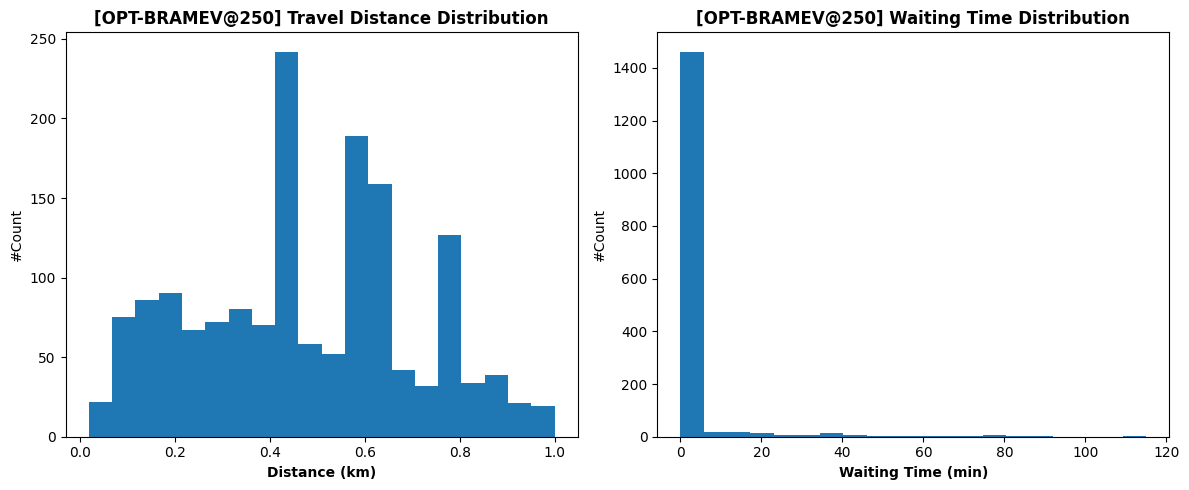

In [238]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

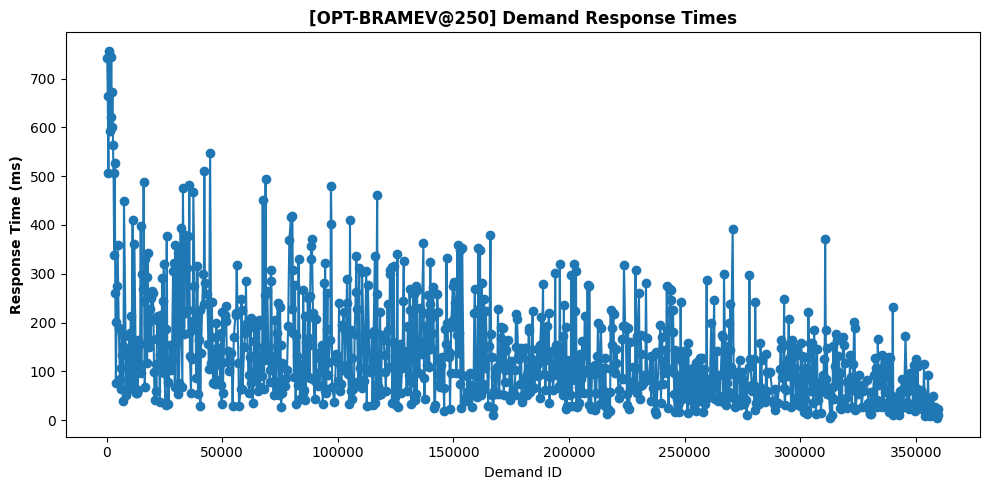

In [239]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

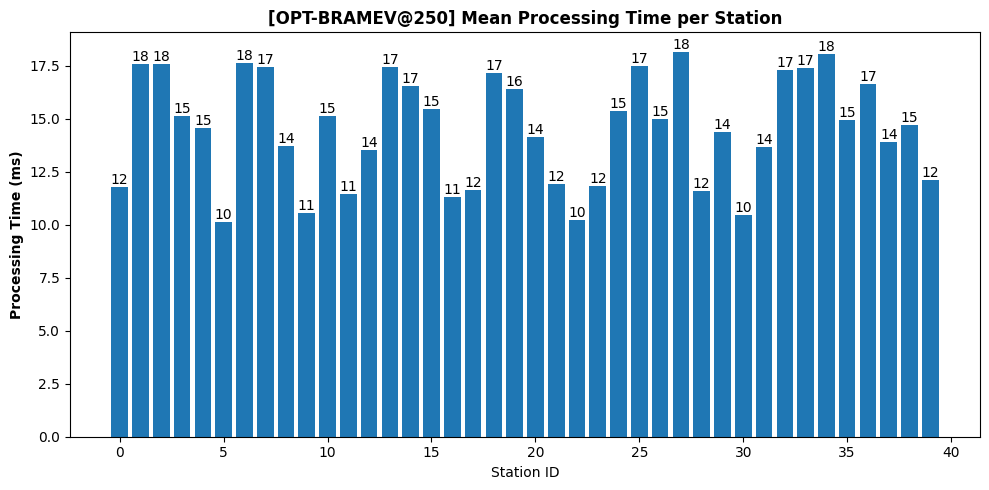

In [240]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

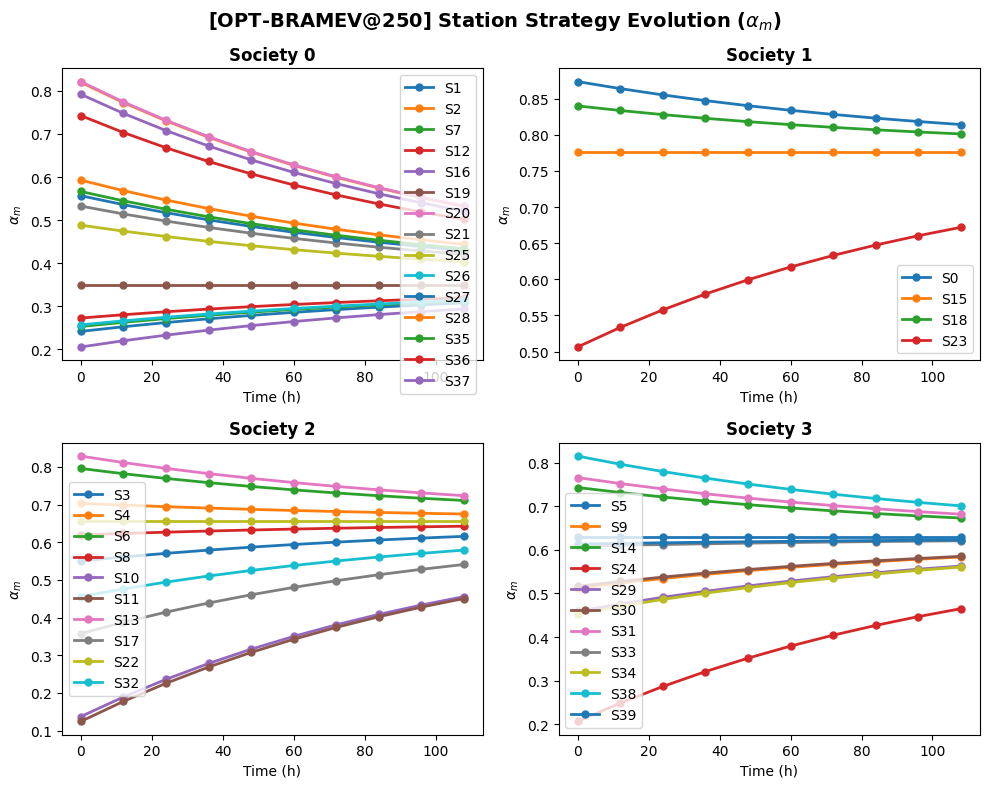

In [241]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [242]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.373611  0.177778  0.020139  0.000000  0.000000   
1            0           2  0.482639  0.200694  0.000000  0.000000  0.000000   
2            0           7  0.563889  0.260417  0.088194  0.018750  0.019444   
3            0          12  0.562500  0.471528  0.201389  0.200000  0.297222   
4            0          16  0.585417  0.395833  0.156944  0.137500       NaN   
5            0          19  0.674306  0.618056  0.331250  0.245833  0.227083   
6            0          20  0.256250  0.129167  0.059722  0.027778  0.000000   
7            0          21  0.179861  0.093750  0.020139  0.000000       NaN   
8            0          25  0.399306  0.172917  0.069444  0.000000  0.065972   
9            0          26  0.068750  0.029861  0.000000  0.000000  0.000000   
10           0          27  0.161806  0.019444  0.000000  0.000000  0.000000   
11           0          28  0.197917  0.

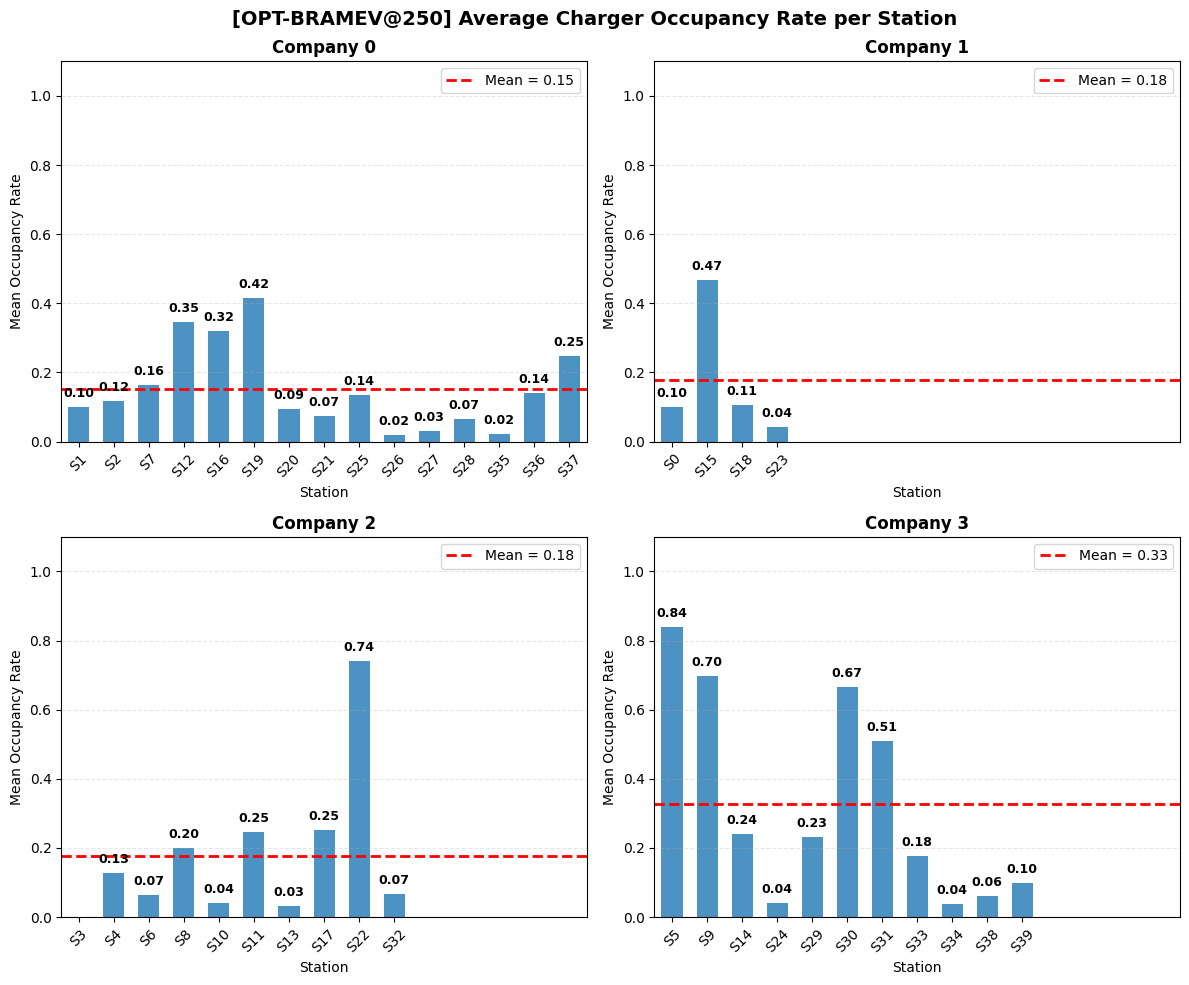

In [243]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

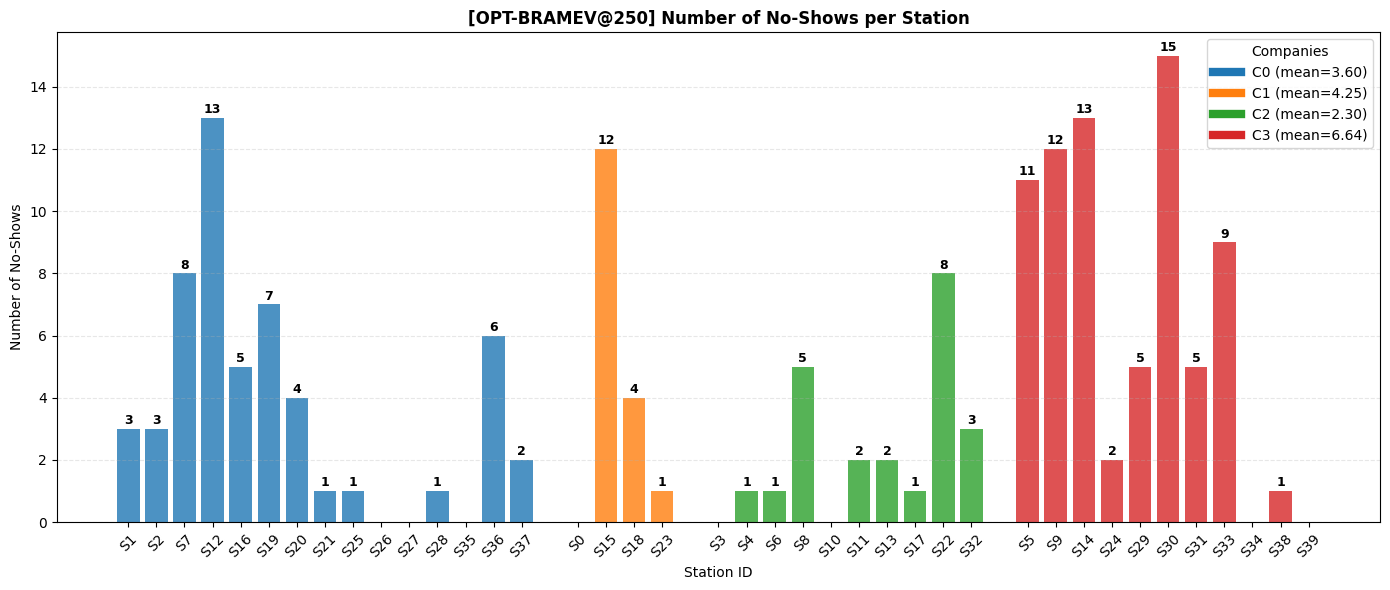

In [244]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [245]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,25,22,3,0,0,0.880000,0.120000,0.0,0.0
1,0,2,31,28,3,0,0,0.903226,0.096774,0.0,0.0
2,0,7,47,39,8,0,0,0.829787,0.170213,0.0,0.0
3,0,12,84,71,13,0,0,0.845238,0.154762,0.0,0.0
4,0,16,58,53,5,0,0,0.913793,0.086207,0.0,0.0
5,0,19,106,99,7,0,0,0.933962,0.066038,0.0,0.0
6,0,20,24,20,4,0,0,0.833333,0.166667,0.0,0.0
7,0,21,11,10,1,0,0,0.909091,0.090909,0.0,0.0
8,0,25,32,29,1,0,0,0.906250,0.031250,0.0,0.0
9,0,26,4,4,0,0,0,1.000000,0.000000,0.0,0.0


NUMBER OF REJECTED REQUESTS

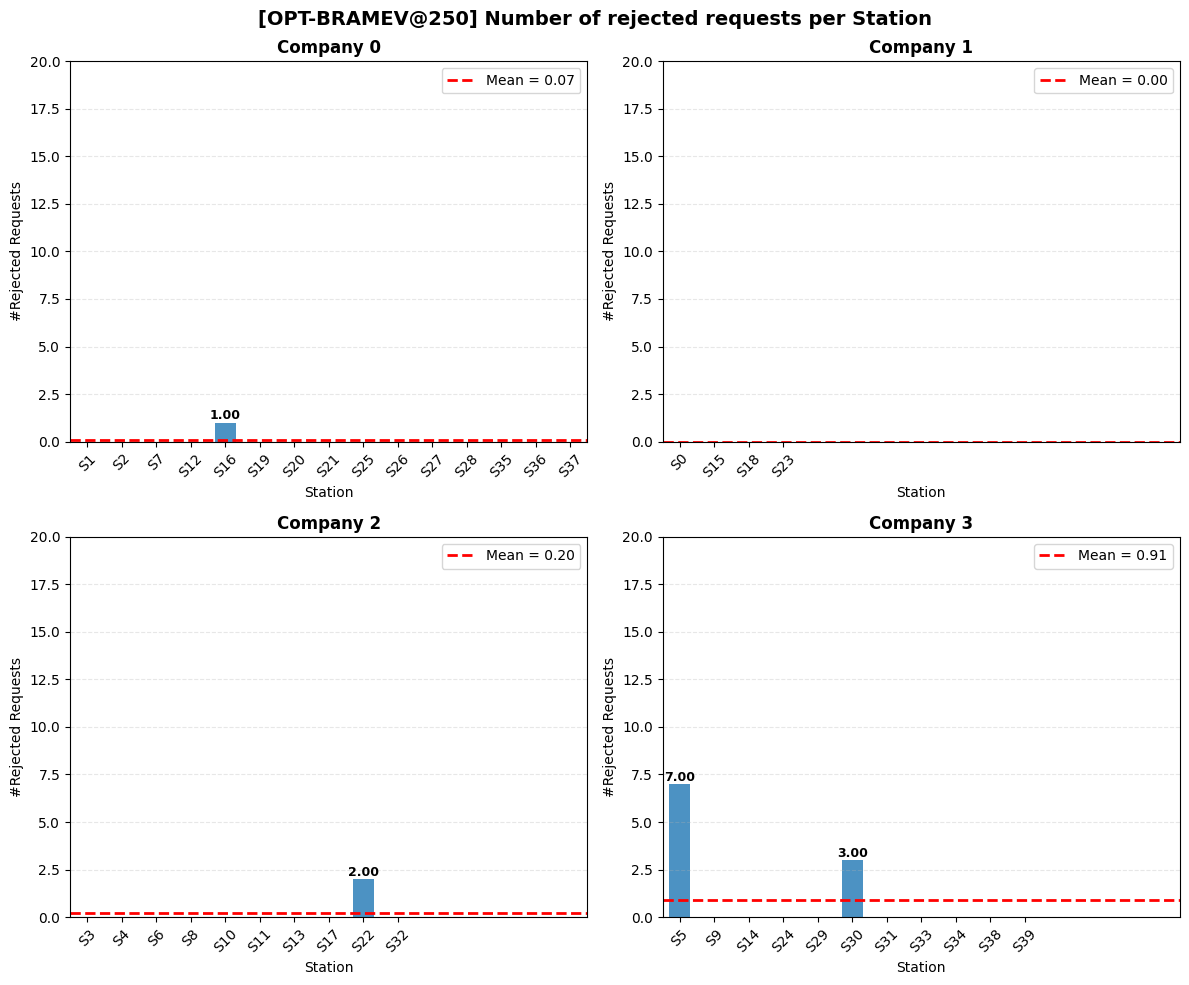

In [246]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [247]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

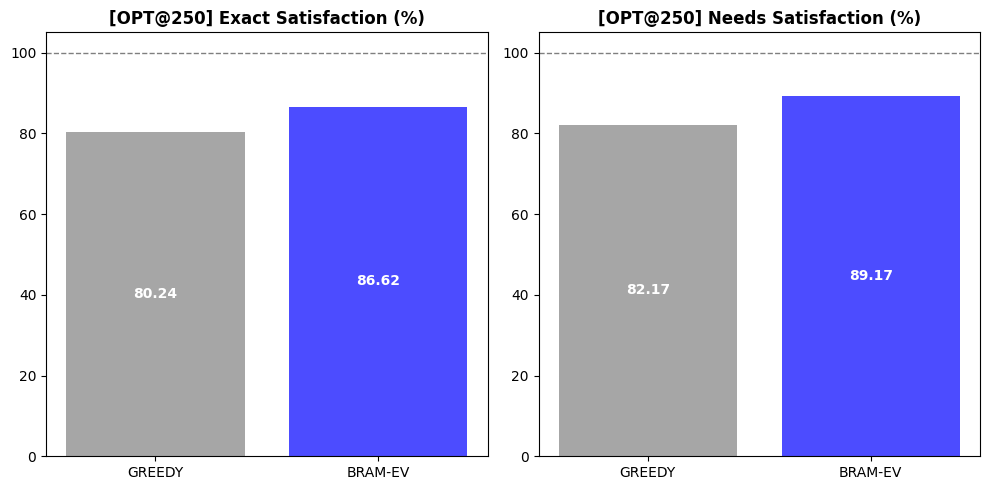

In [248]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

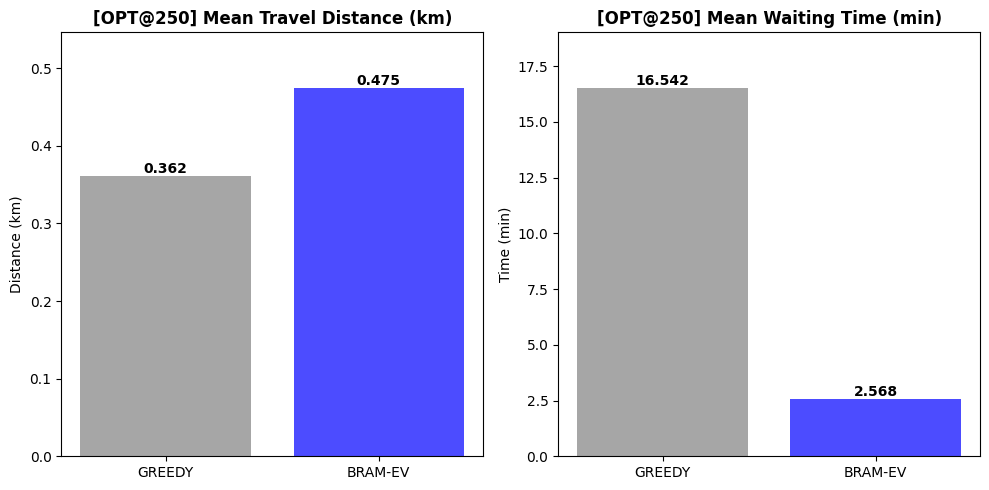

In [249]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

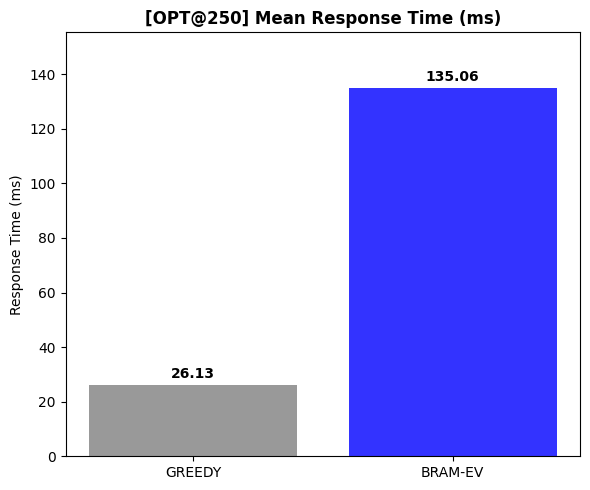

In [250]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

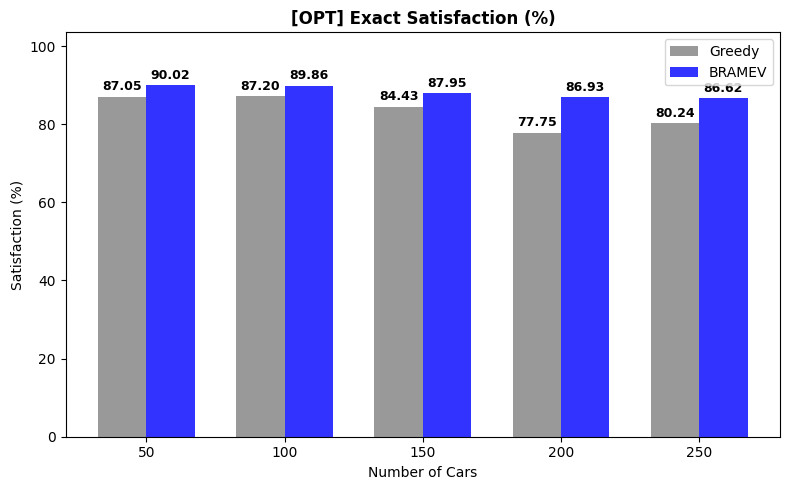

In [251]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

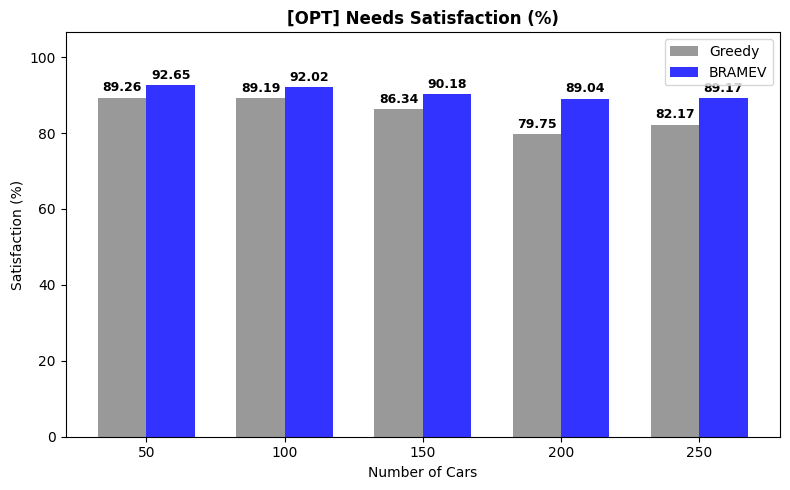

In [252]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

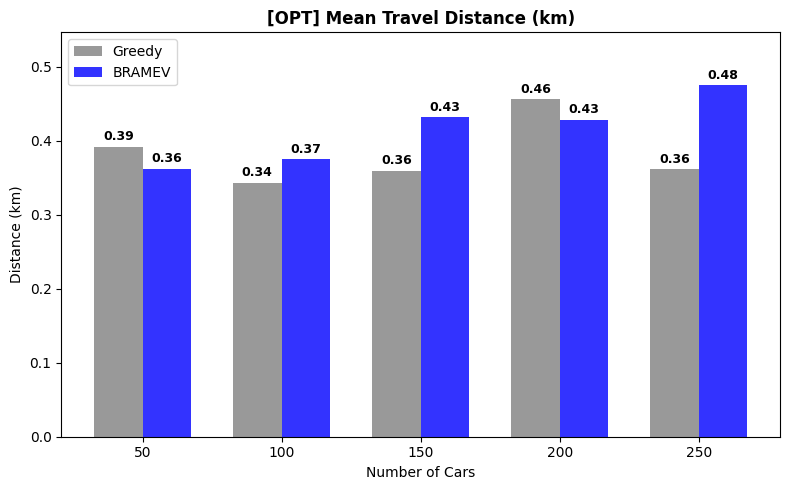

In [253]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


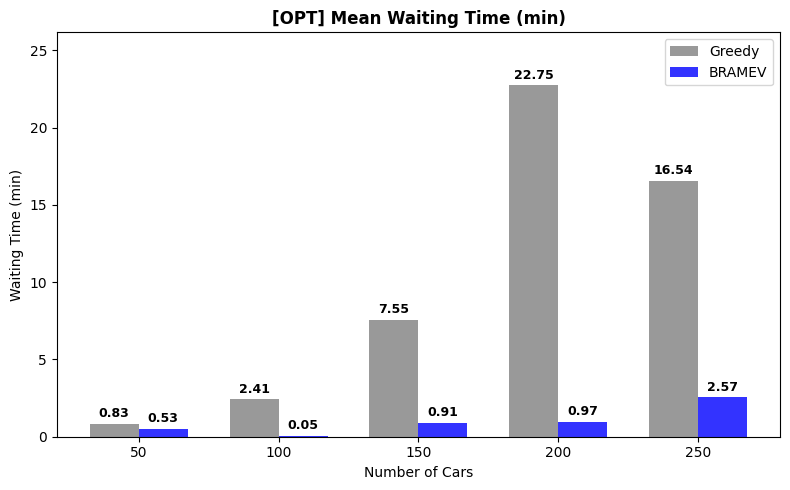

In [254]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


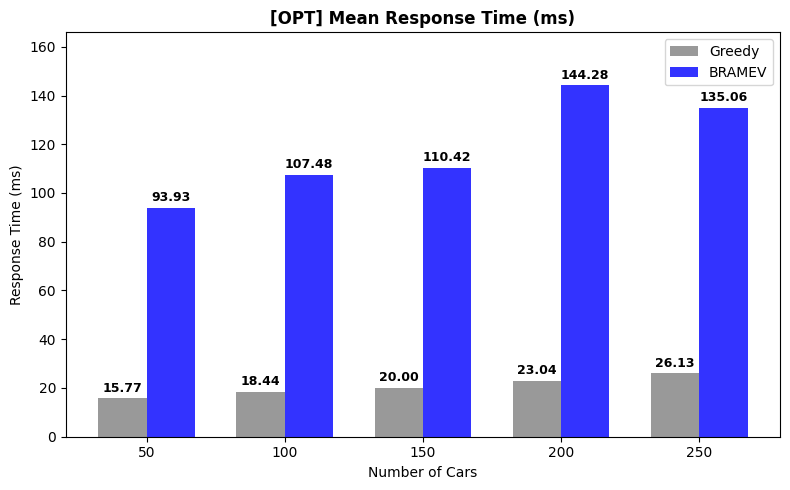

: 

In [ ]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
